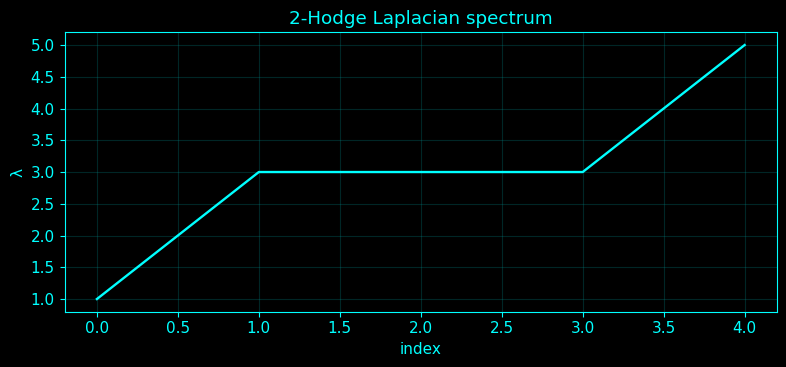

In [167]:
# Method 155: 2-Hodge Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_155():

    i = 155
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    L = {153: L0, 154: L1, 155: L2}[i]
    ev = np.linalg.eigvalsh((L + L.T) / 2) if L.size else np.array([])
    _plot_line(np.arange(len(ev)), ev, f'{i - 153}-Hodge Laplacian spectrum', 'index', 'λ')
    return


_topology_method_155()
del _topology_method_155


### 156. Persistent Hodge Laplacian

For nested complexes \(K_t\subset K_s\), the persistent 1-Hodge Laplacian uses only 2-chains in \(K_s\) whose boundaries lie in \(C_1(K_t)\): \(\Delta_1^{t,s}=B_1(t)^TB_1(t)+B_{2}^{t,s}(B_{2}^{t,s})^T\). The helper explicitly computes that constrained 2-chain subspace via a nullspace, rather than merely plotting ordinary Hodge Laplacians at two thresholds.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted. Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


thresholds 0.8615921774315365 0.8086896537672222 persistent harmonic dim 0


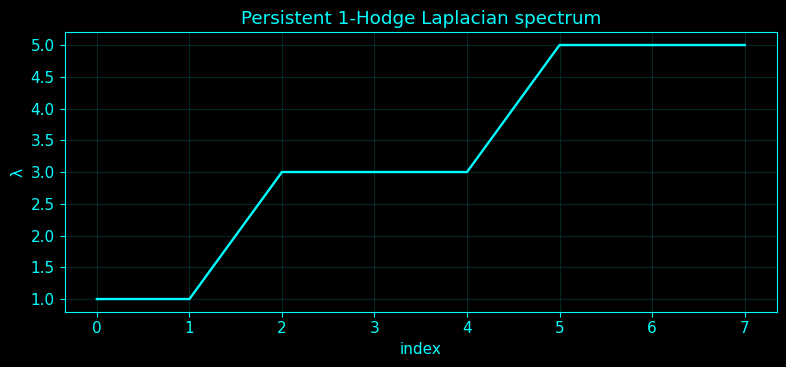

In [168]:
# Method 156: Persistent Hodge Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_156():

    i = 156
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _null_basis_real(A,tol=1e-9):
        A=np.asarray(A,float)
        if A.size==0:return np.zeros((A.shape[1] if A.ndim==2 else 0,0))
        w,V=np.linalg.eigh((A+A.T)/2); t=tol*max(1.,float(np.max(np.abs(w))) if len(w) else 1.); return V[:,np.abs(w)<=t]

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _persistent_hodge_1(S,q0=.72,q1=.55):
        # Exact two-scale persistent q=1 Laplacian Δ_1^{t,s} on C1(K_t).
        small,_,t0=_flag_simplices_similarity(S,q0,3); large,_,t1=_flag_simplices_similarity(S,q1,3)
        B1s,B2s,_=_complex_boundaries(small); _,B2L,_=_complex_boundaries(large)
        eS={e:i for i,e in enumerate(small[1])}; eL={e:i for i,e in enumerate(large[1])}
        in_rows=[eL[e] for e in small[1]]; out_rows=[j for e,j in eL.items() if e not in eS]
        if B2L.shape[1]:
            Z=null_space(B2L[out_rows,:]) if out_rows else np.eye(B2L.shape[1]); P=B2L[in_rows,:]@Z
        else:P=np.zeros((len(small[1]),0))
        Lp=B1s.T@B1s + P@P.T
        return Lp,small,large,t0,t1

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    Lp, sp0, sp1, t0, t1 = _persistent_hodge_1(S, 0.72, 0.55)
    ev = np.linalg.eigvalsh((Lp + Lp.T) / 2) if Lp.size else np.array([])
    print('thresholds', t0, t1, 'persistent harmonic dim', _null_basis_real(Lp).shape[1])
    _plot_line(np.arange(len(ev)), ev, 'Persistent 1-Hodge Laplacian spectrum', 'index', 'λ')
    return


_topology_method_156()
del _topology_method_156


### 157. Hodge Laplacian spectral gaps

Hodge spectral-gap analysis tracks the dimension of the harmonic subspace and the smallest positive eigenvalue of \(L_1\) across filtration thresholds. The zero multiplicity gives \(\beta_1\); the positive gap describes separation from non-harmonic edge modes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,threshold,harmonic_dim,smallest_positive_Hodge_eigenvalue
0,0.861592,0,1.000000
1,0.838982,0,1.585786
2,0.827177,0,3.000000


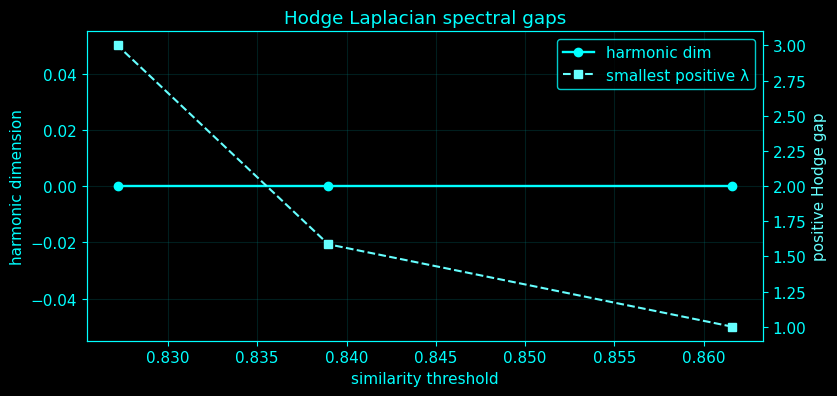

In [169]:
# Method 157: Hodge Laplacian spectral gaps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_157():

    i = 157
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    rows = []
    for q in [0.72, 0.64, 0.56]:
        sp, _, t = _flag_simplices_similarity(S, q, 3)
        b1, b2, b3 = _complex_boundaries(sp)
        _, l1, _ = _hodge_laplacians(b1, b2, b3)
        ev = np.linalg.eigvalsh((l1 + l1.T) / 2) if l1.size else np.array([])
        pos = ev[ev > 1e-09]
        rows.append([t, len(ev) - len(pos), float(pos[0]) if len(pos) else np.nan])
    out = pd.DataFrame(rows, columns=['threshold', 'harmonic_dim', 'smallest_positive_Hodge_eigenvalue'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.1), facecolor=TOPO_BG)
    ax2 = ax.twinx()
    ax.plot(out['threshold'], out['harmonic_dim'], color=TOPO_ACCENT, marker='o', linewidth=1.7, label='harmonic dim')
    ax2.plot(out['threshold'], out['smallest_positive_Hodge_eigenvalue'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.5, label='smallest positive λ')
    ax.set_title('Hodge Laplacian spectral gaps')
    ax.set_xlabel('similarity threshold')
    ax.set_ylabel('harmonic dimension')
    ax2.set_ylabel('positive Hodge gap', color=TOPO_CYAN_SOFT)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc='best')
    plt.tight_layout()
    plt.show()
    return


_topology_method_157()
del _topology_method_157


### 158. Harmonic 1-forms

Harmonic 1-forms are vectors \(h\in C^1\) satisfying \(L_1h=0\), equivalently zero divergence and zero curl in this finite complex. They represent real H1 cohomology classes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [170]:
# Method 158: Harmonic 1-forms

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_158():

    i = 158
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _null_basis_real(A,tol=1e-9):
        A=np.asarray(A,float)
        if A.size==0:return np.zeros((A.shape[1] if A.ndim==2 else 0,0))
        w,V=np.linalg.eigh((A+A.T)/2); t=tol*max(1.,float(np.max(np.abs(w))) if len(w) else 1.); return V[:,np.abs(w)<=t]

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    H = _null_basis_real(L1)
    print('harmonic/cycle-space dimension =', H.shape[1])
    if H.shape[1]:
        out = pd.DataFrame(H[:, :min(3, H.shape[1])], index=[str(e) for e in simp[1]], columns=[f'h{k}' for k in range(min(3, H.shape[1]))])
        display(out)
        fig, ax = plt.subplots(figsize=(7.5, max(4, min(10, 0.24 * len(out)))), facecolor=TOPO_BG)
        vmax = max(TOPO_EPS, float(np.max(np.abs(out.to_numpy(float)))))
        im = ax.imshow(out.to_numpy(float), cmap=TOPO_CMAP, aspect='auto', vmin=-vmax, vmax=vmax)
        ax.set_title({158: 'Harmonic 1-forms', 159: 'Harmonic cycle basis', 166: 'Cycle-space harmonic basis'}[i])
        ax.set_xlabel('harmonic basis vector')
        ax.set_ylabel('edge')
        ax.set_xticks(range(len(out.columns)))
        ax.set_xticklabels(out.columns)
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    return


_topology_method_158()
del _topology_method_158


harmonic/cycle-space dimension = 0


### 159. Harmonic cycle basis

A harmonic cycle basis is an orthonormal basis of \(\ker L_1\). Unlike an arbitrary binary cycle basis, harmonic representatives are selected by the inner product and distribute weight across homologous edges.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [171]:
# Method 159: Harmonic cycle basis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_159():

    i = 159
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _null_basis_real(A,tol=1e-9):
        A=np.asarray(A,float)
        if A.size==0:return np.zeros((A.shape[1] if A.ndim==2 else 0,0))
        w,V=np.linalg.eigh((A+A.T)/2); t=tol*max(1.,float(np.max(np.abs(w))) if len(w) else 1.); return V[:,np.abs(w)<=t]

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    H = _null_basis_real(L1)
    print('harmonic/cycle-space dimension =', H.shape[1])
    if H.shape[1]:
        out = pd.DataFrame(H[:, :min(3, H.shape[1])], index=[str(e) for e in simp[1]], columns=[f'h{k}' for k in range(min(3, H.shape[1]))])
        display(out)
        fig, ax = plt.subplots(figsize=(7.5, max(4, min(10, 0.24 * len(out)))), facecolor=TOPO_BG)
        vmax = max(TOPO_EPS, float(np.max(np.abs(out.to_numpy(float)))))
        im = ax.imshow(out.to_numpy(float), cmap=TOPO_CMAP, aspect='auto', vmin=-vmax, vmax=vmax)
        ax.set_title({158: 'Harmonic 1-forms', 159: 'Harmonic cycle basis', 166: 'Cycle-space harmonic basis'}[i])
        ax.set_xlabel('harmonic basis vector')
        ax.set_ylabel('edge')
        ax.set_xticks(range(len(out.columns)))
        ax.set_xticklabels(out.columns)
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    return


_topology_method_159()
del _topology_method_159


harmonic/cycle-space dimension = 0


### 160. Hodge decomposition of edge flows

Discrete Hodge decomposition writes an edge flow \(x\) orthogonally as \(x=B_1^T\phi+B_2\psi+h\): gradient, curl, and harmonic components. Their squared norms partition flow energy up to numerical precision.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,component,energy,fraction
0,gradient,2.065892e+01,4.952505e-01
1,curl,2.105516e+01,5.047495e-01
2,harmonic,1.414095e-29,3.389971e-31


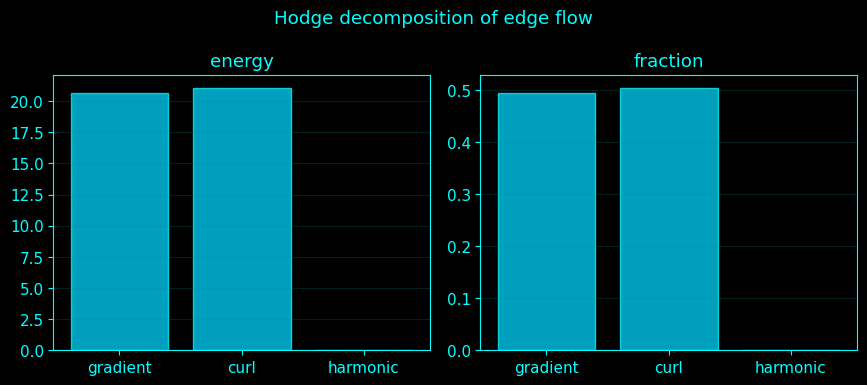

In [172]:
# Method 160: Hodge decomposition of edge flows

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_160():

    i = 160
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_decompose(flow,B1,B2,L1):
        x=np.asarray(flow,float); grad=B1.T@np.linalg.lstsq(B1@B1.T,B1@x,rcond=None)[0] if B1.size else np.zeros_like(x)
        rem=x-grad; curl=B2@np.linalg.lstsq(B2.T@B2,B2.T@rem,rcond=None)[0] if B2.size and B2.shape[1] else np.zeros_like(x); harm=rem-curl
        return grad,curl,harm

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    g, c, h = _hodge_decompose(flow, B1, B2, L1)
    E = np.array([g @ g, c @ c, h @ h])
    out = pd.DataFrame({'component': ['gradient', 'curl', 'harmonic'], 'energy': E, 'fraction': E / (E.sum() + TOPO_EPS)})
    display(out)
    fig, axs = plt.subplots(1, 2, figsize=(8.8, 3.9), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['energy', 'fraction']):
        ax.bar(out['component'], out[col], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Hodge decomposition of edge flow' if i == 160 else 'Gradient–curl–harmonic decomposition')
    plt.tight_layout()
    plt.show()
    return


_topology_method_160()
del _topology_method_160


### 161. Gradient-curl-harmonic decomposition

The gradient–curl–harmonic cell reports the same Hodge decomposition explicitly as energy fractions, making the Helmholtz-like structure of the edge flow visible.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,component,energy,fraction
0,gradient,2.065892e+01,4.952505e-01
1,curl,2.105516e+01,5.047495e-01
2,harmonic,1.414095e-29,3.389971e-31


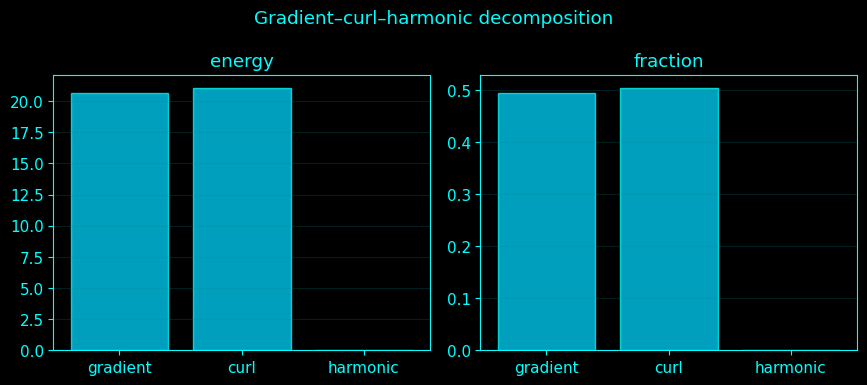

In [173]:
# Method 161: Gradient-curl-harmonic decomposition

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_161():

    i = 161
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_decompose(flow,B1,B2,L1):
        x=np.asarray(flow,float); grad=B1.T@np.linalg.lstsq(B1@B1.T,B1@x,rcond=None)[0] if B1.size else np.zeros_like(x)
        rem=x-grad; curl=B2@np.linalg.lstsq(B2.T@B2,B2.T@rem,rcond=None)[0] if B2.size and B2.shape[1] else np.zeros_like(x); harm=rem-curl
        return grad,curl,harm

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    g, c, h = _hodge_decompose(flow, B1, B2, L1)
    E = np.array([g @ g, c @ c, h @ h])
    out = pd.DataFrame({'component': ['gradient', 'curl', 'harmonic'], 'energy': E, 'fraction': E / (E.sum() + TOPO_EPS)})
    display(out)
    fig, axs = plt.subplots(1, 2, figsize=(8.8, 3.9), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['energy', 'fraction']):
        ax.bar(out['component'], out[col], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Hodge decomposition of edge flow' if i == 160 else 'Gradient–curl–harmonic decomposition')
    plt.tight_layout()
    plt.show()
    return


_topology_method_161()
del _topology_method_161


### 162. Simplicial signal processing

Simplicial signal processing treats k-simplex signals using the Hodge spectrum. A low-pass filter on edge signals keeps eigenmodes of \(L_1\) below a chosen spectral cutoff, analogous to graph Fourier filtering but with gradient/curl/harmonic structure.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


input energy 41.714073454585964 low-Hodge-frequency energy 8.843171039962954


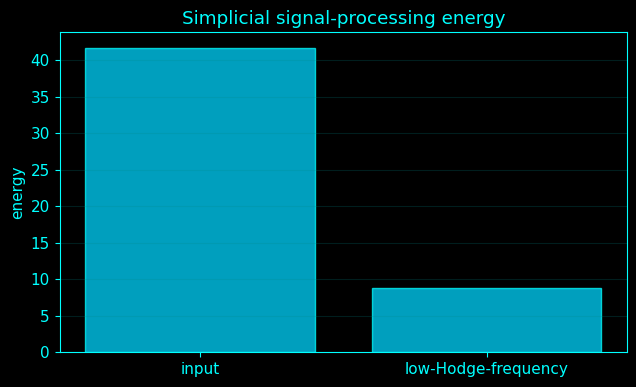

In [174]:
# Method 162: Simplicial signal processing

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_162():

    i = 162
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    ev, U = np.linalg.eigh((L1 + L1.T) / 2)
    cutoff = np.quantile(ev, 0.4) if len(ev) else 0
    filt = U @ ((ev <= cutoff) * (U.T @ flow))
    vals = [float(flow @ flow), float(filt @ filt)]
    print('input energy', vals[0], 'low-Hodge-frequency energy', vals[1])
    fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor=TOPO_BG)
    ax.bar(['input', 'low-Hodge-frequency'], vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Simplicial signal-processing energy')
    ax.set_ylabel('energy')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_162()
del _topology_method_162


### 163. Simplicial Fourier transform

The simplicial Fourier transform of an edge flow is \(\hat x=U^Tx\), where \(L_1=U\Lambda U^T\). Spectral energy \(|\hat x_i|^2\) is plotted against Hodge eigenvalue \(\lambda_i\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


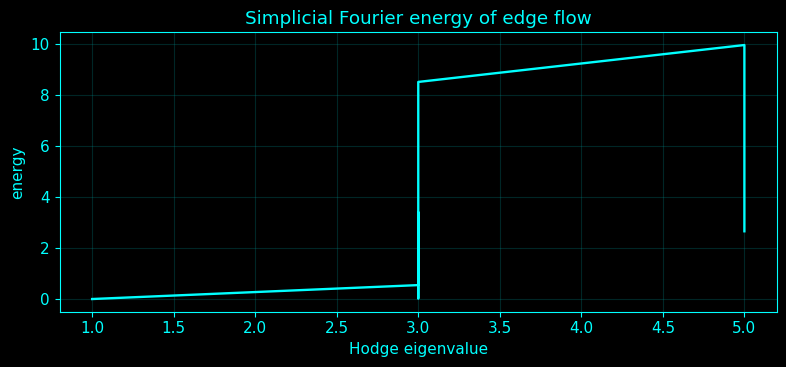

In [175]:
# Method 163: Simplicial Fourier transform

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_163():

    i = 163
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    ev, U = np.linalg.eigh((L1 + L1.T) / 2)
    coeff = U.T @ flow
    _plot_line(ev, np.abs(coeff) ** 2, 'Simplicial Fourier energy of edge flow', 'Hodge eigenvalue', 'energy')
    return


_topology_method_163()
del _topology_method_163


### 164. Edge-flow topology

Edge-flow topology applies Hodge decomposition to phase-difference flows on the functional complex and localizes large harmonic residuals to specific oriented edges.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,edge,flow,harmonic
5,"(3, 7)",-2.218786,-2.498002e-15
9,"(5, 7)",-2.880096,1.998401e-15
7,"(4, 6)",3.086509,-1.332268e-15
8,"(5, 6)",-2.608953,1.110223e-15
4,"(3, 6)",-1.947643,6.661338e-16
0,"(0, 1)",1.723014,-4.440892e-16
1,"(0, 2)",1.845742,-4.440892e-16
6,"(4, 5)",-0.587723,-2.220446e-16
10,"(6, 7)",-0.271143,1.110223e-16
2,"(1, 2)",0.122728,0.000000e+00


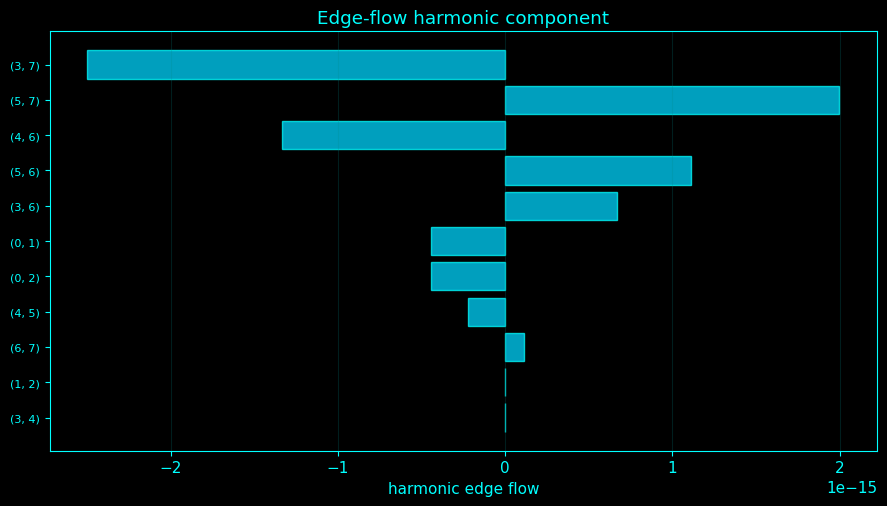

In [176]:
# Method 164: Edge-flow topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_164():

    i = 164
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_decompose(flow,B1,B2,L1):
        x=np.asarray(flow,float); grad=B1.T@np.linalg.lstsq(B1@B1.T,B1@x,rcond=None)[0] if B1.size else np.zeros_like(x)
        rem=x-grad; curl=B2@np.linalg.lstsq(B2.T@B2,B2.T@rem,rcond=None)[0] if B2.size and B2.shape[1] else np.zeros_like(x); harm=rem-curl
        return grad,curl,harm

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    g, c, h = _hodge_decompose(flow, B1, B2, L1)
    out = pd.DataFrame({'edge': [str(e) for e in simp[1]], 'flow': flow, 'harmonic': h}).sort_values('harmonic', key=np.abs, ascending=False).head(20)
    display(out)
    fig, ax = plt.subplots(figsize=(9, 5.2), facecolor=TOPO_BG)
    y = np.arange(len(out))
    ax.barh(y, out['harmonic'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(out['edge'], fontsize=8)
    ax.invert_yaxis()
    ax.set_title('Edge-flow harmonic component')
    ax.set_xlabel('harmonic edge flow')
    ax.grid(True, axis='x', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_164()
del _topology_method_164


### 165. Phase-gradient Hodge decomposition

For mean alpha-band channel phases \(\phi_i\), the oriented edge flow is the wrapped phase difference \(x_{ij}=\operatorname{Arg}e^{i(\phi_j-\phi_i)}\). Hodge decomposition separates globally potential-like phase gradients, triangle curls, and harmonic cycle circulation.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


phase-gradient Hodge energy fractions [4.95250540e-01 5.04749460e-01 3.38997054e-31]


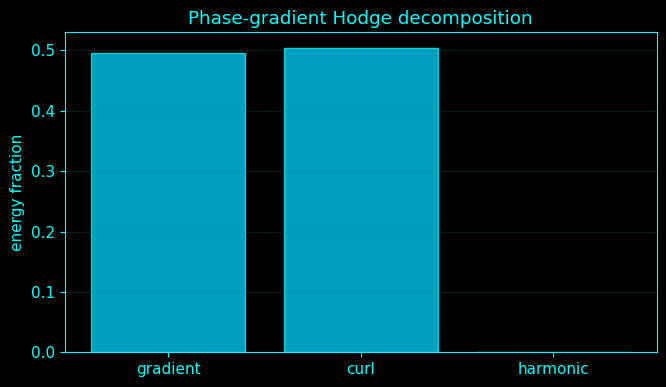

In [177]:
# Method 165: Phase-gradient Hodge decomposition

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_165():

    i = 165
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_decompose(flow,B1,B2,L1):
        x=np.asarray(flow,float); grad=B1.T@np.linalg.lstsq(B1@B1.T,B1@x,rcond=None)[0] if B1.size else np.zeros_like(x)
        rem=x-grad; curl=B2@np.linalg.lstsq(B2.T@B2,B2.T@rem,rcond=None)[0] if B2.size and B2.shape[1] else np.zeros_like(x); harm=rem-curl
        return grad,curl,harm

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    g, c, h = _hodge_decompose(flow, B1, B2, L1)
    vals = np.array([g @ g, c @ c, h @ h]) / (flow @ flow + TOPO_EPS)
    print('phase-gradient Hodge energy fractions', vals)
    fig, ax = plt.subplots(figsize=(6.8, 4.0), facecolor=TOPO_BG)
    ax.bar(['gradient', 'curl', 'harmonic'], vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Phase-gradient Hodge decomposition')
    ax.set_ylabel('energy fraction')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_165()
del _topology_method_165


### 166. Cycle-space harmonic basis

The cycle-space harmonic basis is the nullspace of the 1-Hodge Laplacian, equivalently the part of the graph cycle space orthogonal to triangle boundaries. Its dimension equals the first Betti number over the reals.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


In [178]:
# Method 166: Cycle-space harmonic basis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_166():

    i = 166
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _null_basis_real(A,tol=1e-9):
        A=np.asarray(A,float)
        if A.size==0:return np.zeros((A.shape[1] if A.ndim==2 else 0,0))
        w,V=np.linalg.eigh((A+A.T)/2); t=tol*max(1.,float(np.max(np.abs(w))) if len(w) else 1.); return V[:,np.abs(w)<=t]

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    H = _null_basis_real(L1)
    print('harmonic/cycle-space dimension =', H.shape[1])
    if H.shape[1]:
        out = pd.DataFrame(H[:, :min(3, H.shape[1])], index=[str(e) for e in simp[1]], columns=[f'h{k}' for k in range(min(3, H.shape[1]))])
        display(out)
        fig, ax = plt.subplots(figsize=(7.5, max(4, min(10, 0.24 * len(out)))), facecolor=TOPO_BG)
        vmax = max(TOPO_EPS, float(np.max(np.abs(out.to_numpy(float)))))
        im = ax.imshow(out.to_numpy(float), cmap=TOPO_CMAP, aspect='auto', vmin=-vmax, vmax=vmax)
        ax.set_title({158: 'Harmonic 1-forms', 159: 'Harmonic cycle basis', 166: 'Cycle-space harmonic basis'}[i])
        ax.set_xlabel('harmonic basis vector')
        ax.set_ylabel('edge')
        ax.set_xticks(range(len(out.columns)))
        ax.set_xticklabels(out.columns)
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    return


_topology_method_166()
del _topology_method_166


harmonic/cycle-space dimension = 0


### 167. Hodge energy by region

Regional Hodge energy sums squared harmonic edge-flow coefficients on edges incident to left, right, or midline electrode labels. This is an anatomical aggregation of a harmonic flow, not a new homology invariant.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,region,harmonic_edge_energy
0,left,8.902419e-30
1,right,1.389443e-29
2,midline,5.472723e-30


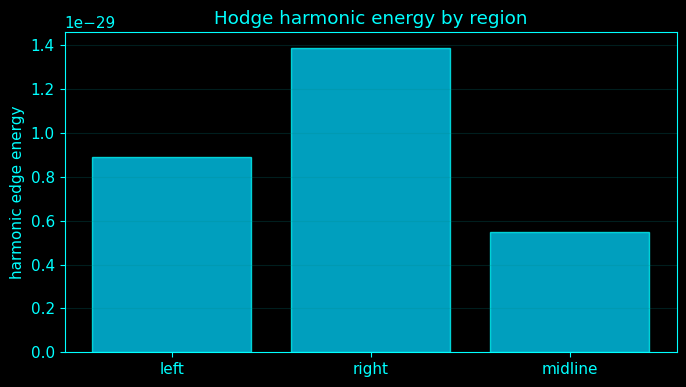

In [179]:
# Method 167: Hodge energy by region

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_167():

    i = 167
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_decompose(flow,B1,B2,L1):
        x=np.asarray(flow,float); grad=B1.T@np.linalg.lstsq(B1@B1.T,B1@x,rcond=None)[0] if B1.size else np.zeros_like(x)
        rem=x-grad; curl=B2@np.linalg.lstsq(B2.T@B2,B2.T@rem,rcond=None)[0] if B2.size and B2.shape[1] else np.zeros_like(x); harm=rem-curl
        return grad,curl,harm

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    flow = _edge_flow_from_phase(simp)
    _, _, h = _hodge_decompose(flow, B1, B2, L1)
    regs = {'left': lambda nm: nm.endswith(('1', '3', '5', '7')), 'right': lambda nm: nm.endswith(('2', '4', '6', '8')), 'midline': lambda nm: nm.endswith('z')}
    out = []
    for rn, pred in regs.items():
        ids = [k for k, (a, b) in enumerate(simp[1]) if pred(_topo_names[a]) or pred(_topo_names[b])]
        out.append([rn, float(np.sum(h[ids] ** 2))])
    out = pd.DataFrame(out, columns=['region', 'harmonic_edge_energy'])
    display(out)
    fig, ax = plt.subplots(figsize=(7, 4.0), facecolor=TOPO_BG)
    ax.bar(out['region'], out['harmonic_edge_energy'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Hodge harmonic energy by region')
    ax.set_ylabel('harmonic edge energy')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_167()
del _topology_method_167


### 168. Hodge energy by frequency band

Hodge energy by frequency band recomputes wrapped phase-difference edge flows after band-pass filtering, then reports gradient, curl, and harmonic energies for each canonical band.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,band,gradient_energy,curl_energy,harmonic_energy
0,delta,5.822879,1.842326e+01,4.032641e-30
1,theta,19.004869,1.807806e-32,8.317347e-30
2,alpha,20.658917,2.105516e+01,1.414095e-29
3,beta,14.121587,2.631895e+01,6.927955e-30
4,gamma,18.423170,1.842326e+01,9.716445e-30


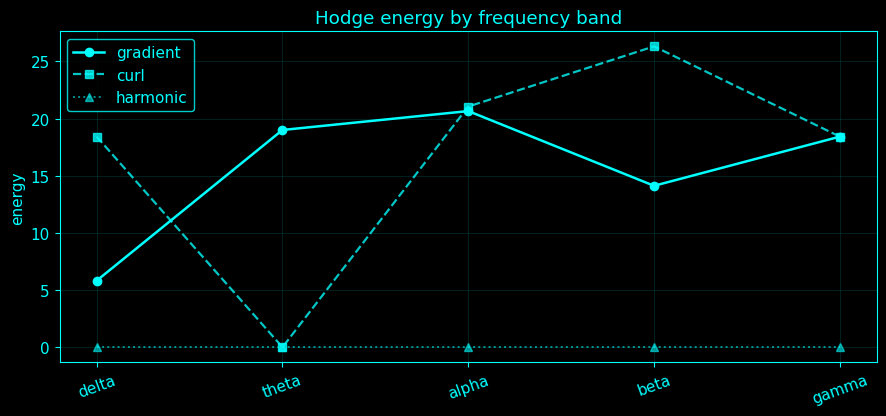

In [180]:
# Method 168: Hodge energy by frequency band

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_168():

    i = 168
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _edge_flow_from_phase(simp,lo=8,hi=13):
        n=len(simp[0]); hi=min(hi,_topo_fs/2-.5); lo=min(lo,max(.5,hi-1))
        if hi<=lo: ph=np.angle(signal.hilbert(_topo_x[:,:n],axis=0))
        else:
            Y=np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(n)]); ph=np.angle(signal.hilbert(Y,axis=0))
        meanph=np.angle(np.mean(np.exp(1j*ph),axis=0)); return np.array([np.angle(np.exp(1j*(meanph[j]-meanph[i]))) for i,j in simp[1]])

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_decompose(flow,B1,B2,L1):
        x=np.asarray(flow,float); grad=B1.T@np.linalg.lstsq(B1@B1.T,B1@x,rcond=None)[0] if B1.size else np.zeros_like(x)
        rem=x-grad; curl=B2@np.linalg.lstsq(B2.T@B2,B2.T@rem,rcond=None)[0] if B2.size and B2.shape[1] else np.zeros_like(x); harm=rem-curl
        return grad,curl,harm

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    rows = []
    for bn, (lo, hi) in _TOPO_BANDS.items():
        if hi >= _topo_fs / 2:
            continue
        flow = _edge_flow_from_phase(simp, lo, hi)
        g, c, h = _hodge_decompose(flow, B1, B2, L1)
        rows.append([bn, g @ g, c @ c, h @ h])
    out = pd.DataFrame(rows, columns=['band', 'gradient_energy', 'curl_energy', 'harmonic_energy'])
    display(out)
    fig, ax = plt.subplots(figsize=(9, 4.3), facecolor=TOPO_BG)
    for j, col in enumerate(['gradient_energy', 'curl_energy', 'harmonic_energy']):
        ax.plot(out['band'], out[col], color=TOPO_ACCENT, alpha=1 - 0.22 * j, linewidth=1.8 - 0.2 * j, marker=['o', 's', '^'][j], linestyle=['-', '--', ':'][j], label=col.replace('_energy', ''))
    ax.set_title('Hodge energy by frequency band')
    ax.set_ylabel('energy')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_168()
del _topology_method_168


### 169. Persistent harmonic representatives

Persistent harmonic representatives are followed across graph thresholds by recomputing \(\ker L_1\). The displayed harmonic dimension tracks \(\beta_1\) while edge/triangle counts show how the underlying simplicial complex changes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,threshold,harmonic_1form_dim,edges,triangles
0,0.861592,0,8,2
1,0.840530,0,10,4
2,0.837220,0,11,5
3,0.777819,0,13,11


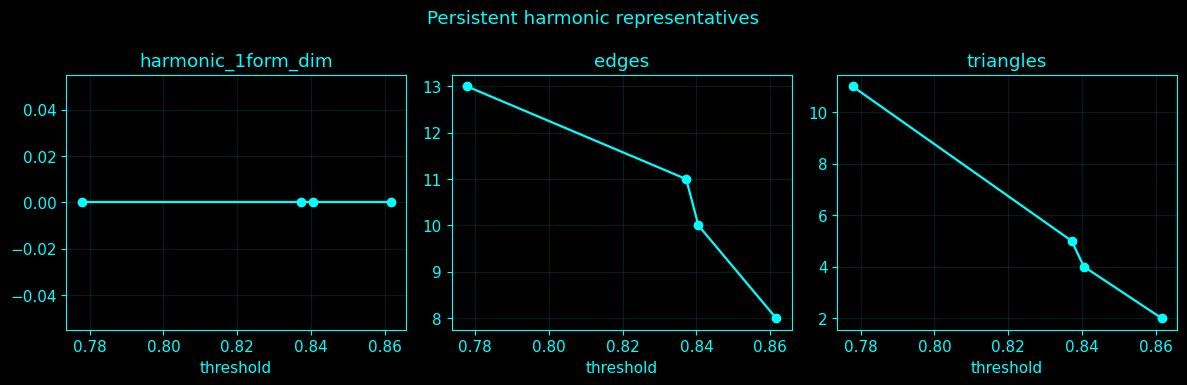

In [181]:
# Method 169: Persistent harmonic representatives

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_169():

    i = 169
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _null_basis_real(A,tol=1e-9):
        A=np.asarray(A,float)
        if A.size==0:return np.zeros((A.shape[1] if A.ndim==2 else 0,0))
        w,V=np.linalg.eigh((A+A.T)/2); t=tol*max(1.,float(np.max(np.abs(w))) if len(w) else 1.); return V[:,np.abs(w)<=t]

    # Method mathematics and output.
    S = _channel_similarity()
    rows = []
    for q in [0.72, 0.66, 0.6, 0.54]:
        sp, _, t = _flag_simplices_similarity(S, q, 3)
        b1, b2, b3 = _complex_boundaries(sp)
        _, l1, _ = _hodge_laplacians(b1, b2, b3)
        rows.append([t, _null_basis_real(l1).shape[1], len(sp[1]), len(sp.get(2, []))])
    out = pd.DataFrame(rows, columns=['threshold', 'harmonic_1form_dim', 'edges', 'triangles'])
    display(out)
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.9), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['harmonic_1form_dim', 'edges', 'triangles']):
        ax.plot(out['threshold'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.6)
        ax.set_title(col)
        ax.set_xlabel('threshold')
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Persistent harmonic representatives')
    plt.tight_layout()
    plt.show()
    return


_topology_method_169()
del _topology_method_169


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — directed topology and sheaf helpers for methods 170–198</h3>
<p>This foundation implements directed flag/path/Dowker/magnitude constructions and cellular sheaves. Path homology uses allowed directed paths satisfying boundary closure; Dowker simplices are witness-defined. For a cellular sheaf with coboundary \(\delta\), the sheaf Laplacian is \(L_{\mathcal F}=\delta^\top\delta\), so global consistency and smoothing are computed from actual restriction maps rather than an ordinary graph Laplacian relabeled as a sheaf.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [182]:
# =======================================================
# TOPOLOGY CATALOGUE — methods 170–198
# Shared mathematical helpers removed; each method cell is self-contained.
# =======================================================


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — topology methods 170–198</h3>
<p>This dispatcher runs the selected directed-complex, path/Dowker/magnitude-homology, or sheaf/cosheaf analysis. Directionality and stalk/restriction structure are preserved in their own representations rather than collapsed into an undirected graph.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


### 170. Directed flag complex

A directed flag complex contains an ordered simplex \((v_0,\ldots,v_k)\) whenever every forward edge \(v_i\to v_j\) exists for \(i<j\). Deleting any vertex preserves this property, so the alternating boundary defines a chain complex; this cell computes its H0/H1 over \(\mathbb Z_2\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


directed flag Betti: {'beta0': 2, 'beta1': 1, 'directed_edges': 13, 'directed_2simplices': 9}


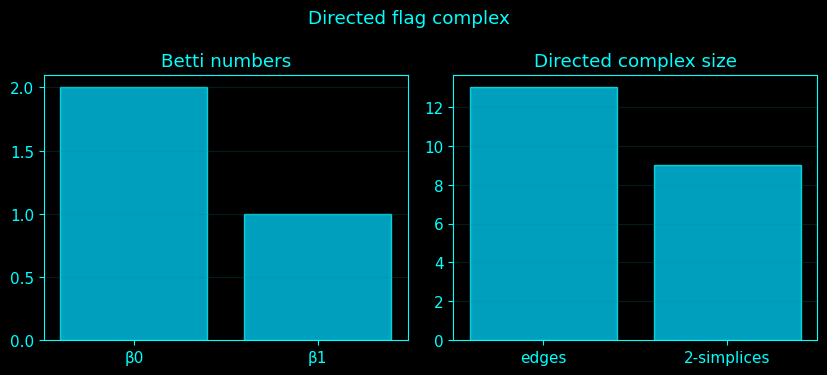

In [183]:
# Method 170: Directed flag complex

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_170():

    i = 170
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    b0, b1, sp = _directed_flag_betti(A)
    out = {'beta0': b0, 'beta1': b1, 'directed_edges': len(sp[1]), 'directed_2simplices': len(sp.get(2, []))}
    print(('directed flag' if i == 170 else 'directed graph') + ' Betti:', out)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], [b0, b1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Betti numbers')
    axs[1].bar(['edges', '2-simplices'], [len(sp[1]), len(sp.get(2, []))], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Directed complex size')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Directed flag complex' if i == 170 else 'Directed graph homology')
    plt.tight_layout()
    plt.show()
    return


_topology_method_170()
del _topology_method_170


### 171. Directed clique complex

“Directed clique complex” is used inconsistently in the literature. This notebook adopts an explicit **reciprocal-clique convention**: an undirected edge is present only when both directions exceed threshold, and the ordinary flag complex of that reciprocal graph is analyzed. The convention is stated so it is not confused with the ordered directed flag complex in the preceding cell.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [184]:
# Method 171: Directed clique complex

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_171():

    i = 171
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _flag_ph(D):
        D=np.asarray(D,float); n=len(D); cells=[]
        for i in range(n): cells.append((('v',i),0,0,[]))
        finite=np.isfinite(D)
        for i in range(n):
            for j in range(i+1,n):
                if finite[i,j]: cells.append((('e',i,j),float(D[i,j]),1,[('v',i),('v',j)]))
        for i in range(n):
            for j in range(i+1,n):
                if not finite[i,j]: continue
                for k in range(j+1,n):
                    if finite[i,k] and finite[j,k]: cells.append((('t',i,j,k),float(max(D[i,j],D[i,k],D[j,k])),2,[('e',i,j),('e',i,k),('e',j,k)]))
        return _ph_cells(cells,1)

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    M = A & A.T
    D = np.where(M, 0.0, np.inf)
    np.fill_diagonal(D, 0)
    dg = _flag_ph(D)
    print('reciprocal directed-clique H1 positive classes=', len(_life(dg[1])))
    return
    b0, b1, sp = _directed_flag_betti(A)
    out = {'beta0': b0, 'beta1': b1, 'directed_edges': len(sp[1]), 'directed_2simplices': len(sp.get(2, []))}
    print(('directed flag' if i == 170 else 'directed graph') + ' Betti:', out)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], [b0, b1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Betti numbers')
    axs[1].bar(['edges', '2-simplices'], [len(sp[1]), len(sp.get(2, []))], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Directed complex size')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Directed flag complex' if i == 170 else 'Directed graph homology')
    plt.tight_layout()
    plt.show()
    return


_topology_method_171()
del _topology_method_171


reciprocal directed-clique H1 positive classes= 0


### 172. Path homology

Path homology is built from allowed directed paths. For H1, all directed edges form \(\Omega_1\); \(\Omega_2\) consists linear combinations of allowed 2-paths whose boundaries contain no non-allowed edge terms. The notebook constructs that boundary-closed subspace explicitly over \(\mathbb Z_2\) and computes \(H_1=\ker\partial_1/\operatorname{im}\partial_2\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [185]:
# Method 172: Path homology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_172():

    i = 172
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _path_homology_H1(A):
        A=np.asarray(A,bool);n=len(A);edges=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]];eidx={e:i for i,e in enumerate(edges)}
        B1=np.zeros((n,len(edges)),dtype=np.uint8)
        for q,(i,j) in enumerate(edges):B1[i,q]=1;B1[j,q]=1
        paths=[(i,j,k) for i in range(n) for j in range(n) for k in range(n) if len({i,j,k})==3 and A[i,j] and A[j,k]]
        nonedges=sorted({(i,k) for i,j,k in paths if not A[i,k]});neidx={e:i for i,e in enumerate(nonedges)};U=np.zeros((len(nonedges),len(paths)),dtype=np.uint8);V=np.zeros((len(edges),len(paths)),dtype=np.uint8)
        for q,(i,j,k) in enumerate(paths):
            V[eidx[(i,j)],q]^=1;V[eidx[(j,k)],q]^=1
            if (i,k) in eidx:V[eidx[(i,k)],q]^=1
            else:U[neidx[(i,k)],q]^=1
        Z=_gf2_nullspace(U);B2=(V@Z)%2 if Z.shape[1] else np.zeros((len(edges),0),dtype=np.uint8);b1=(len(edges)-_gf2_rank(B1))-_gf2_rank(B2)
        return int(max(0,b1)),B1,B2,edges,paths

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    b1, *_ = _path_homology_H1(A)
    print('Path-homology beta1 =', b1)
    return


_topology_method_172()
del _topology_method_172


Path-homology beta1 = 1


### 173. Persistent path homology

Persistent path homology recomputes path-homology \(\beta_1\) as the directed-weight threshold changes. Because general path-homology persistence modules require compatible inclusion maps between the \(\Omega_p\) spaces, this cell reports the thresholded Betti trajectory rather than claiming a barcode that was not constructed.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,directed_weight_threshold,path_beta1
0,0.433040,0
1,0.465350,0
2,0.507967,0
3,0.522560,0
4,0.553994,1
5,0.565974,0
6,0.576790,1
7,0.631777,0


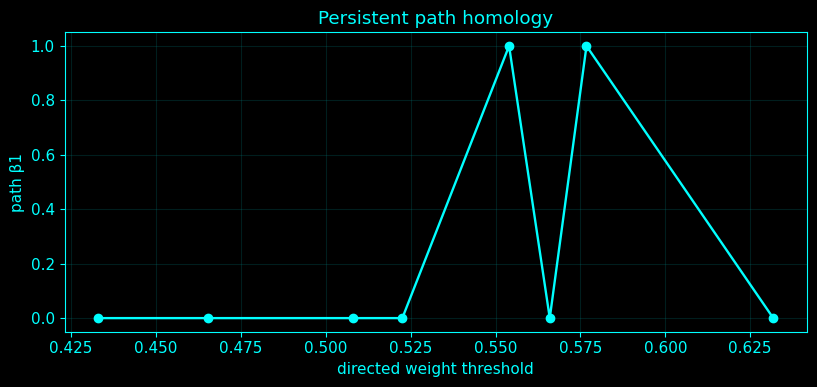

In [186]:
# Method 173: Persistent path homology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_173():

    i = 173
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _path_homology_H1(A):
        A=np.asarray(A,bool);n=len(A);edges=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]];eidx={e:i for i,e in enumerate(edges)}
        B1=np.zeros((n,len(edges)),dtype=np.uint8)
        for q,(i,j) in enumerate(edges):B1[i,q]=1;B1[j,q]=1
        paths=[(i,j,k) for i in range(n) for j in range(n) for k in range(n) if len({i,j,k})==3 and A[i,j] and A[j,k]]
        nonedges=sorted({(i,k) for i,j,k in paths if not A[i,k]});neidx={e:i for i,e in enumerate(nonedges)};U=np.zeros((len(nonedges),len(paths)),dtype=np.uint8);V=np.zeros((len(edges),len(paths)),dtype=np.uint8)
        for q,(i,j,k) in enumerate(paths):
            V[eidx[(i,j)],q]^=1;V[eidx[(j,k)],q]^=1
            if (i,k) in eidx:V[eidx[(i,k)],q]^=1
            else:U[neidx[(i,k)],q]^=1
        Z=_gf2_nullspace(U);B2=(V@Z)%2 if Z.shape[1] else np.zeros((len(edges),0),dtype=np.uint8);b1=(len(edges)-_gf2_rank(B1))-_gf2_rank(B2)
        return int(max(0,b1)),B1,B2,edges,paths

    # Method mathematics and output.
    W = _directed_scores('lag')
    rows = []
    for q in np.linspace(0.5, 0.85, 8):
        AA, t = _digraph_from_scores(W, float(q), True)
        b1, *_ = _path_homology_H1(AA)
        rows.append([t, b1])
    out = pd.DataFrame(rows, columns=['directed_weight_threshold', 'path_beta1'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.3, 4.0), facecolor=TOPO_BG)
    ax.plot(out['directed_weight_threshold'], out['path_beta1'], color=TOPO_ACCENT, marker='o', linewidth=1.7)
    ax.set_title('Persistent path homology')
    ax.set_xlabel('directed weight threshold')
    ax.set_ylabel('path β1')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_173()
del _topology_method_173


### 174. Dowker persistence

For an asymmetric dissimilarity \(D(s,t)\), the Dowker source simplex \(\sigma\) enters at \(\min_t\max_{s\in\sigma}D(s,t)\): the smallest radius at which all sources share a witness target. These simplex filtration values define a genuine Dowker filtration, from which H1 persistence is reduced.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


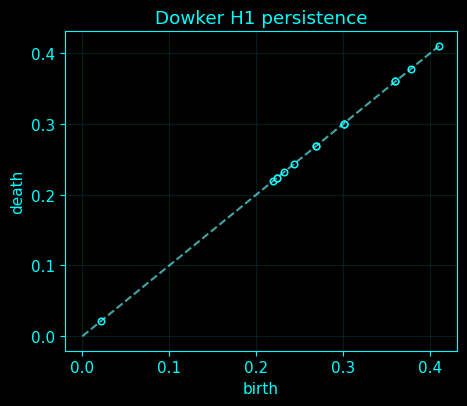

In [187]:
# Method 174: Dowker persistence

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_174():

    i = 174
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    def _ph_simplices_nd(ss, max_hom_dim):
        index={simp:i for i,(simp,_,_) in enumerate(ss)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(simp,filt,dim) in enumerate(ss):
            if dim==0:
                col=set()
            else:
                col={index[simp[:q]+simp[q+1:]] for q in range(len(simp))}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j
                bdim=ss[low][2]
                if bdim<=max_hom_dim: pairs.append((bdim,float(ss[low][1]),float(filt)))
            else:
                births.add(j)
        paired=set(low_to_col)
        dg=[]
        for d in range(max_hom_dim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if ss[j][2]==d: arr.append([float(ss[j][1]),np.inf])
            dg.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2),float))
        return dg

    def _dowker_ph(W,maxdim=1):
        W=np.asarray(W,float);mx=np.max(W);D=mx-W;np.fill_diagonal(D,0);n=len(W);ss=[]
        for r in range(1,maxdim+3):
            dim=r-1
            for s in combinations(range(n),r):
                filt=min(max(D[v,t] for v in s) for t in range(n));ss.append((tuple(s),float(filt),dim))
        ss.sort(key=lambda z:(z[1],z[2],z[0]));return _ph_simplices_nd(ss,maxdim)

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    W = _directed_scores('lag')
    dg = _dowker_ph(W, 1)
    _plot_diag(dg[1], 'Dowker H1 persistence')
    return


_topology_method_174()
del _topology_method_174


### 175. Magnitude homology

Magnitude homology refines metric information by a length grading. For an unweighted graph metric and H1, \(MC_{1,\ell}\) is generated by ordered pairs at distance \(\ell\); the middle-point boundary of a 2-path contributes only when deleting the middle point preserves total length. Thus \(MH_{1,\ell}=MC_{1,\ell}/\operatorname{im}\partial_2\) because \(\partial_1=0\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,length,rank_MH1,MC1_generators,MC2_generators
0,1,14,14,0
1,2,0,8,34
2,3,0,8,40


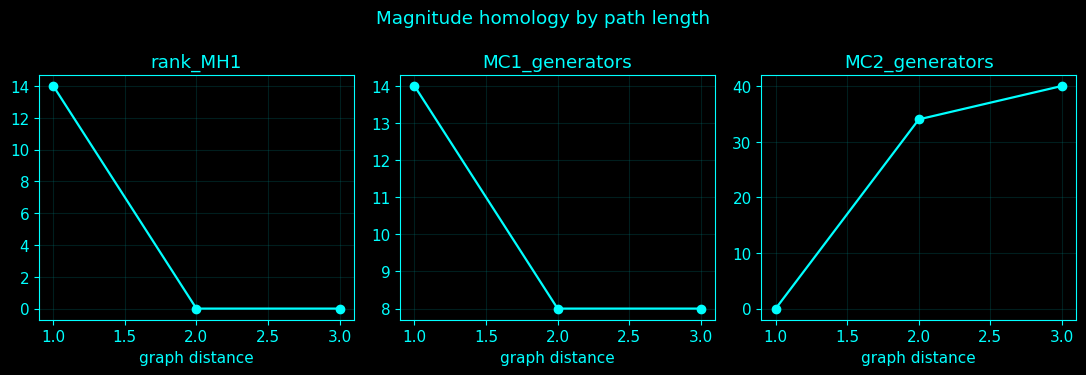

In [188]:
# Method 175: Magnitude homology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_175():

    i = 175
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _magnitude_H1_graph(A):
        G=nx.from_numpy_array(np.asarray(A|A.T,dtype=int));
        if not nx.is_connected(G):G=G.subgraph(max(nx.connected_components(G),key=len)).copy()
        nodes=list(G.nodes());dist=dict(nx.all_pairs_shortest_path_length(G));diam=nx.diameter(G);rows=[]
        for ell in range(1,diam+1):
            pairs=[(a,b) for a in nodes for b in nodes if a!=b and dist[a][b]==ell];pidx={p:i for i,p in enumerate(pairs)};trip=[]
            for a in nodes:
                for b in nodes:
                    for c in nodes:
                        if a!=b and b!=c and dist[a][b]+dist[b][c]==ell:trip.append((a,b,c))
            B=np.zeros((len(pairs),len(trip)),dtype=np.uint8)
            for q,(a,b,c) in enumerate(trip):
                if dist[a][c]==dist[a][b]+dist[b][c] and (a,c) in pidx:B[pidx[(a,c)],q]^=1
            rows.append([ell,len(pairs)-_gf2_rank(B),len(pairs),len(trip)])
        return pd.DataFrame(rows,columns=['length','rank_MH1','MC1_generators','MC2_generators'])

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    out = _magnitude_H1_graph(A)
    display(out)
    fig, axs = plt.subplots(1, 3, figsize=(11, 3.8), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['rank_MH1', 'MC1_generators', 'MC2_generators']):
        ax.plot(out['length'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.6)
        ax.set_title(col)
        ax.set_xlabel('graph distance')
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Magnitude homology by path length')
    plt.tight_layout()
    plt.show()
    return


_topology_method_175()
del _topology_method_175


### 176. Directed graph homology

Directed graph homology here means homology of the ordered directed flag complex defined in method 170. The cell reports H0/H1 together with directed simplex counts so the exact directed-complex convention is visible.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


directed graph Betti: {'beta0': 2, 'beta1': 1, 'directed_edges': 13, 'directed_2simplices': 9}


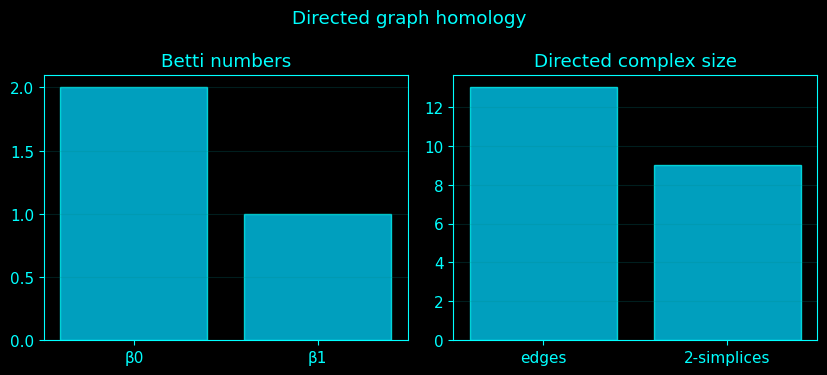

In [189]:
# Method 176: Directed graph homology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_176():

    i = 176
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    b0, b1, sp = _directed_flag_betti(A)
    out = {'beta0': b0, 'beta1': b1, 'directed_edges': len(sp[1]), 'directed_2simplices': len(sp.get(2, []))}
    print(('directed flag' if i == 170 else 'directed graph') + ' Betti:', out)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], [b0, b1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Betti numbers')
    axs[1].bar(['edges', '2-simplices'], [len(sp[1]), len(sp.get(2, []))], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Directed complex size')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Directed flag complex' if i == 170 else 'Directed graph homology')
    plt.tight_layout()
    plt.show()
    return


_topology_method_176()
del _topology_method_176


### 177. Causal clique topology

Causal-clique topology uses one-step lagged predictive association as a directed edge score, thresholds it, and builds the directed flag complex. The lag statistic is an observational linear dependence score; without intervention or a complete causal model the result is not asserted to identify physical causation.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


lag {'threshold': 0.5539938467777487, 'beta0': 2, 'beta1': 1, 'edges': 13, 'feedforward_2simplices': 9}


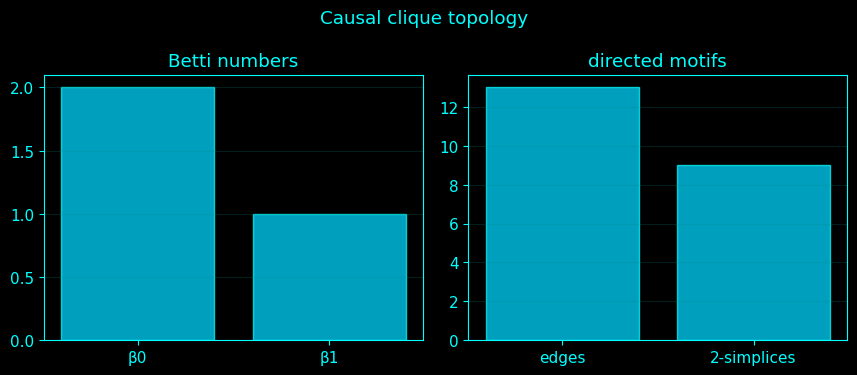

In [190]:
# Method 177: Causal clique topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_177():

    i = 177
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    kind = {177: 'lag', 178: 'te', 179: 'phase'}[i]
    WW = _directed_scores(kind)
    AA, t = _digraph_from_scores(WW, 0.7, True)
    b0, b1, sp = _directed_flag_betti(AA)
    out = {'threshold': t, 'beta0': b0, 'beta1': b1, 'edges': len(sp[1]), 'feedforward_2simplices': len(sp.get(2, []))}
    print(kind, out)
    fig, axs = plt.subplots(1, 2, figsize=(8.8, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], [b0, b1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Betti numbers')
    axs[1].bar(['edges', '2-simplices'], [len(sp[1]), len(sp.get(2, []))], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('directed motifs')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle({'lag': 'Causal clique topology', 'te': 'Transfer-entropy directed topology', 'phase': 'Directed phase-lag topology'}[kind])
    plt.tight_layout()
    plt.show()
    return


_topology_method_177()
del _topology_method_177


### 178. Transfer-entropy directed topology

Transfer entropy is estimated discretely as \(T_{X\to Y}=I(X_t;Y_{t+1}\mid Y_t)\). Directed edges are thresholded from these pairwise values and the directed flag complex is analyzed. Finite-bin TE is an estimator whose value depends on discretization and sample size.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


te {'threshold': 0.07352806921755958, 'beta0': 1, 'beta1': 5, 'edges': 13, 'feedforward_2simplices': 2}


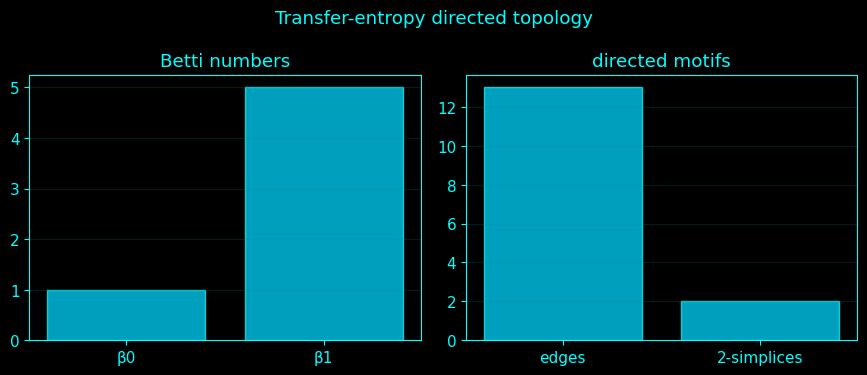

In [191]:
# Method 178: Transfer-entropy directed topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_178():

    i = 178
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    kind = {177: 'lag', 178: 'te', 179: 'phase'}[i]
    WW = _directed_scores(kind)
    AA, t = _digraph_from_scores(WW, 0.7, True)
    b0, b1, sp = _directed_flag_betti(AA)
    out = {'threshold': t, 'beta0': b0, 'beta1': b1, 'edges': len(sp[1]), 'feedforward_2simplices': len(sp.get(2, []))}
    print(kind, out)
    fig, axs = plt.subplots(1, 2, figsize=(8.8, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], [b0, b1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Betti numbers')
    axs[1].bar(['edges', '2-simplices'], [len(sp[1]), len(sp.get(2, []))], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('directed motifs')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle({'lag': 'Causal clique topology', 'te': 'Transfer-entropy directed topology', 'phase': 'Directed phase-lag topology'}[kind])
    plt.tight_layout()
    plt.show()
    return


_topology_method_178()
del _topology_method_178


### 179. Directed phase-lag topology

Directed phase-lag topology uses the antisymmetric score \(s_{ij}=\max(0,\langle\sin(\phi_i-\phi_j)\rangle)\). Positive score defines the notebook's explicit i→j lead convention; thresholded scores generate a directed flag complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


phase {'threshold': 0.05483688787286688, 'beta0': 1, 'beta1': 0, 'edges': 13, 'feedforward_2simplices': 10}


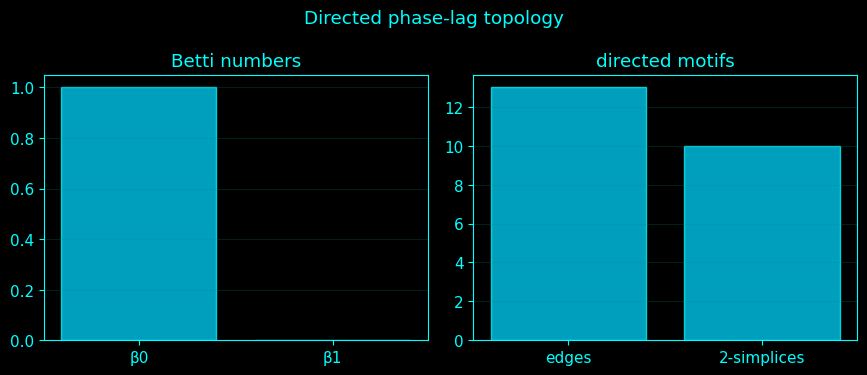

In [192]:
# Method 179: Directed phase-lag topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_179():

    i = 179
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    kind = {177: 'lag', 178: 'te', 179: 'phase'}[i]
    WW = _directed_scores(kind)
    AA, t = _digraph_from_scores(WW, 0.7, True)
    b0, b1, sp = _directed_flag_betti(AA)
    out = {'threshold': t, 'beta0': b0, 'beta1': b1, 'edges': len(sp[1]), 'feedforward_2simplices': len(sp.get(2, []))}
    print(kind, out)
    fig, axs = plt.subplots(1, 2, figsize=(8.8, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], [b0, b1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Betti numbers')
    axs[1].bar(['edges', '2-simplices'], [len(sp[1]), len(sp.get(2, []))], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('directed motifs')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle({'lag': 'Causal clique topology', 'te': 'Transfer-entropy directed topology', 'phase': 'Directed phase-lag topology'}[kind])
    plt.tight_layout()
    plt.show()
    return


_topology_method_179()
del _topology_method_179


### 180. Temporal directed topology

Temporal directed topology recomputes the directed lag-association graph in sliding windows and tracks directed-complex Betti numbers. This measures time variation of the chosen directed graph model, not a time-directed simplicial complex in one higher dimension.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,time_s,directed_beta0,directed_beta1
0,1.40,3,0
1,2.64,3,0
2,3.88,3,1
3,5.12,3,0
4,6.36,2,1
5,7.60,1,4
6,8.84,2,0
7,10.08,2,1
8,11.32,2,0
9,12.56,2,0


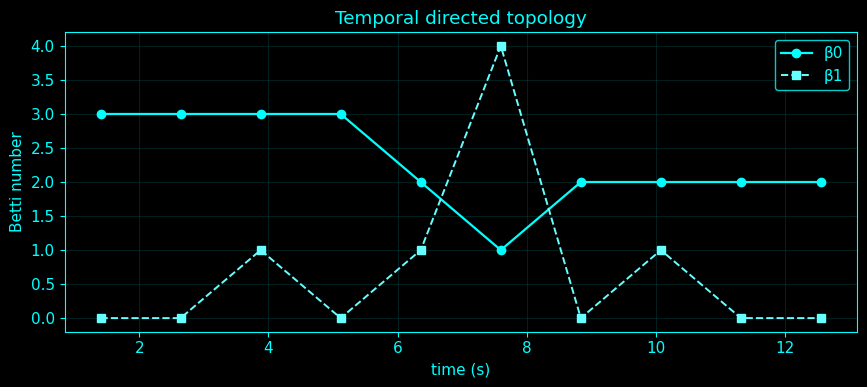

In [193]:
# Method 180: Temporal directed topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_180():

    i = 180
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    # Method mathematics and output.
    W = _directed_scores('lag')
    rows = []
    nw = min(_TOPO_SPEED['windows'], 10)
    for st, en, _ in _windows(_topo_pc1, nw):
        seg = _topo_x[st:en, :W.shape[0]]
        save = _topo_x
        WW = np.zeros_like(W)
        for a in range(len(W)):
            for b in range(len(W)):
                if a != b:
                    WW[a, b] = abs(np.corrcoef(seg[:-1, a], seg[1:, b])[0, 1])
        AA, _ = _digraph_from_scores(WW, 0.7, True)
        b0, b1, _ = _directed_flag_betti(AA)
        rows.append([(st + en) / (2 * _topo_fs), b0, b1])
    out = pd.DataFrame(rows, columns=['time_s', 'directed_beta0', 'directed_beta1'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.8, 4.0), facecolor=TOPO_BG)
    ax.plot(out['time_s'], out['directed_beta0'], color=TOPO_ACCENT, marker='o', linewidth=1.6, label='β0')
    ax.plot(out['time_s'], out['directed_beta1'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='β1')
    ax.set_title('Temporal directed topology')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('Betti number')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_180()
del _topology_method_180


### 181. Source-sink topological structure

Source–sink structure is summarized by directed out-degree minus in-degree. Positive values identify graph sources under the selected threshold; negative values identify sinks. This is a directed-network descriptor complementary to homology.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,channel,out_degree,in_degree,source_sink_index
5,Fz,3,2,1
1,Fpz,2,2,0
0,Fp1,3,3,0
2,Fp2,2,2,0
4,F3,0,0,0
6,F4,2,2,0
3,F7,1,2,-1


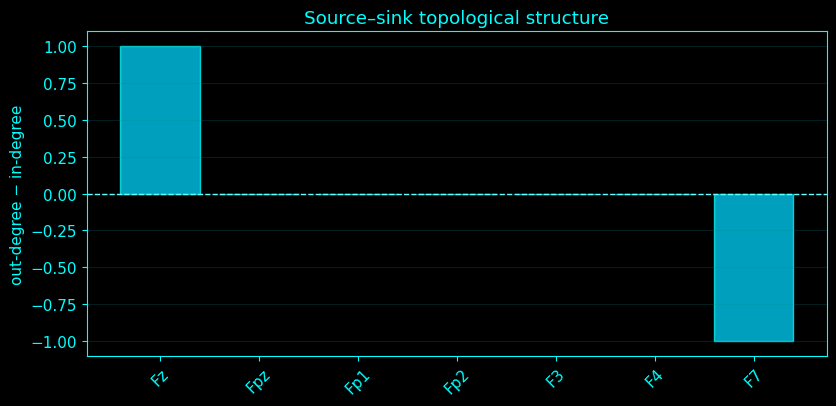

In [194]:
# Method 181: Source-sink topological structure

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_181():

    i = 181
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    outdeg = A.sum(1)
    inn = A.sum(0)
    out = pd.DataFrame({'channel': _topo_names[:len(A)], 'out_degree': outdeg, 'in_degree': inn, 'source_sink_index': outdeg - inn}).sort_values('source_sink_index', ascending=False)
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.2), facecolor=TOPO_BG)
    ax.bar(out['channel'], out['source_sink_index'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.axhline(0, color=TOPO_CYAN_SOFT, linewidth=1.0, linestyle='--')
    ax.set_title('Source–sink topological structure')
    ax.set_ylabel('out-degree − in-degree')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_181()
del _topology_method_181


### 182. Directed cycle persistence

Directed cycle persistence is summarized across directed-weight thresholds by counting simple directed cycles and their mean lengths. This is a threshold-persistence profile of graph cycles; it is not an ordinary persistence barcode because directed simple-cycle identities do not have canonical interval pairings under edge addition.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,threshold,directed_cycle_count,mean_cycle_length
0,0.433040,32,3.312500
1,0.465350,20,2.750000
2,0.507967,16,2.625000
3,0.522560,13,2.538462
4,0.553994,9,2.333333
5,0.565974,6,2.333333
6,0.576790,6,2.333333
7,0.631777,5,2.400000
8,0.753955,3,2.333333


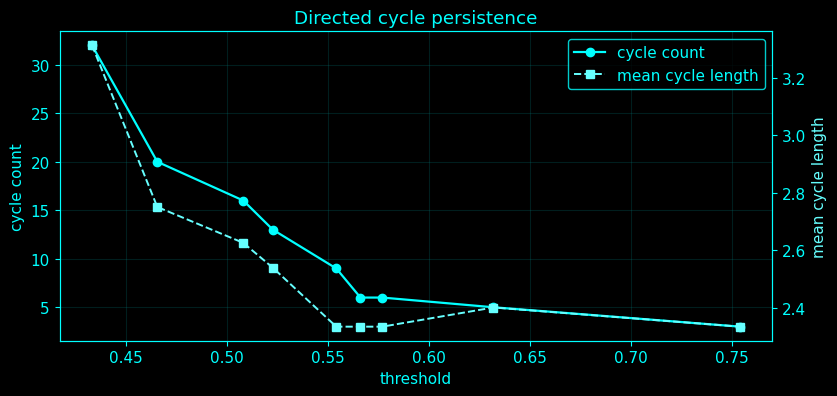

In [195]:
# Method 182: Directed cycle persistence

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_182():

    i = 182
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    W = _directed_scores('lag')
    rows = []
    for q in np.linspace(0.5, 0.9, 9):
        AA, t = _digraph_from_scores(W, float(q), True)
        G = nx.from_numpy_array(AA, create_using=nx.DiGraph)
        cycles = list(nx.simple_cycles(G, length_bound=6))
        rows.append([t, len(cycles), np.mean([len(c) for c in cycles]) if cycles else 0])
    out = pd.DataFrame(rows, columns=['threshold', 'directed_cycle_count', 'mean_cycle_length'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.1), facecolor=TOPO_BG)
    ax2 = ax.twinx()
    ax.plot(out['threshold'], out['directed_cycle_count'], color=TOPO_ACCENT, marker='o', linewidth=1.6, label='cycle count')
    ax2.plot(out['threshold'], out['mean_cycle_length'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='mean cycle length')
    ax.set_title('Directed cycle persistence')
    ax.set_xlabel('threshold')
    ax.set_ylabel('cycle count')
    ax2.set_ylabel('mean cycle length', color=TOPO_CYAN_SOFT)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc='best')
    plt.tight_layout()
    plt.show()
    return


_topology_method_182()
del _topology_method_182


### 183. Feedforward motif topology

A feedforward motif i→j, j→k, i→k is exactly an ordered 2-simplex in the directed flag complex. Counting directed 2-simplices therefore measures feedforward transitive motifs in the chosen directed graph.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [196]:
# Method 183: Feedforward motif topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_183():

    i = 183
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _digraph_from_scores(W,q=.70,allow_mutual=True):
        W=np.asarray(W,float); vals=W[~np.eye(len(W),dtype=bool)]; th=float(np.quantile(vals,q)); A=W>=th;np.fill_diagonal(A,False)
        if not allow_mutual:
            for i in range(len(W)):
                for j in range(i+1,len(W)):
                    if A[i,j] and A[j,i]:
                        if W[i,j]>=W[j,i]:A[j,i]=False
                        else:A[i,j]=False
        return A,th

    def _directed_boundary(low,high):
        il={s:i for i,s in enumerate(low)};B=np.zeros((len(low),len(high)),dtype=np.uint8)
        for j,s in enumerate(high):
            for q in range(len(s)):
                f=s[:q]+s[q+1:]
                if f in il:B[il[f],j]^=1
        return B

    def _directed_flag_simplices(A,maxdim=2):
        A=np.asarray(A,bool);n=len(A);simp={0:[(i,) for i in range(n)]}
        simp[1]=[(i,j) for i in range(n) for j in range(n) if i!=j and A[i,j]]
        if maxdim>=2:
            s2=[]
            for i in range(n):
                for j in range(n):
                    if i==j or not A[i,j]:continue
                    for k in range(n):
                        if k in (i,j):continue
                        if A[i,k] and A[j,k]:s2.append((i,j,k))
            simp[2]=s2
        return simp

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _directed_flag_betti(A):
        sp=_directed_flag_simplices(A,2);B1=_directed_boundary(sp[0],sp[1]);B2=_directed_boundary(sp[1],sp.get(2,[]));b0=len(sp[0])-_gf2_rank(B1);b1=(len(sp[1])-_gf2_rank(B1))-_gf2_rank(B2);return int(b0),int(b1),sp

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _directed_scores(kind='lag',nch=None):
        if nch is None:nch=min(_topo_x.shape[1],10 if FAST_OPTION=='full' else 9 if FAST_OPTION=='balanced' else 8 if FAST_OPTION=='fast' else 7)
        X=_topo_x[:,:nch]; n=nch; W=np.zeros((n,n),float)
        if kind=='lag':
            for i in range(n):
                for j in range(n):
                    if i!=j: W[i,j]=abs(np.corrcoef(X[:-1,i],X[1:,j])[0,1])
        elif kind=='te':
            bins=np.linspace(-2.5,2.5,7); Z=np.clip(np.digitize(X,bins),0,len(bins))
            for i in range(n):
                for j in range(n):
                    if i==j:continue
                    # I(X_t ; Y_{t+1} | Y_t) via discrete counts
                    x=Z[:-1,i]; y=Z[:-1,j]; yp=Z[1:,j]; key=np.ravel_multi_index((x,y,yp),(len(bins)+1,)*3); cxyz=np.bincount(key,minlength=(len(bins)+1)**3).reshape((len(bins)+1,)*3).astype(float); p=cxyz/cxyz.sum();
                    pxy=p.sum(2); pyy=p.sum(0); py=pxy.sum(0); val=0.
                    for a in range(p.shape[0]):
                        for b in range(p.shape[1]):
                            for c in range(p.shape[2]):
                                if p[a,b,c]>0 and pxy[a,b]>0 and pyy[b,c]>0 and py[b]>0: val+=p[a,b,c]*np.log((p[a,b,c]*py[b])/(pxy[a,b]*pyy[b,c])+TOPO_EPS)
                    W[i,j]=max(0.,val)
        elif kind=='phase':
            hi=min(13,_topo_fs/2-.5);lo=min(8,max(.5,hi-2));Y=np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(n)]) if hi>lo else X;ph=np.angle(signal.hilbert(Y,axis=0))
            for i in range(n):
                for j in range(n):
                    if i!=j:W[i,j]=max(0.,float(np.mean(np.sin(ph[:,i]-ph[:,j]))))
        return W

    # Method mathematics and output.
    W = _directed_scores('lag')
    A, th = _digraph_from_scores(W, 0.7, allow_mutual=True)
    _, _, sp = _directed_flag_betti(A)
    print('feedforward directed 2-simplices =', len(sp.get(2, [])))
    return


_topology_method_183()
del _topology_method_183


feedforward directed 2-simplices = 9


### 184. Cellular sheaf on electrode graph

A cellular sheaf assigns vector spaces (stalks) to cells and linear restriction maps from vertices to incident edges. Here each vertex/edge has a rank-1 stalk and the restriction on v→e is multiplication by a local amplitude scale. The sheaf coboundary is \((\delta x)_e=F_{v,e}x_v-F_{u,e}x_u\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


cellular sheaf: vertex stalk dim=1, edge stalk dim=1, vertices= 8 edges= 12 coboundary shape= (12, 8)


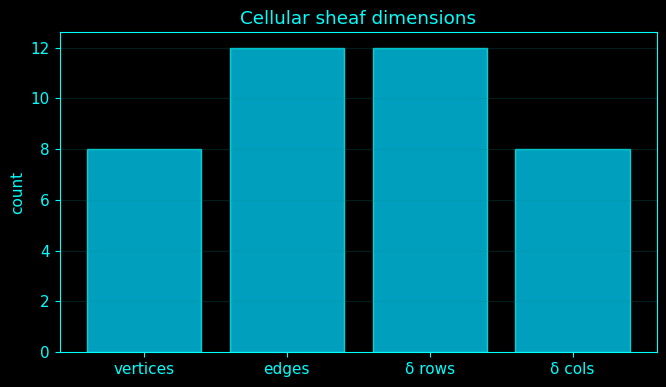

In [197]:
# Method 184: Cellular sheaf on electrode graph

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_184():

    i = 184
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('scalar', n)
    D = _sheaf_delta(edges, F)
    print('cellular sheaf: vertex stalk dim=1, edge stalk dim=1, vertices=', n, 'edges=', len(edges), 'coboundary shape=', D.shape)
    fig, ax = plt.subplots(figsize=(6.8, 4.0), facecolor=TOPO_BG)
    ax.bar(['vertices', 'edges', 'δ rows', 'δ cols'], [n, len(edges), D.shape[0], D.shape[1]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Cellular sheaf dimensions')
    ax.set_ylabel('count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_184()
del _topology_method_184


### 185. Sheaf Laplacian

For a graph sheaf with coboundary \(\delta:C^0\to C^1\), the 0-sheaf Laplacian is \(L_\mathcal F=\delta^T\delta\). Its quadratic form \(x^TL_\mathcal Fx=\|\delta x\|^2\) measures inconsistency of vertex assignments under the restriction maps.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


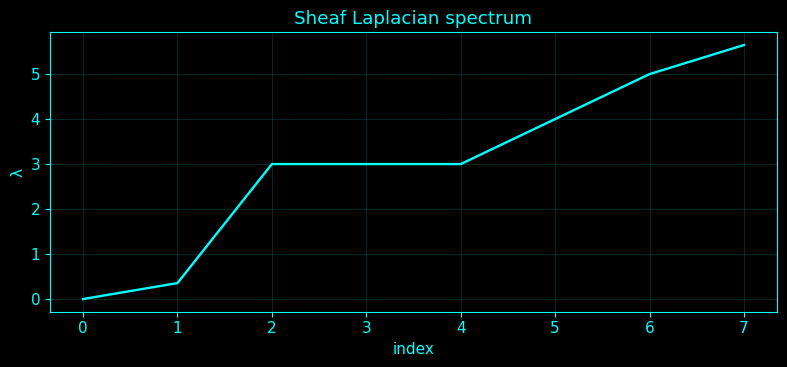

In [198]:
# Method 185: Sheaf Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_185():

    i = 185
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('scalar', n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    ev = np.linalg.eigvalsh(L)
    _plot_line(np.arange(len(ev)), ev, 'Sheaf Laplacian spectrum', 'index', 'λ')
    return


_topology_method_185()
del _topology_method_185


### 186. Sheaf cohomology

On a one-dimensional cell complex, sheaf cohomology is \(H^0=\ker\delta\) and \(H^1=C^1/\operatorname{im}\delta\). Their dimensions are therefore \(\dim C^0-\operatorname{rank}\delta\) and \(\dim C^1-\operatorname{rank}\delta\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


sheaf cohomology dimensions H0= 1 H1= 5


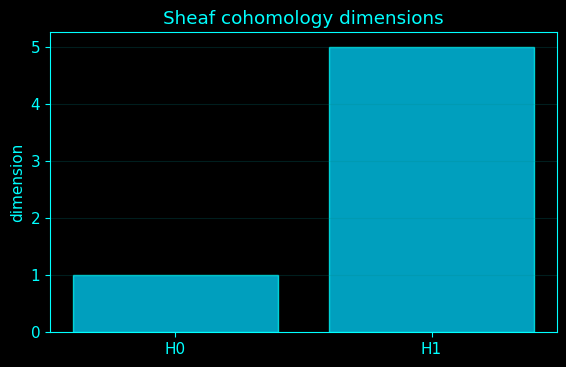

In [199]:
# Method 186: Sheaf cohomology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_186():

    i = 186
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('scalar', n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    print('sheaf cohomology dimensions H0=', h0, 'H1=', h1)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['H0', 'H1'], [h0, h1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Sheaf cohomology dimensions')
    ax.set_ylabel('dimension')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return
    ev = np.linalg.eigvalsh(L)
    _plot_line(np.arange(len(ev)), ev, 'Sheaf Laplacian spectrum', 'index', 'λ')
    return


_topology_method_186()
del _topology_method_186


### 187. Persistent sheaf cohomology

Persistent sheaf cohomology is evaluated along the edge-threshold filtration while retaining the same stalk/restriction rule. The notebook tracks \(\dim H^0\) and \(\dim H^1\) as the underlying electrode graph grows.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,similarity_threshold,edges,dim_H0_sheaf,dim_H1_sheaf
0,0.697100,14,1,7
1,0.837220,11,2,5
2,0.855843,9,2,3
3,0.883524,6,3,1


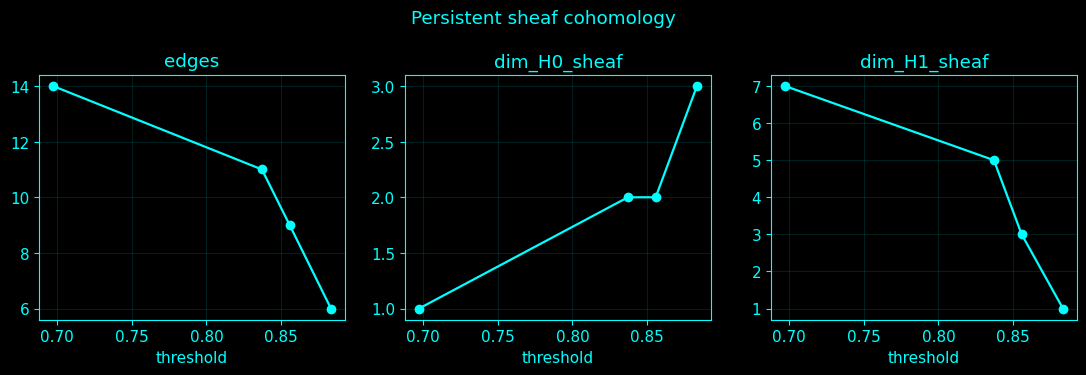

In [200]:
# Method 187: Persistent sheaf cohomology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_187():

    i = 187
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    rows = []
    vals = S[np.triu_indices(n, 1)]
    for q in [0.5, 0.6, 0.7, 0.8]:
        cut = np.quantile(vals, q)
        ee = [(a, b) for a in range(n) for b in range(a + 1, n) if S[a, b] >= cut]
        D = _sheaf_delta(ee, _feature_matrix('scalar', n))
        _, h0, h1 = _sheaf_stats(D)
        rows.append([cut, len(ee), h0, h1])
    out = pd.DataFrame(rows, columns=['similarity_threshold', 'edges', 'dim_H0_sheaf', 'dim_H1_sheaf'])
    display(out)
    fig, axs = plt.subplots(1, 3, figsize=(11, 3.8), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['edges', 'dim_H0_sheaf', 'dim_H1_sheaf']):
        ax.plot(out['similarity_threshold'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.6)
        ax.set_title(col)
        ax.set_xlabel('threshold')
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Persistent sheaf cohomology')
    plt.tight_layout()
    plt.show()
    return


_topology_method_187()
del _topology_method_187


### 188. Dynamic sheaf Laplacian

Dynamic sheaf analysis keeps the electrode incidence structure fixed but recomputes restriction scales from successive time windows. The resulting sheaf-Laplacian eigenvalues measure changes in consistency geometry through time.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,time_s,lambda0,lambda1
0,1.40,-1.184328e-15,0.450516
1,2.64,4.406604e-17,0.467266
2,3.88,1.334285e-15,0.479499
3,5.12,-2.367760e-15,0.471626
4,6.36,8.222589e-16,0.367018
5,7.60,-7.881056e-16,0.281057
6,8.84,-9.343701e-17,0.279308
7,10.08,-8.630198e-16,0.291505
8,11.32,1.278183e-16,0.293605
9,12.56,5.394662e-16,0.293126


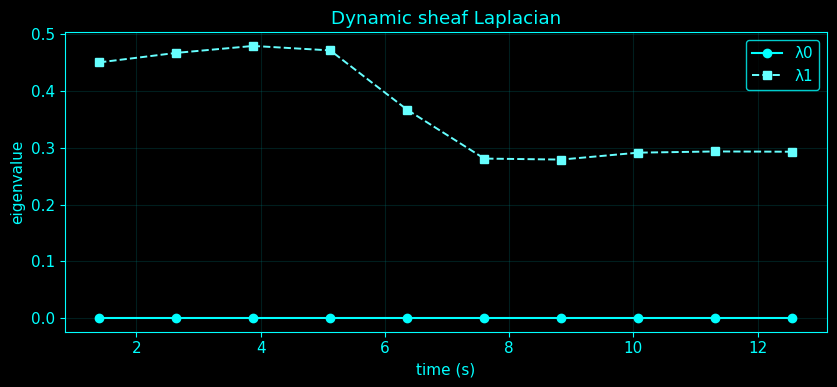

In [201]:
# Method 188: Dynamic sheaf Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_188():

    i = 188
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    rows = []
    nw = min(_TOPO_SPEED['windows'], 10)
    for st, en, _ in _windows(_topo_pc1, nw):
        X = _topo_x[st:en, :n]
        F = (np.std(X, axis=0) / (np.mean(np.std(X, axis=0)) + TOPO_EPS))[:, None]
        D = _sheaf_delta(edges, F)
        L, _, _ = _sheaf_stats(D)
        ev = np.linalg.eigvalsh(L)
        rows.append([(st + en) / (2 * _topo_fs), float(ev[0]), float(ev[1] if len(ev) > 1 else np.nan)])
    out = pd.DataFrame(rows, columns=['time_s', 'lambda0', 'lambda1'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.0), facecolor=TOPO_BG)
    ax.plot(out['time_s'], out['lambda0'], color=TOPO_ACCENT, marker='o', linewidth=1.5, label='λ0')
    ax.plot(out['time_s'], out['lambda1'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='λ1')
    ax.set_title('Dynamic sheaf Laplacian')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('eigenvalue')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_188()
del _topology_method_188


### 189. Frequency-band sheaf

A frequency-band sheaf derives scalar restrictions from channel variability after band-specific feature extraction. Separate sheaf cohomology and Laplacian spectra are then computed for each canonical frequency band.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,band,H0,H1,lambda1
0,delta,1,5,0.354249
1,theta,1,5,0.354249
2,alpha,1,5,0.354249
3,beta,1,5,0.354249
4,gamma,1,5,0.354249


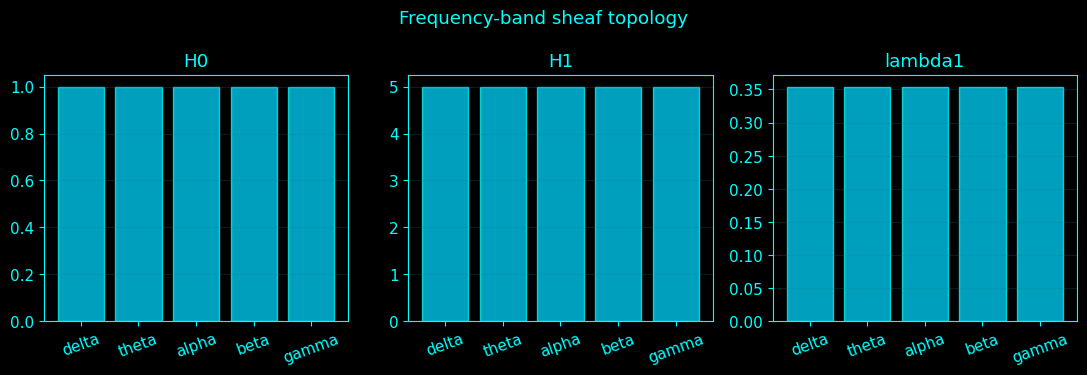

In [202]:
# Method 189: Frequency-band sheaf

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_189():

    i = 189
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    rows = []
    for bn, (lo, hi) in _TOPO_BANDS.items():
        if hi >= _topo_fs / 2:
            continue
        F = _feature_matrix('scalar', n, (lo, hi))
        D = _sheaf_delta(edges, F)
        L, h0, h1 = _sheaf_stats(D)
        ev = np.linalg.eigvalsh(L)
        rows.append([bn, h0, h1, float(ev[1] if len(ev) > 1 else 0)])
    out = pd.DataFrame(rows, columns=['band', 'H0', 'H1', 'lambda1'])
    display(out)
    fig, axs = plt.subplots(1, 3, figsize=(11, 3.8), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['H0', 'H1', 'lambda1']):
        ax.bar(out['band'], out[col], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Frequency-band sheaf topology')
    plt.tight_layout()
    plt.show()
    return


_topology_method_189()
del _topology_method_189


### 190. Multimodal EEG sheaf

The multimodal sheaf uses a direct-sum stalk with several signal feature coordinates. Restriction maps are diagonal matrices built from normalized amplitude, bandpower, and phase-reliability features, so consistency must hold simultaneously across modalities.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


multi stalk_dim 3 H0 3 H1 15 consistency_energy 72.68777021750752


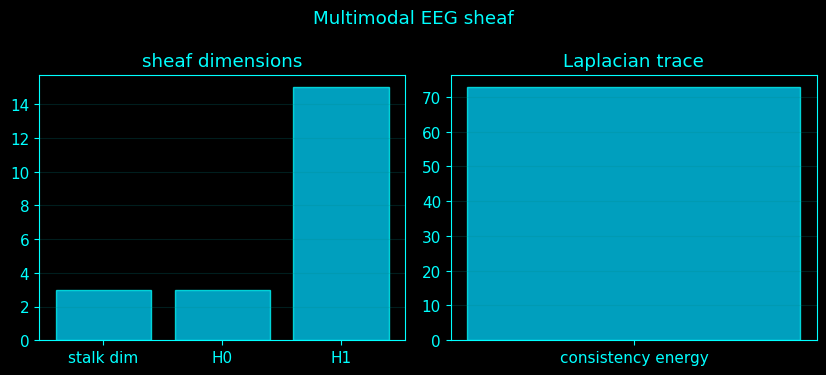

In [203]:
# Method 190: Multimodal EEG sheaf

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_190():

    i = 190
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    kind = {190: 'multi', 191: 'amp_phase', 192: 'efs'}[i]
    F = _feature_matrix(kind, n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    energy = float(np.trace(L))
    print(kind, 'stalk_dim', F.shape[1], 'H0', h0, 'H1', h1, 'consistency_energy', energy)
    fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['stalk dim', 'H0', 'H1'], [F.shape[1], h0, h1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('sheaf dimensions')
    axs[0].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    axs[1].bar(['consistency energy'], [energy], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Laplacian trace')
    axs[1].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle({'multi': 'Multimodal EEG sheaf', 'amp_phase': 'Amplitude–phase sheaf', 'efs': 'Entropy–fractal–spectral sheaf'}[kind])
    plt.tight_layout()
    plt.show()
    return


_topology_method_190()
del _topology_method_190


### 191. Amplitude-phase sheaf

The amplitude–phase sheaf uses two-dimensional stalks with separate amplitude and phase-reliability restriction factors. Its block coboundary is a genuine sheaf operator on the graph rather than a concatenated graph-feature matrix.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


amp_phase stalk_dim 2 H0 2 H1 10 consistency_energy 47.407766135352375


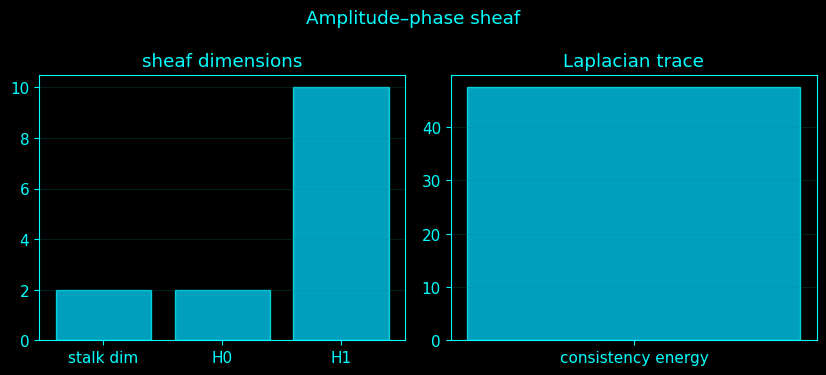

In [204]:
# Method 191: Amplitude-phase sheaf

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_191():

    i = 191
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    kind = {190: 'multi', 191: 'amp_phase', 192: 'efs'}[i]
    F = _feature_matrix(kind, n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    energy = float(np.trace(L))
    print(kind, 'stalk_dim', F.shape[1], 'H0', h0, 'H1', h1, 'consistency_energy', energy)
    fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['stalk dim', 'H0', 'H1'], [F.shape[1], h0, h1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('sheaf dimensions')
    axs[0].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    axs[1].bar(['consistency energy'], [energy], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Laplacian trace')
    axs[1].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle({'multi': 'Multimodal EEG sheaf', 'amp_phase': 'Amplitude–phase sheaf', 'efs': 'Entropy–fractal–spectral sheaf'}[kind])
    plt.tight_layout()
    plt.show()
    return


_topology_method_191()
del _topology_method_191


### 192. Entropy-fractal-spectral sheaf

The entropy–fractal–spectral sheaf uses three-dimensional stalks whose diagonal restrictions are normalized local entropy, Katz-style fractal dimension, and spectral centroid. This tests consistency of heterogeneous channel descriptors in one direct-sum sheaf.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A fractal-dimension estimator asks how the apparent geometric complexity of a signal changes with the scale at which it is measured. Higuchi's method constructs several down-sampled curves using step size k, estimates their lengths, and examines how length follows a power law with scale. The slope on a log-log plot becomes the dimension estimate. For a one-dimensional time-series graph, larger values generally correspond to a rougher, more irregular trace, but the estimate is affected by noise, record length, and the range of scales used for fitting.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


efs stalk_dim 3 H0 3 H1 15 consistency_energy 89.98758443800514


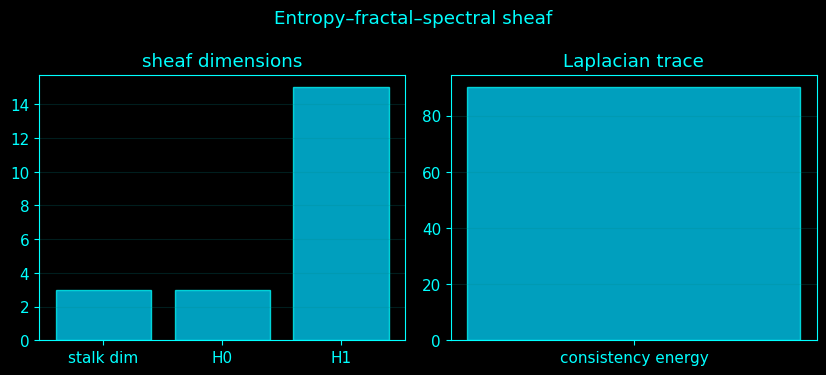

In [205]:
# Method 192: Entropy-fractal-spectral sheaf

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_192():

    i = 192
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    kind = {190: 'multi', 191: 'amp_phase', 192: 'efs'}[i]
    F = _feature_matrix(kind, n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    energy = float(np.trace(L))
    print(kind, 'stalk_dim', F.shape[1], 'H0', h0, 'H1', h1, 'consistency_energy', energy)
    fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['stalk dim', 'H0', 'H1'], [F.shape[1], h0, h1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('sheaf dimensions')
    axs[0].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    axs[1].bar(['consistency energy'], [energy], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Laplacian trace')
    axs[1].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle({'multi': 'Multimodal EEG sheaf', 'amp_phase': 'Amplitude–phase sheaf', 'efs': 'Entropy–fractal–spectral sheaf'}[kind])
    plt.tight_layout()
    plt.show()
    return


_topology_method_192()
del _topology_method_192


### 193. Cosheaf over time windows

A cellular cosheaf reverses the direction of structure maps relative to a sheaf. For the path of overlapping time windows, the notebook uses a constant rank-4 cosheaf whose boundary maps edge-window overlap data into adjacent vertex windows. Cosheaf homology is \(H_1=\ker\partial\), \(H_0=\operatorname{coker}\partial\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


time-window cosheaf H0(coker ∂)= 4 H1(ker ∂)= 0


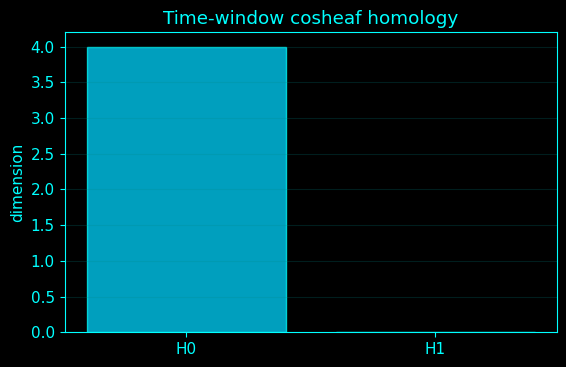

In [206]:
# Method 193: Cosheaf over time windows

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_193():

    i = 193
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _feat(dgms):
        h1=dgms[1] if len(dgms)>1 else np.empty((0,2)); L=_life(h1)
        return np.array([L.sum(), L.max() if len(L) else 0.0, _pentropy(h1), float(len(L))])

    def _simplices_rips(X,maxdim=1):
        X=np.asarray(X,float); n=len(X)
        if n<2: return [((i,),0.0,0) for i in range(n)]
        D=squareform(pdist(X))
        ss=[((i,),0.0,0) for i in range(n)]
        for i in range(n):
            for j in range(i+1,n): ss.append(((i,j),float(D[i,j]),1))
        if maxdim>=1:
            # triangles kill H1 classes; needed even if only H1 is reported
            for i in range(n):
                for j in range(i+1,n):
                    dij=D[i,j]
                    for k in range(j+1,n): ss.append(((i,j,k),float(max(dij,D[i,k],D[j,k])),2))
        # faces precede cofaces at equal filtration value
        ss.sort(key=lambda z:(z[1],z[2],z[0]))
        return ss

    def _ph_rips(X,maxdim=1):
        ss=_simplices_rips(X,maxdim=maxdim)
        index={s[0]:i for i,s in enumerate(ss)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(simp,filt,dim) in enumerate(ss):
            if dim==0: col=set()
            else:
                col={index[simp[:q]+simp[q+1:]] for q in range(len(simp))}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j
                bdim=ss[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(ss[low][1]),float(filt)))
            else: births.add(j)
        paired_births=set(low_to_col.keys())
        dgms=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired_births):
                if ss[j][2]==d: arr.append([float(ss[j][1]),np.inf])
            dgms.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2),float))
        return dgms

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    def _window_topo_features_for_cosheaf(nw=10):
        rows=[]
        for st,en,w in _windows(_topo_pc1,nw):rows.append(_feat(_ph_rips(_delay_embed(w,3,max(1,int(.01*_topo_fs))),1)))
        return np.asarray(rows,float)

    def _cosheaf_boundary_path(nw=10):
        F=_window_topo_features_for_cosheaf(nw);n,d=F.shape;B=np.zeros((n*d,max(0,n-1)*d))
        for e in range(n-1):
            B[e*d:(e+1)*d,e*d:(e+1)*d]=-np.eye(d);B[(e+1)*d:(e+2)*d,e*d:(e+1)*d]=np.eye(d)
        return B,F

    # Method mathematics and output.
    B, F = _cosheaf_boundary_path(min(_TOPO_SPEED['windows'], 10))
    rank = np.linalg.matrix_rank(B)
    h1 = B.shape[1] - rank
    h0 = B.shape[0] - rank
    print('time-window cosheaf H0(coker ∂)=', h0, 'H1(ker ∂)=', h1)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['H0', 'H1'], [h0, h1], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Time-window cosheaf homology')
    ax.set_ylabel('dimension')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return
    out = pd.DataFrame({'summary': ['windows', 'feature_dim', 'C0_dim', 'C1_dim', 'rank_boundary', 'H0', 'H1'], 'value': [len(F), F.shape[1], B.shape[0], B.shape[1], rank, h0, h1]})
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.2), facecolor=TOPO_BG)
    ax.bar(out['summary'], out['value'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Cellular cosheaf summaries')
    ax.set_ylabel('value')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_193()
del _topology_method_193


### 194. Cellular cosheaf summaries

The cellular cosheaf summary reports chain-group dimensions, boundary rank, and the resulting H0/H1 dimensions for the time-window path cosheaf.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


,summary,value
0,windows,10
1,feature_dim,4
2,C0_dim,40
3,C1_dim,36
4,rank_boundary,36
5,H0,4
6,H1,0


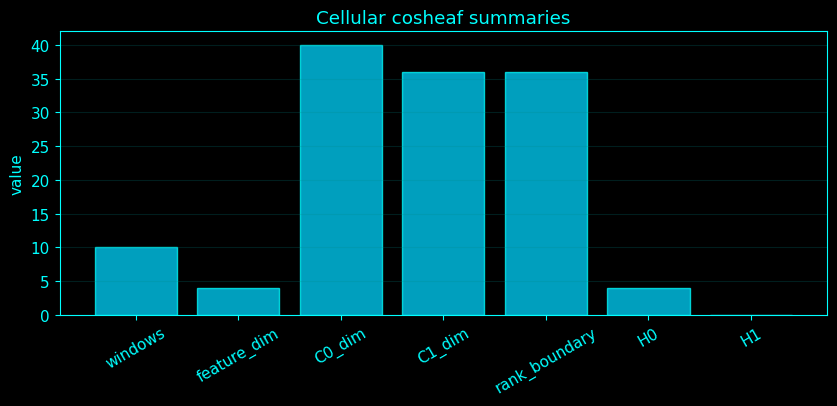

In [207]:
# Method 194: Cellular cosheaf summaries

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_194():

    i = 194
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _feat(dgms):
        h1=dgms[1] if len(dgms)>1 else np.empty((0,2)); L=_life(h1)
        return np.array([L.sum(), L.max() if len(L) else 0.0, _pentropy(h1), float(len(L))])

    def _simplices_rips(X,maxdim=1):
        X=np.asarray(X,float); n=len(X)
        if n<2: return [((i,),0.0,0) for i in range(n)]
        D=squareform(pdist(X))
        ss=[((i,),0.0,0) for i in range(n)]
        for i in range(n):
            for j in range(i+1,n): ss.append(((i,j),float(D[i,j]),1))
        if maxdim>=1:
            # triangles kill H1 classes; needed even if only H1 is reported
            for i in range(n):
                for j in range(i+1,n):
                    dij=D[i,j]
                    for k in range(j+1,n): ss.append(((i,j,k),float(max(dij,D[i,k],D[j,k])),2))
        # faces precede cofaces at equal filtration value
        ss.sort(key=lambda z:(z[1],z[2],z[0]))
        return ss

    def _ph_rips(X,maxdim=1):
        ss=_simplices_rips(X,maxdim=maxdim)
        index={s[0]:i for i,s in enumerate(ss)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(simp,filt,dim) in enumerate(ss):
            if dim==0: col=set()
            else:
                col={index[simp[:q]+simp[q+1:]] for q in range(len(simp))}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j
                bdim=ss[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(ss[low][1]),float(filt)))
            else: births.add(j)
        paired_births=set(low_to_col.keys())
        dgms=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired_births):
                if ss[j][2]==d: arr.append([float(ss[j][1]),np.inf])
            dgms.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2),float))
        return dgms

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    def _window_topo_features_for_cosheaf(nw=10):
        rows=[]
        for st,en,w in _windows(_topo_pc1,nw):rows.append(_feat(_ph_rips(_delay_embed(w,3,max(1,int(.01*_topo_fs))),1)))
        return np.asarray(rows,float)

    def _cosheaf_boundary_path(nw=10):
        F=_window_topo_features_for_cosheaf(nw);n,d=F.shape;B=np.zeros((n*d,max(0,n-1)*d))
        for e in range(n-1):
            B[e*d:(e+1)*d,e*d:(e+1)*d]=-np.eye(d);B[(e+1)*d:(e+2)*d,e*d:(e+1)*d]=np.eye(d)
        return B,F

    # Method mathematics and output.
    B, F = _cosheaf_boundary_path(min(_TOPO_SPEED['windows'], 10))
    rank = np.linalg.matrix_rank(B)
    h1 = B.shape[1] - rank
    h0 = B.shape[0] - rank
    out = pd.DataFrame({'summary': ['windows', 'feature_dim', 'C0_dim', 'C1_dim', 'rank_boundary', 'H0', 'H1'], 'value': [len(F), F.shape[1], B.shape[0], B.shape[1], rank, h0, h1]})
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.2), facecolor=TOPO_BG)
    ax.bar(out['summary'], out['value'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Cellular cosheaf summaries')
    ax.set_ylabel('value')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_194()
del _topology_method_194


### 195. Sheaf consistency analysis

Sheaf consistency of a vertex assignment x is measured by \(\|\delta x\|^2=x^TL_\mathcal Fx\). Zero energy means all incident restrictions agree exactly on every edge.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [208]:
# Method 195: Sheaf consistency analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_195():

    i = 195
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('amp_phase', n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    x = np.tile(np.mean(_topo_x[:, :n], axis=0)[:, None], (1, F.shape[1])).ravel()
    res = D @ x
    print('global sheaf consistency energy ||δx||² =', float(res @ res))
    return
    tau = 0.5 / (np.max(np.linalg.eigvalsh(L)) + TOPO_EPS)
    y = np.linalg.solve(np.eye(L.shape[0]) + tau * L, x)
    vals = [float(x @ L @ x), float(y @ L @ y)]
    print('sheaf smoothing energy before/after', vals[0], vals[1])
    fig, ax = plt.subplots(figsize=(6.2, 3.9), facecolor=TOPO_BG)
    ax.bar(['before', 'after'], vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Sheaf signal-processing smoothness energy')
    ax.set_ylabel('xᵀLx')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_195()
del _topology_method_195


global sheaf consistency energy ||δx||² = 7.463059880037454e-30


### 196. Sheaf-based anomaly detection

Sheaf anomaly scores localize the consistency residual by edge: \(a_e=\|(\delta x)_e\|^2\). Large values mark electrode pairs whose assigned feature values disagree strongly under the chosen restriction maps.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,edge,inconsistency
10,"(5, 7)",3.250493e-30
9,"(5, 6)",1.015883e-30
7,"(4, 5)",8.405102e-31
11,"(6, 7)",6.530444e-31
2,"(0, 5)",6.349890e-31
4,"(3, 4)",3.605421e-31
5,"(3, 6)",2.693263e-31
6,"(3, 7)",2.446288e-31
1,"(0, 2)",8.041715e-32
8,"(4, 6)",6.522417e-32


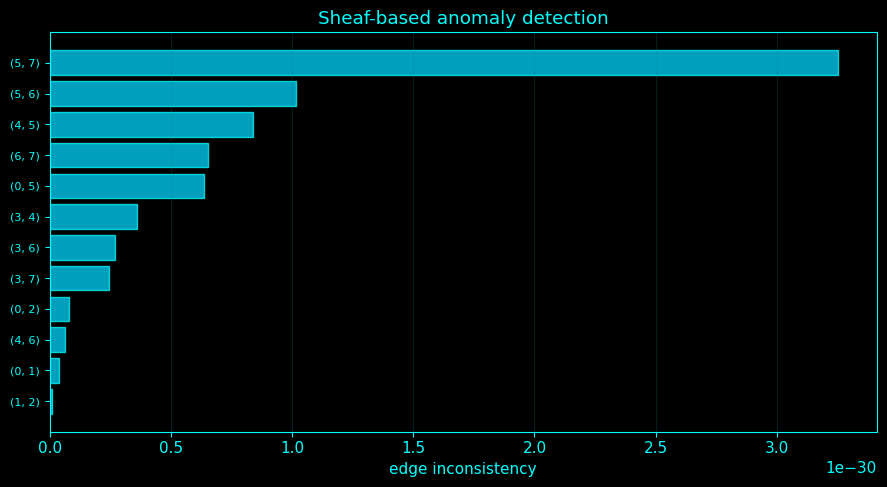

In [209]:
# Method 196: Sheaf-based anomaly detection

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_196():

    i = 196
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('amp_phase', n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    x = np.tile(np.mean(_topo_x[:, :n], axis=0)[:, None], (1, F.shape[1])).ravel()
    res = D @ x
    eE = np.array([np.sum(res[k * F.shape[1]:(k + 1) * F.shape[1]] ** 2) for k in range(len(edges))])
    out = pd.DataFrame({'edge': [str(e) for e in edges], 'inconsistency': eE}).sort_values('inconsistency', ascending=False).head(15)
    display(out)
    fig, ax = plt.subplots(figsize=(9, 5.0), facecolor=TOPO_BG)
    y = np.arange(len(out))
    ax.barh(y, out['inconsistency'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(out['edge'], fontsize=8)
    ax.invert_yaxis()
    ax.set_title('Sheaf-based anomaly detection')
    ax.set_xlabel('edge inconsistency')
    ax.grid(True, axis='x', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return
    tau = 0.5 / (np.max(np.linalg.eigvalsh(L)) + TOPO_EPS)
    y = np.linalg.solve(np.eye(L.shape[0]) + tau * L, x)
    vals = [float(x @ L @ x), float(y @ L @ y)]
    print('sheaf smoothing energy before/after', vals[0], vals[1])
    fig, ax = plt.subplots(figsize=(6.2, 3.9), facecolor=TOPO_BG)
    ax.bar(['before', 'after'], vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Sheaf signal-processing smoothness energy')
    ax.set_ylabel('xᵀLx')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_196()
del _topology_method_196


### 197. Sheaf Laplacian spectra

The sheaf Laplacian spectrum is the spectrum of \(\delta^T\delta\) for the multidimensional stalk model. Zero eigenvectors are globally consistent sections; positive eigenvalues quantify increasingly inconsistent modes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


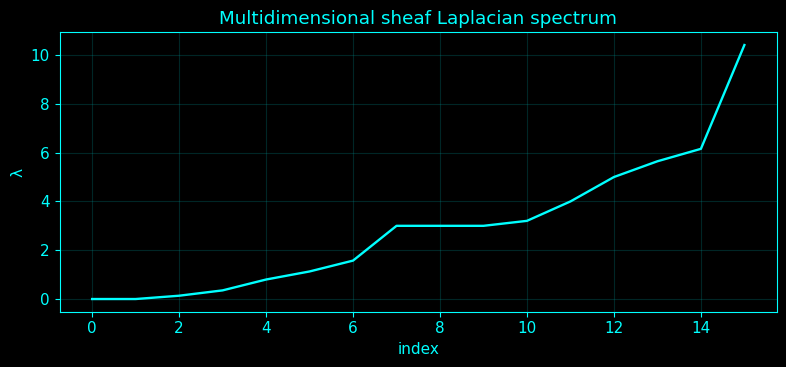

In [210]:
# Method 197: Sheaf Laplacian spectra

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_197():

    i = 197
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('amp_phase', n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    x = np.tile(np.mean(_topo_x[:, :n], axis=0)[:, None], (1, F.shape[1])).ravel()
    res = D @ x
    ev = np.linalg.eigvalsh(L)
    _plot_line(np.arange(len(ev)), ev, 'Multidimensional sheaf Laplacian spectrum', 'index', 'λ')
    return
    tau = 0.5 / (np.max(np.linalg.eigvalsh(L)) + TOPO_EPS)
    y = np.linalg.solve(np.eye(L.shape[0]) + tau * L, x)
    vals = [float(x @ L @ x), float(y @ L @ y)]
    print('sheaf smoothing energy before/after', vals[0], vals[1])
    fig, ax = plt.subplots(figsize=(6.2, 3.9), facecolor=TOPO_BG)
    ax.bar(['before', 'after'], vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Sheaf signal-processing smoothness energy')
    ax.set_ylabel('xᵀLx')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_197()
del _topology_method_197


### 198. Sheaf signal processing

Sheaf signal processing smooths a vertex-stalk signal using Tikhonov/implicit heat regularization \(y=(I+\tau L_\mathcal F)^{-1}x\). This decreases sheaf Dirichlet energy while respecting the restriction-map geometry.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


sheaf smoothing energy before/after 7.463059880037455e-30 5.1444421009213475e-30


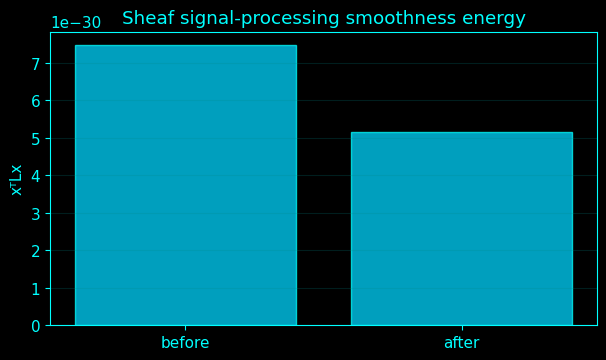

In [211]:
# Method 198: Sheaf signal processing

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_198():

    i = 198
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _feature_matrix(kind='scalar',nch=None,band=(8,13)):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        X=_topo_x[:,:nch]
        amp=np.std(X,axis=0)+1e-6
        lo,hi=band;hi=min(hi,_topo_fs/2-.5);lo=min(lo,max(.5,hi-1));bp=_bandpower_values(X,lo,hi)+1e-6 if hi>lo else amp.copy()
        if kind=='scalar':return (amp/np.mean(amp))[:,None]
        ph=np.angle(np.mean(np.exp(1j*np.angle(signal.hilbert(np.column_stack([_filter_band(X[:,j],lo,hi) for j in range(nch)]) if hi>lo else X,axis=0))),axis=0));phase_rel=1+.5*np.cos(ph)
        if kind=='amp_phase':return np.column_stack([amp/np.mean(amp),phase_rel])
        ent=[];fd=[];cent=[]
        for j in range(nch):
            h,_=np.histogram(X[:,j],bins=16);p=h/(h.sum()+TOPO_EPS);ent.append(-np.sum(p[p>0]*np.log(p[p>0])))
            y=X[:,j];L=np.sum(np.abs(np.diff(y)));dd=np.max(np.abs(y-y[0]));N=len(y);fd.append(np.log10(N)/(np.log10(N)+np.log10((dd+TOPO_EPS)/(L+TOPO_EPS))))
            f,P=signal.welch(y,fs=_topo_fs,nperseg=min(256,len(y)));cent.append(np.sum(f*P)/(np.sum(P)+TOPO_EPS))
        if kind=='efs':
            M=np.column_stack([ent,fd,cent]);return M/(np.mean(np.abs(M),axis=0,keepdims=True)+TOPO_EPS)
        return np.column_stack([amp/np.mean(amp),bp/np.mean(bp),phase_rel])

    def _sheaf_delta(edges,features):
        # Direct-sum rank-d vertex/edge stalks; restriction F_{v->e}=diag(feature_v).
        F=np.asarray(features,float);n,d=F.shape;m=len(edges);D=np.zeros((m*d,n*d),float)
        for e,(u,v) in enumerate(edges):
            Ru=np.diag(F[u]);Rv=np.diag(F[v]);D[e*d:(e+1)*d,u*d:(u+1)*d]=-Ru;D[e*d:(e+1)*d,v*d:(v+1)*d]=Rv
        return D

    def _sheaf_graph(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        S=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));vals=S[np.triu_indices(nch,1)];cut=np.quantile(vals,.62);edges=[(i,j) for i in range(nch) for j in range(i+1,nch) if S[i,j]>=cut]
        # guarantee connected support by adding max-similarity spanning tree
        G=nx.Graph();G.add_nodes_from(range(nch));
        for i in range(nch):
            for j in range(i+1,nch):G.add_edge(i,j,weight=1-S[i,j])
        edges=sorted(set(edges)|{tuple(sorted(e)) for e in nx.minimum_spanning_tree(G).edges()});return S,edges

    def _sheaf_stats(D):
        L=D.T@D;rank=np.linalg.matrix_rank(D,tol=1e-9);h0=D.shape[1]-rank;h1=D.shape[0]-rank;return L,int(h0),int(h1)

    # Method mathematics and output.
    S, edges = _sheaf_graph()
    n = len(S)
    F = _feature_matrix('amp_phase', n)
    D = _sheaf_delta(edges, F)
    L, h0, h1 = _sheaf_stats(D)
    x = np.tile(np.mean(_topo_x[:, :n], axis=0)[:, None], (1, F.shape[1])).ravel()
    res = D @ x
    tau = 0.5 / (np.max(np.linalg.eigvalsh(L)) + TOPO_EPS)
    y = np.linalg.solve(np.eye(L.shape[0]) + tau * L, x)
    vals = [float(x @ L @ x), float(y @ L @ y)]
    print('sheaf smoothing energy before/after', vals[0], vals[1])
    fig, ax = plt.subplots(figsize=(6.2, 3.9), facecolor=TOPO_BG)
    ax.bar(['before', 'after'], vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Sheaf signal-processing smoothness energy')
    ax.set_ylabel('xᵀLx')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_198()
del _topology_method_198


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — nerve and multiparameter helpers for topology methods 199–223</h3>
<p>This block constructs nerve complexes and finite two-parameter filtrations. For nested bifiltrations \(K_{a,b}\subseteq K_{a',b'}\) whenever \(a\le a', b\le b'\), induced homology-map ranks form a rank invariant; one-parameter slices give fibered barcodes. Axes lacking inclusion maps are explicitly treated as parameter families rather than being falsely advertised as persistence modules.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [212]:
# =======================================================
# TOPOLOGY CATALOGUE — methods 199–223
# Shared mathematical helpers removed; each method cell is self-contained.
# =======================================================


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — topology methods 199–223</h3>
<p>This dispatcher applies the requested nerve, rank-invariant, fibered-barcode, or multiparameter-family calculation to the common EEG-derived filtration data. It contains selection logic only.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


### 199. Nerve complex analysis

Given a cover \(\mathcal U=\{U_i\}\), its nerve contains a simplex \([i_0\ldots i_k]\) exactly when \(U_{i_0}\cap\cdots\cap U_{i_k}\neq\varnothing\). The cell constructs the nerve of overlapping Euclidean-ball cover sets and computes H0/H1 of that finite simplicial complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


nerve Betti (1, 0) cover sets 9 radius 1.3478044539068543


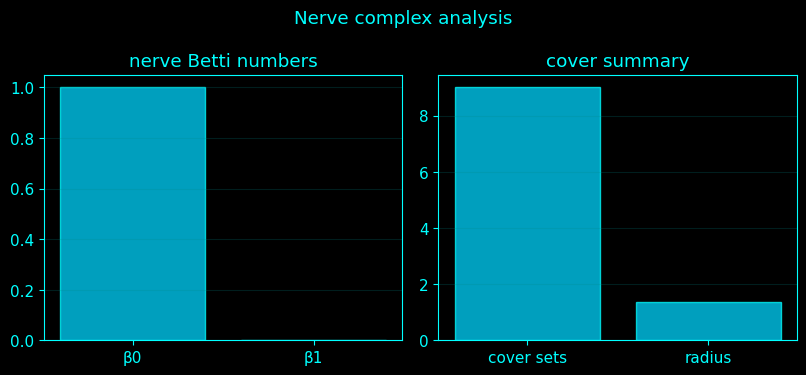

In [213]:
# Method 199: Nerve complex analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_199():

    i = 199
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    bet = _simplicial_betti_01(simp)
    print('nerve Betti', bet, 'cover sets', len(sets), 'radius', rr)
    fig, axs = plt.subplots(1, 2, figsize=(8.2, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('nerve Betti numbers')
    axs[0].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    axs[1].bar(['cover sets', 'radius'], [len(sets), rr], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('cover summary')
    axs[1].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Nerve complex analysis')
    plt.tight_layout()
    plt.show()
    return


_topology_method_199()
del _topology_method_199


### 200. Good-cover validation

A good cover is one in which every nonempty finite intersection is contractible. Euclidean balls are convex, and every nonempty finite intersection of convex sets is convex and therefore contractible; thus a ball cover is a good cover independently of the sampled data points used to record which intersections are nonempty.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [214]:
# Method 200: Good-cover validation

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_200():

    i = 200
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    print('Euclidean-ball cover is a good cover whenever all sets/intersections are nonempty because balls and their finite intersections are convex; nonempty intersections=', sum((1 for r in range(1, 4) for c in combinations(range(len(sets)), r) if set.intersection(*(sets[j] for j in c)))))
    return


_topology_method_200()
del _topology_method_200


Euclidean-ball cover is a good cover whenever all sets/intersections are nonempty because balls and their finite intersections are convex; nonempty intersections= 31


### 201. Nerve theorem diagnostics

The nerve theorem states that the nerve of a good open cover is homotopy equivalent to the union of its sets. The notebook checks the good-cover condition analytically for balls and compares nerve Betti numbers with a Rips complex only as a numerical diagnostic; a Rips complex is not itself the union of balls.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


nerve Betti (1, 0) Rips-at-comparable-scale Betti (0, 0) (diagnostic only; Rips is not the union of balls)


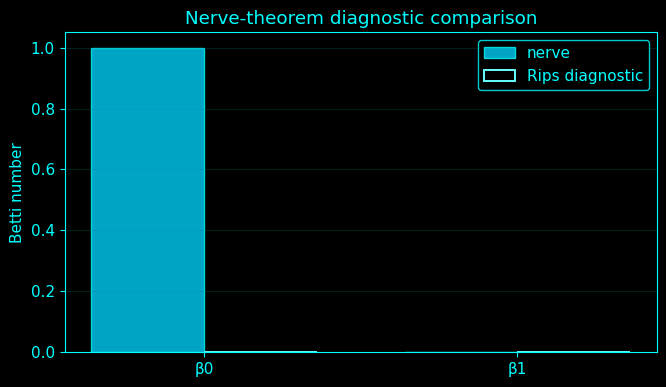

In [215]:
# Method 201: Nerve theorem diagnostics

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_201():

    i = 201
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _simplices_rips(X,maxdim=1):
        X=np.asarray(X,float); n=len(X)
        if n<2: return [((i,),0.0,0) for i in range(n)]
        D=squareform(pdist(X))
        ss=[((i,),0.0,0) for i in range(n)]
        for i in range(n):
            for j in range(i+1,n): ss.append(((i,j),float(D[i,j]),1))
        if maxdim>=1:
            # triangles kill H1 classes; needed even if only H1 is reported
            for i in range(n):
                for j in range(i+1,n):
                    dij=D[i,j]
                    for k in range(j+1,n): ss.append(((i,j,k),float(max(dij,D[i,k],D[j,k])),2))
        # faces precede cofaces at equal filtration value
        ss.sort(key=lambda z:(z[1],z[2],z[0]))
        return ss

    def _ph_rips(X,maxdim=1):
        ss=_simplices_rips(X,maxdim=maxdim)
        index={s[0]:i for i,s in enumerate(ss)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(simp,filt,dim) in enumerate(ss):
            if dim==0: col=set()
            else:
                col={index[simp[:q]+simp[q+1:]] for q in range(len(simp))}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j
                bdim=ss[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(ss[low][1]),float(filt)))
            else: births.add(j)
        paired_births=set(low_to_col.keys())
        dgms=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired_births):
                if ss[j][2]==d: arr.append([float(ss[j][1]),np.inf])
            dgms.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2),float))
        return dgms

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    bN = _simplicial_betti_01(simp)
    dg = _ph_rips(X, 1)
    eps = rr * 2
    bettiR = (int(np.sum((_finite(dg[0])[:, 0] <= eps) & (eps < _finite(dg[0])[:, 1]))) if len(_finite(dg[0])) else 0, int(np.sum((_finite(dg[1])[:, 0] <= eps) & (eps < _finite(dg[1])[:, 1]))) if len(_finite(dg[1])) else 0)
    print('nerve Betti', bN, 'Rips-at-comparable-scale Betti', bettiR, '(diagnostic only; Rips is not the union of balls)')
    x = np.arange(2)
    w = 0.36
    fig, ax = plt.subplots(figsize=(6.8, 4.0), facecolor=TOPO_BG)
    ax.bar(x - w / 2, bN, width=w, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.78, label='nerve')
    ax.bar(x + w / 2, bettiR, width=w, color=TOPO_BG, edgecolor=TOPO_CYAN_SOFT, linewidth=1.4, label='Rips diagnostic')
    ax.set_xticks(x)
    ax.set_xticklabels(['β0', 'β1'])
    ax.set_title('Nerve-theorem diagnostic comparison')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_201()
del _topology_method_201


### 202. Cover-based topology

Cover-based topology analyzes the nerve rather than the raw point cloud. The homology therefore depends on how cover elements overlap, making cover design an explicit part of the model.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


cover-based nerve Betti (1, 0)


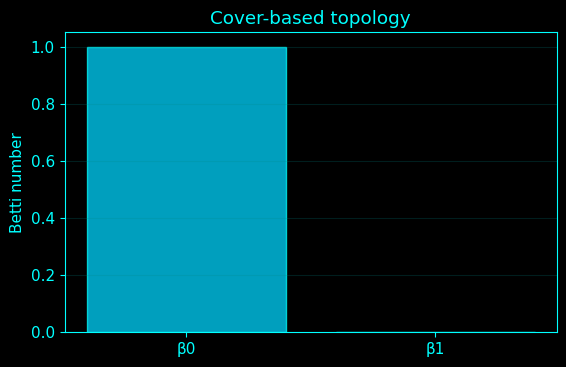

In [216]:
# Method 202: Cover-based topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_202():

    i = 202
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    bet = _simplicial_betti_01(simp)
    print('cover-based nerve Betti', bet)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Cover-based topology')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_202()
del _topology_method_202


### 203. Čech nerve topology

The Čech complex is precisely the nerve of equal-radius metric balls centered on data sites. This cell constructs the corresponding finite intersection nerve for the selected ball cover.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Čech nerve of Euclidean-ball cover Betti (1, 0)


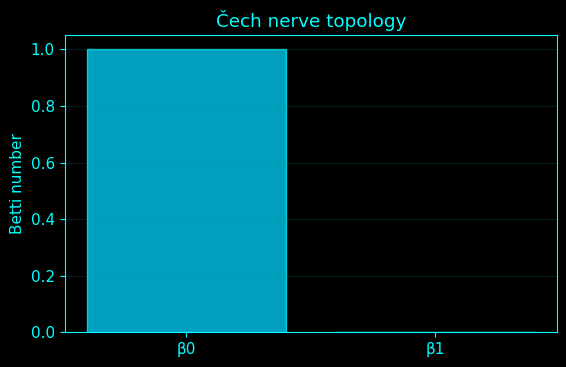

In [217]:
# Method 203: Čech nerve topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_203():

    i = 203
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    bet = _simplicial_betti_01(simp)
    print('Čech nerve of Euclidean-ball cover Betti', bet)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Čech nerve topology')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_203()
del _topology_method_203


### 204. Region-cover topology

Region-cover topology treats overlapping anatomical electrode groups as cover elements and computes the homology of their nerve. Because left/right/midline and anterior–posterior groups overlap, the nerve encodes relationships among regional descriptions.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


region-cover nerve Betti (1, 2)


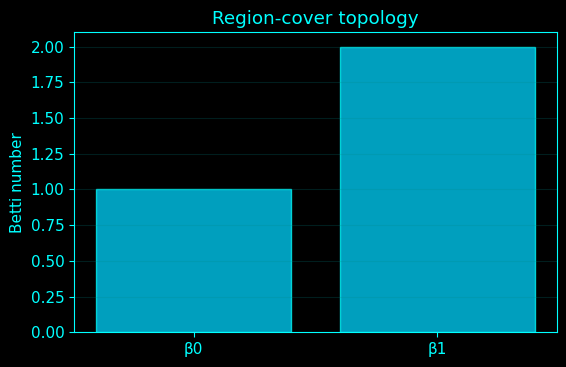

In [218]:
# Method 204: Region-cover topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_204():

    i = 204
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    names = _topo_names
    regions = [set((j for j, nm in enumerate(names) if nm.startswith(('Fp', 'F', 'FC')))), set((j for j, nm in enumerate(names) if nm.startswith(('FC', 'C', 'CP')))), set((j for j, nm in enumerate(names) if nm.startswith(('CP', 'P', 'PO', 'O')))), set((j for j, nm in enumerate(names) if nm.endswith(('1', '3', '5', '7')))), set((j for j, nm in enumerate(names) if nm.endswith(('2', '4', '6', '8')))), set((j for j, nm in enumerate(names) if nm.endswith('z')))]
    bet = _simplicial_betti_01(_nerve_complex(regions, 2))
    print('region-cover nerve Betti', bet)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Region-cover topology')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_204()
del _topology_method_204


### 205. Electrode-neighborhood nerve topology

Each electrode defines a cover element consisting of itself and its nearest scalp neighbours. The nerve records higher-order overlaps of these local electrode neighborhoods.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


electrode-neighborhood nerve Betti (1, 0)


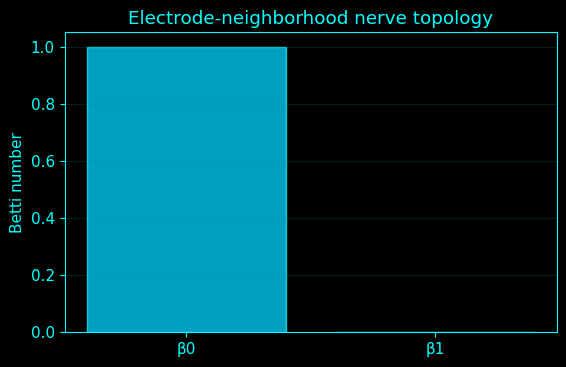

In [219]:
# Method 205: Electrode-neighborhood nerve topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_205():

    i = 205
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    pts = _scalp_coords(len(_topo_names))
    D = squareform(pdist(pts))
    cov = [set(np.argsort(D[j])[:5]) for j in range(len(pts))]
    bet = _simplicial_betti_01(_nerve_complex(cov, 2))
    print('electrode-neighborhood nerve Betti', bet)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Electrode-neighborhood nerve topology')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_205()
del _topology_method_205


### 206. Band-cover nerve topology

Band-cover topology uses overlapping frequency intervals as cover elements on a discretized frequency axis. The nerve captures which spectral bands overlap pairwise and in higher intersections.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


band-cover nerve Betti (1, 0)


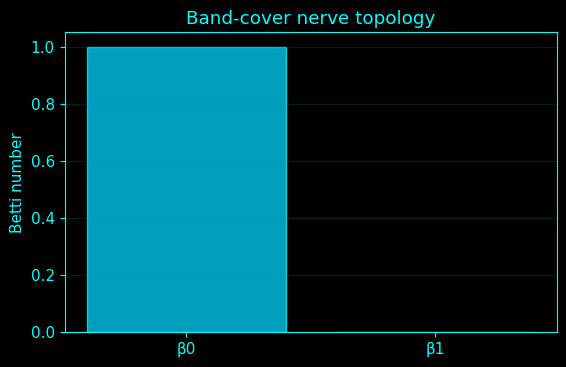

In [220]:
# Method 206: Band-cover nerve topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_206():

    i = 206
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    freq = np.linspace(1, 45, 89)
    bands = [(1, 6), (4, 10), (8, 15), (12, 25), (20, 35), (30, 45)]
    cov = [set(np.where((freq >= a) & (freq <= b))[0]) for a, b in bands]
    bet = _simplicial_betti_01(_nerve_complex(cov, 2))
    print('band-cover nerve Betti', bet)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Band-cover nerve topology')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_206()
del _topology_method_206


### 207. Time-window nerve topology

Time-window nerve topology uses overlapping temporal windows as cover elements. For ordinary sliding intervals on a line, the nerve should be contractible when the union is one connected interval, providing a useful sanity check.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


overlapping time-window nerve Betti (1, 0)


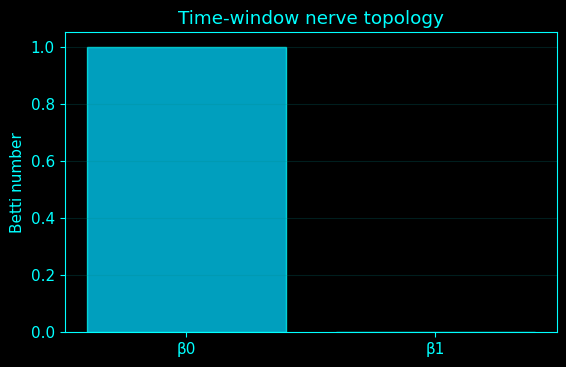

In [221]:
# Method 207: Time-window nerve topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_207():

    i = 207
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ball_cover_sets(X,ncent=8,radius_q=.25):
        X=np.asarray(X,float);ncent=min(ncent,len(X));ci=np.linspace(0,len(X)-1,ncent).astype(int);D=cdist(X[ci],X);rr=np.quantile(D[D>0],radius_q) if np.any(D>0) else 1.;sets=[set(np.where(D[k]<=rr)[0]) for k in range(ncent)];return sets,ci,float(rr)

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _nerve_complex(sets,maxdim=2):
        sets=[set(s) for s in sets];simp={0:[(i,) for i in range(len(sets))]}
        for d in range(1,maxdim+1):
            out=[]
            for c in combinations(range(len(sets)),d+1):
                inter=set.intersection(*(sets[j] for j in c)) if c else set()
                if inter:out.append(tuple(c))
            simp[d]=out
        return simp

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(90, _TOPO_MAPPER_POINTS))
    sets, ci, rr = _ball_cover_sets(X, min(9, len(X)), 0.22)
    simp = _nerve_complex(sets, 2)
    n = 100
    starts = np.arange(0, 80, 10)
    cov = [set(range(s, min(n, s + 30))) for s in starts]
    bet = _simplicial_betti_01(_nerve_complex(cov, 2))
    print('overlapping time-window nerve Betti', bet)
    fig, ax = plt.subplots(figsize=(5.8, 3.8), facecolor=TOPO_BG)
    ax.bar(['β0', 'β1'], bet, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Time-window nerve topology')
    ax.set_ylabel('Betti number')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_207()
del _topology_method_207


### 208. Time × filtration multiparameter persistence

Time windows are not nested by inclusion, so “time × filtration” is generally a **two-parameter family**, not a persistence module in the time direction. The cell therefore displays \(\beta_1(t,\epsilon)\) without asserting inter-window inclusion maps.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


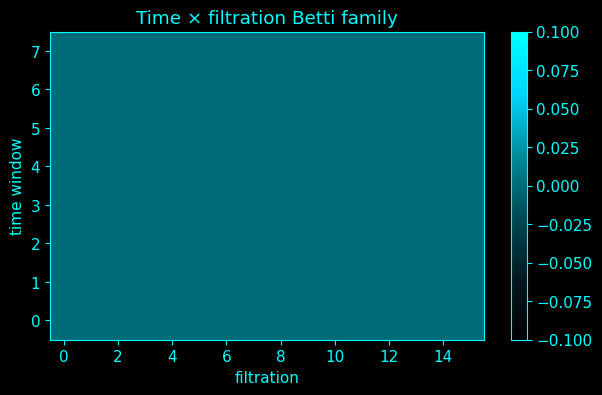

In [222]:
# Method 208: Time × filtration multiparameter persistence

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_208():

    i = 208
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    rows = []
    for wi, (st, en, _) in enumerate(_windows(_topo_pc1, min(_TOPO_SPEED['windows'], 8))):
        R = np.abs(np.corrcoef(_topo_x[st:en, :n].T))
        D = 1 - R
        grid = np.linspace(0, 1, 16)
        for e in grid:
            rows.append([wi, e, _simplicial_betti_01(_flag_complex_from_edge_subset(n, [(a, b) for a in range(n) for b in range(a + 1, n) if D[a, b] <= e], 2))[1]])
    df = pd.DataFrame(rows, columns=['time_window', 'filtration', 'beta1'])
    _imshow(df.pivot(index='time_window', columns='filtration', values='beta1').values, 'Time × filtration Betti family', 'filtration', 'time window')
    return


_topology_method_208()
del _topology_method_208


### 209. Frequency × filtration multiparameter persistence

To obtain a monotone frequency direction, the notebook uses nested cumulative bands \([1,f_{max}]\). Increasing \(f_{max}\) enlarges the spectral content used to build the network, while the second parameter is the graph filtration threshold.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


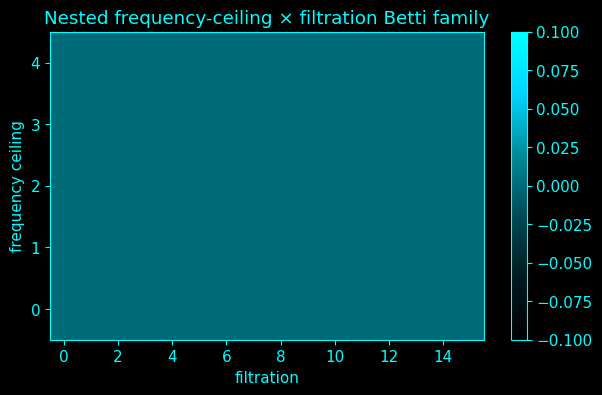

In [223]:
# Method 209: Frequency × filtration multiparameter persistence

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_209():

    i = 209
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    ceilings = [8, 13, 20, 30, 45]
    M = []
    for hi in ceilings:
        hi = min(hi, _topo_fs / 2 - 0.5)
        Y = np.column_stack([_filter_band(_topo_x[:, j], 1, hi) for j in range(n)])
        R = np.abs(np.corrcoef(Y.T))
        D = 1 - R
        row = []
        for e in np.linspace(0, 1, 16):
            row.append(_simplicial_betti_01(_flag_complex_from_edge_subset(n, [(a, b) for a in range(n) for b in range(a + 1, n) if D[a, b] <= e], 2))[1])
        M.append(row)
    _imshow(np.asarray(M), 'Nested frequency-ceiling × filtration Betti family', 'filtration', 'frequency ceiling')
    return


_topology_method_209()
del _topology_method_209


### 210. Density × distance bifiltration

The density–distance bifiltration assigns each delay-cloud point a kNN-radius density grade and includes points with grade \(\le a\); edges are then included when distance \(\le b\). Both parameters are monotone, producing a genuine finite bifiltration and a Betti surface \(\beta_1(a,b)\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


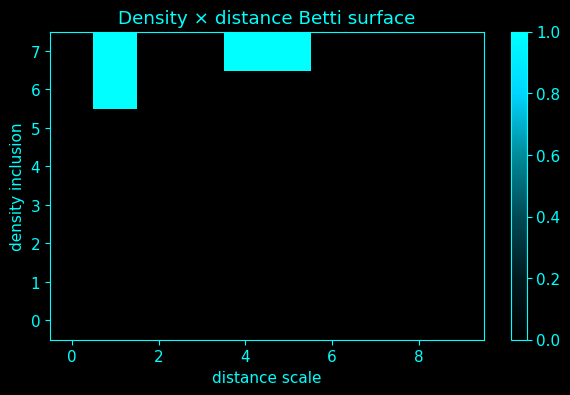

In [224]:
# Method 210: Density × distance bifiltration

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_210():

    i = 210
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method-local derived quantities required by this method.
    _TOPO_XREF = _delay_embed(
        _topo_pc1,
        m=3,
        tau=max(1, int(round(0.01 * _topo_fs))),
    )

    # Method mathematics and output.
    X = _TOPO_XREF
    D = squareform(pdist(X))
    k = min(5, len(X) - 1)
    dens = np.sort(D, axis=1)[:, k]
    aa = np.quantile(dens, np.linspace(0.2, 1, 8))
    bb = np.quantile(D[D > 0], np.linspace(0.1, 0.8, 10))
    M = np.zeros((len(aa), len(bb)), int)
    for u, a in enumerate(aa):
        ids = np.where(dens <= a)[0]
        for v, b in enumerate(bb):
            if len(ids) < 3:
                continue
            DD = D[np.ix_(ids, ids)]
            M[u, v] = _simplicial_betti_01(_flag_complex_from_edge_subset(len(ids), [(x, y) for x in range(len(ids)) for y in range(x + 1, len(ids)) if DD[x, y] <= b], 2))[1]
    _imshow(M, 'Density × distance Betti surface', 'distance scale', 'density inclusion')
    return


_topology_method_210()
del _topology_method_210


### 211. Amplitude threshold × spatial scale bifiltration

For scalp points, decreasing an amplitude cutoff includes more high-alpha electrodes while increasing spatial scale adds edges. The implementation orders the amplitude axis by inclusion and computes the flag-complex \(\beta_1\) surface over amplitude and spatial scale.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


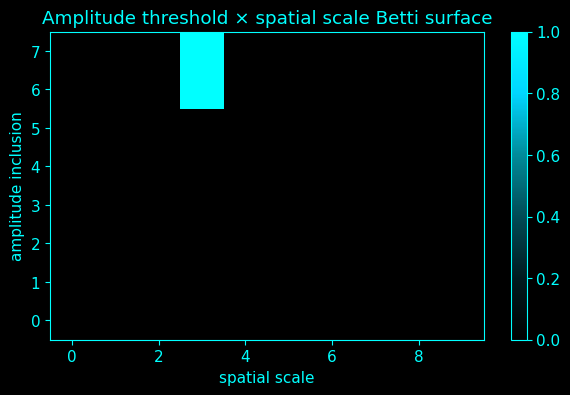

In [225]:
# Method 211: Amplitude threshold × spatial scale bifiltration

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_211():

    i = 211
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    amp = _TOPO_ALPHA_BP[:n]
    pts = _scalp_coords(n)
    D = squareform(pdist(pts))
    aq = np.quantile(amp, np.linspace(0.8, 0.2, 8))
    rq = np.linspace(0.25, 1.0, 10)
    M = np.zeros((len(aq), len(rq)), int)
    for u, a in enumerate(aq):
        ids = np.where(amp >= a)[0]
        for v, r in enumerate(rq):
            if len(ids) < 3:
                continue
            DD = D[np.ix_(ids, ids)]
            M[u, v] = _simplicial_betti_01(_flag_complex_from_edge_subset(len(ids), [(x, y) for x in range(len(ids)) for y in range(x + 1, len(ids)) if DD[x, y] <= r], 2))[1]
    _imshow(M, 'Amplitude threshold × spatial scale Betti surface', 'spatial scale', 'amplitude inclusion')
    return


_topology_method_211()
del _topology_method_211


### 212. Correlation threshold × frequency band bifiltration

The frequency coordinate uses nested cumulative bands rather than disjoint canonical bands so inclusion is meaningful. For each frequency ceiling, increasing the correlation-edge parameter gives a monotone graph filtration.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


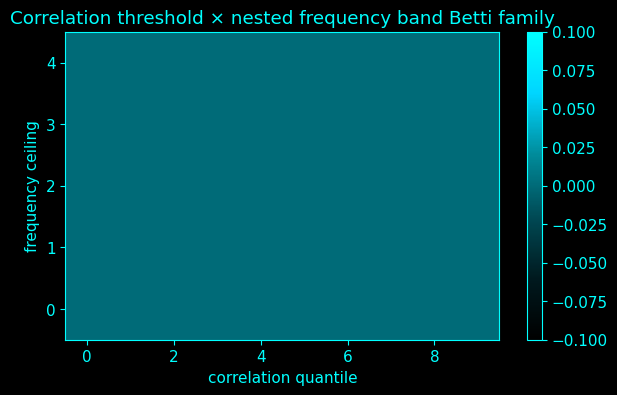

In [226]:
# Method 212: Correlation threshold × frequency band bifiltration

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_212():

    i = 212
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    ceilings = [8, 13, 20, 30, 45]
    M = []
    for hi in ceilings:
        hi = min(hi, _topo_fs / 2 - 0.5)
        Y = np.column_stack([_filter_band(_topo_x[:, j], 1, hi) for j in range(n)])
        R = np.abs(np.corrcoef(Y.T))
        row = []
        for q in np.linspace(0.3, 0.9, 10):
            th = np.quantile(R[np.triu_indices(n, 1)], q)
            row.append(_simplicial_betti_01(_flag_complex_from_edge_subset(n, [(a, b) for a in range(n) for b in range(a + 1, n) if R[a, b] >= th], 2))[1])
        M.append(row)
    _imshow(np.asarray(M), 'Correlation threshold × nested frequency band Betti family', 'correlation quantile', 'frequency ceiling')
    return


_topology_method_212()
del _topology_method_212


### 213. Delay τ × filtration bifiltration

Delay values produce different reconstructed point clouds with no canonical inclusion \(X_\tau\hookrightarrow X_{\tau'}\). Consequently this cell is a two-parameter **delay–filtration Betti family**, not a genuine bifiltration module in \(\tau\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


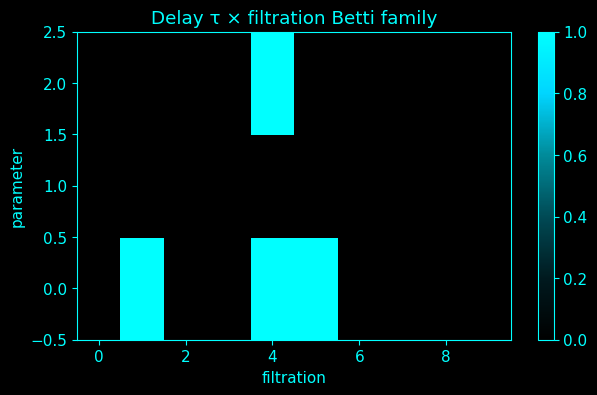

In [227]:
# Method 213: Delay τ × filtration bifiltration

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_213():

    i = 213
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    pars = np.unique(np.maximum(1, (np.linspace(0.003, 0.025, 7) * _topo_fs).astype(int))) if i == 213 else np.arange(2, min(9, _TOPO_SPEED['emb_max'] + 2))
    M = []
    for p in pars:
        X = _delay_embed(_topo_pc1, 3, int(p)) if i == 213 else _delay_embed(_topo_pc1, int(p), max(1, int(0.01 * _topo_fs)))
        D = squareform(pdist(X))
        row = []
        for e in np.quantile(D[D > 0], np.linspace(0.1, 0.8, 10)):
            row.append(_simplicial_betti_01(_flag_complex_from_edge_subset(len(X), [(a, b) for a in range(len(X)) for b in range(a + 1, len(X)) if D[a, b] <= e], 2))[1])
        M.append(row)
    _imshow(np.asarray(M), ('Delay τ' if i == 213 else 'Embedding dimension') + ' × filtration Betti family', 'filtration', 'parameter')
    return


_topology_method_213()
del _topology_method_213


### 214. Embedding dimension × filtration bifiltration

Embedding dimensions are related by coordinate projection rather than set inclusion. The cell therefore reports an embedding-dimension × filtration Betti family and explicitly avoids calling the dimension axis a strict filtration.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Delay embedding turns one measured time series into a sequence of state-space vectors by combining the present sample with delayed copies of the same signal. The idea is that the hidden state of a dynamical system can sometimes be reconstructed from a single observable when enough delayed coordinates are used. The delay controls how far apart in time the coordinates are, while the embedding dimension controls how many delayed coordinates are included. Too small a delay makes coordinates nearly redundant; too large a delay can make them weakly related. Too small an embedding dimension can fold distinct states onto one another.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


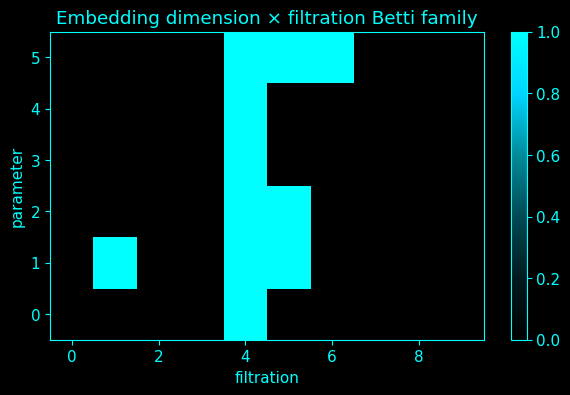

In [228]:
# Method 214: Embedding dimension × filtration bifiltration

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_214():

    i = 214
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    pars = np.unique(np.maximum(1, (np.linspace(0.003, 0.025, 7) * _topo_fs).astype(int))) if i == 213 else np.arange(2, min(9, _TOPO_SPEED['emb_max'] + 2))
    M = []
    for p in pars:
        X = _delay_embed(_topo_pc1, 3, int(p)) if i == 213 else _delay_embed(_topo_pc1, int(p), max(1, int(0.01 * _topo_fs)))
        D = squareform(pdist(X))
        row = []
        for e in np.quantile(D[D > 0], np.linspace(0.1, 0.8, 10)):
            row.append(_simplicial_betti_01(_flag_complex_from_edge_subset(len(X), [(a, b) for a in range(len(X)) for b in range(a + 1, len(X)) if D[a, b] <= e], 2))[1])
        M.append(row)
    _imshow(np.asarray(M), ('Delay τ' if i == 213 else 'Embedding dimension') + ' × filtration Betti family', 'filtration', 'parameter')
    return


_topology_method_214()
del _topology_method_214


### 215. Rank invariant summaries

For grades \(p\le q\) in the channel bifiltration, the rank invariant is \(\rho_1(p,q)=\operatorname{rank}[H_1(K_p)\to H_1(K_q)]\). The induced-map rank is computed algebraically by embedding cycles of \(K_p\) into the edge space of \(K_q\) and quotienting by boundaries of \(K_q\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


,lower_grade,upper_grade,rank_H1_map
0,"(0.35, 0.35)","(0.7, 0.7)",0
1,"(0.4, 0.5)","(0.8, 0.8)",0
2,"(0.55, 0.35)","(0.9, 0.65)",0


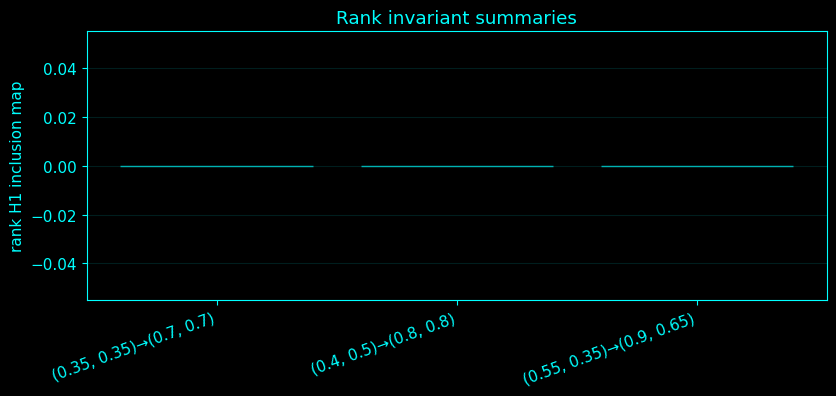

In [229]:
# Method 215: Rank invariant summaries

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_215():

    i = 215
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _bifilt_complex(a,b,n,edges,grades):
        ee=[e for e in edges if grades[e][0]<=a and grades[e][1]<=b];return _flag_complex_from_edge_subset(n,ee,2)

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _h1_inclusion_rank(small,large):
        B1s=_boundary_matrix(small[0],small.get(1,[]));B2s=_boundary_matrix(small.get(1,[]),small.get(2,[]));Z=_gf2_nullspace(np.rint(B1s).astype(np.uint8)%2)
        B2L=_boundary_matrix(large.get(1,[]),large.get(2,[]));Im=np.rint(B2L).astype(np.uint8)%2; el={e:i for i,e in enumerate(large.get(1,[]))};E=np.zeros((len(el),Z.shape[1]),dtype=np.uint8)
        es={e:i for i,e in enumerate(small.get(1,[]))}
        for e,si in es.items():
            if e in el:E[el[e],:]=Z[si,:]
        return _gf2_rank(np.column_stack([Im,E]))-_gf2_rank(Im) if E.shape[1] else 0

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    pairs = [((0.35, 0.35), (0.7, 0.7)), ((0.4, 0.5), (0.8, 0.8)), ((0.55, 0.35), (0.9, 0.65))]
    rows = []
    for p, q in pairs:
        rows.append([p, q, _h1_inclusion_rank(_bifilt_complex(*p, n, edges, grades), _bifilt_complex(*q, n, edges, grades))])
    out = pd.DataFrame(rows, columns=['lower_grade', 'upper_grade', 'rank_H1_map'])
    display(out)
    labels = [f'{p}→{q}' for p, q in zip(out['lower_grade'], out['upper_grade'])]
    fig, ax = plt.subplots(figsize=(8.5, 4.1), facecolor=TOPO_BG)
    ax.bar(np.arange(len(out)), out['rank_H1_map'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_xticks(np.arange(len(out)))
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title('Rank invariant summaries')
    ax.set_ylabel('rank H1 inclusion map')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_215()
del _topology_method_215


### 216. Fibered barcodes

A fibered barcode restricts a multiparameter module to a monotone line. Along \((a,b)=(t,mt+c)\), an edge of grade \((g_1,g_2)\) enters at \(t_e=\max(g_1,(g_2-c)/m)\); ordinary 1-D persistence of these slice filtration values gives the fibered barcode.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,slice_slope,H1_intervals,total_persistence,max_lifetime
0,0.5,0,0.000000,0.000000
1,1.0,0,0.000000,0.000000
2,2.0,2,0.102851,0.057011


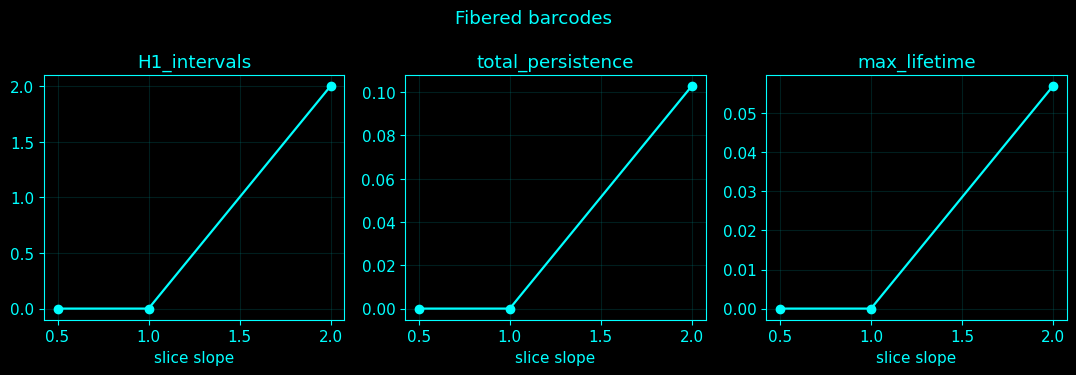

In [230]:
# Method 216: Fibered barcodes

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_216():

    i = 216
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _ph_simplices_nd(ss, max_hom_dim):
        index={simp:i for i,(simp,_,_) in enumerate(ss)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(simp,filt,dim) in enumerate(ss):
            if dim==0:
                col=set()
            else:
                col={index[simp[:q]+simp[q+1:]] for q in range(len(simp))}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j
                bdim=ss[low][2]
                if bdim<=max_hom_dim: pairs.append((bdim,float(ss[low][1]),float(filt)))
            else:
                births.add(j)
        paired=set(low_to_col)
        dg=[]
        for d in range(max_hom_dim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if ss[j][2]==d: arr.append([float(ss[j][1]),np.inf])
            dg.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2),float))
        return dg

    def _fibered_barcode(n,edges,grades,slope=1.0,offset=0.0):
        vals={}
        for e,(g1,g2) in grades.items():vals[e]=max(g1,(g2-offset)/max(slope,TOPO_EPS))
        # vertex filtration zero; triangle enters at max edge value
        ss=[((i,),0.,0) for i in range(n)]
        for e,v in vals.items():ss.append((e,float(v),1))
        for i in range(n):
            for j in range(i+1,n):
                for k in range(j+1,n):
                    if (i,j) in vals and (i,k) in vals and (j,k) in vals:ss.append(((i,j,k),float(max(vals[(i,j)],vals[(i,k)],vals[(j,k)])),2))
        ss.sort(key=lambda z:(z[1],z[2],z[0]));return _ph_simplices_nd(ss,1)

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    rows = []
    for slope in [0.5, 1.0, 2.0]:
        dg = _fibered_barcode(n, edges, grades, slope, 0)
        L = _life(dg[1])
        rows.append([slope, len(L), L.sum(), L.max() if len(L) else 0])
    out = pd.DataFrame(rows, columns=['slice_slope', 'H1_intervals', 'total_persistence', 'max_lifetime'])
    display(out)
    fig, axs = plt.subplots(1, 3, figsize=(11, 3.8), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['H1_intervals', 'total_persistence', 'max_lifetime']):
        ax.plot(out['slice_slope'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.6)
        ax.set_title(col)
        ax.set_xlabel('slice slope')
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Fibered barcodes')
    plt.tight_layout()
    plt.show()
    return


_topology_method_216()
del _topology_method_216


### 217. Hilbert function summaries

The Hilbert function of a multiparameter persistence module is \(h(p)=\dim M_p\). Here \(M_p=H_1(K_p)\), so the displayed two-dimensional array is the H1 Hilbert function over the finite parameter grid.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


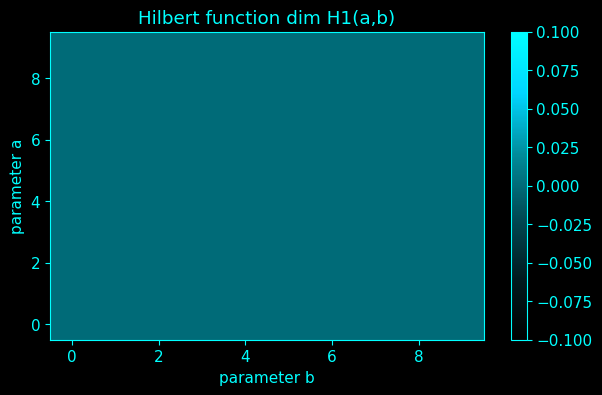

In [231]:
# Method 217: Hilbert function summaries

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_217():

    i = 217
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _bifilt_complex(a,b,n,edges,grades):
        ee=[e for e in edges if grades[e][0]<=a and grades[e][1]<=b];return _flag_complex_from_edge_subset(n,ee,2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    def _betti_surface(n,edges,grades,na=12,nb=12):
        av=np.linspace(0,1,na);bv=np.linspace(0,1,nb);B=np.zeros((na,nb),int)
        for i,a in enumerate(av):
            for j,b in enumerate(bv):B[i,j]=_simplicial_betti_01(_bifilt_complex(a,b,n,edges,grades))[1]
        return av,bv,B

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    av, bv, B = _betti_surface(n, edges, grades, 10, 10)
    _imshow(B, 'Hilbert function dim H1(a,b)', 'parameter b', 'parameter a')
    return


_topology_method_217()
del _topology_method_217


### 218. Betti surfaces

The Betti surface visualizes \(\beta_1(a,b)=\dim H_1(K_{a,b})\). It is equivalent to the H1 Hilbert function on this grid but emphasized as a geometric surface.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


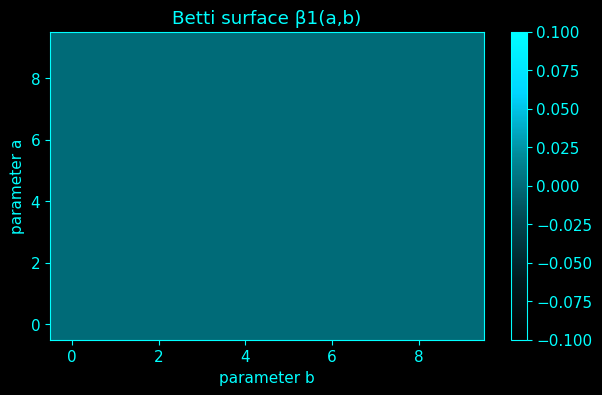

In [232]:
# Method 218: Betti surfaces

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_218():

    i = 218
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _bifilt_complex(a,b,n,edges,grades):
        ee=[e for e in edges if grades[e][0]<=a and grades[e][1]<=b];return _flag_complex_from_edge_subset(n,ee,2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    def _betti_surface(n,edges,grades,na=12,nb=12):
        av=np.linspace(0,1,na);bv=np.linspace(0,1,nb);B=np.zeros((na,nb),int)
        for i,a in enumerate(av):
            for j,b in enumerate(bv):B[i,j]=_simplicial_betti_01(_bifilt_complex(a,b,n,edges,grades))[1]
        return av,bv,B

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    av, bv, B = _betti_surface(n, edges, grades, 10, 10)
    _imshow(B, 'Betti surface β1(a,b)', 'parameter b', 'parameter a')
    return


_topology_method_218()
del _topology_method_218


### 219. Multiparameter persistence landscapes

General multiparameter persistence landscapes require a chosen multiparameter landscape construction. This notebook uses **fibered landscapes**: restrict to several monotone lines, compute ordinary persistence landscapes on each slice, and stack them as a slice-based summary.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


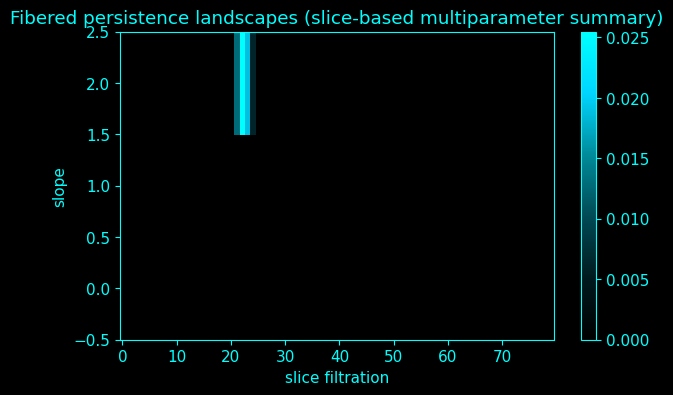

In [233]:
# Method 219: Multiparameter persistence landscapes

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_219():

    i = 219
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _ph_simplices_nd(ss, max_hom_dim):
        index={simp:i for i,(simp,_,_) in enumerate(ss)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(simp,filt,dim) in enumerate(ss):
            if dim==0:
                col=set()
            else:
                col={index[simp[:q]+simp[q+1:]] for q in range(len(simp))}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j
                bdim=ss[low][2]
                if bdim<=max_hom_dim: pairs.append((bdim,float(ss[low][1]),float(filt)))
            else:
                births.add(j)
        paired=set(low_to_col)
        dg=[]
        for d in range(max_hom_dim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if ss[j][2]==d: arr.append([float(ss[j][1]),np.inf])
            dg.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2),float))
        return dg

    def _fibered_barcode(n,edges,grades,slope=1.0,offset=0.0):
        vals={}
        for e,(g1,g2) in grades.items():vals[e]=max(g1,(g2-offset)/max(slope,TOPO_EPS))
        # vertex filtration zero; triangle enters at max edge value
        ss=[((i,),0.,0) for i in range(n)]
        for e,v in vals.items():ss.append((e,float(v),1))
        for i in range(n):
            for j in range(i+1,n):
                for k in range(j+1,n):
                    if (i,j) in vals and (i,k) in vals and (j,k) in vals:ss.append(((i,j,k),float(max(vals[(i,j)],vals[(i,k)],vals[(j,k)])),2))
        ss.sort(key=lambda z:(z[1],z[2],z[0]));return _ph_simplices_nd(ss,1)

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _landscape(dgm,grid,kmax=3):
        d=_finite(dgm); L=np.zeros((kmax,len(grid)))
        for q,t in enumerate(grid):
            tents=np.sort([max(0.0,min(t-b,de-t)) for b,de in d])[::-1]
            L[:min(kmax,len(tents)),q]=tents[:kmax]
        return L

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    rows = []
    for slope in [0.5, 1, 2]:
        dg = _fibered_barcode(n, edges, grades, slope)
        d = _finite(dg[1])
        g = np.linspace(0, max(1, float(np.max(d)) if len(d) else 1), 80)
        L = _landscape(dg[1], g, 1)
        rows.append(L[0])
    _imshow(np.asarray(rows), 'Fibered persistence landscapes (slice-based multiparameter summary)', 'slice filtration', 'slope')
    return


_topology_method_219()
del _topology_method_219


### 220. Interleaving-distance approximations

Exact interleaving distance between multiparameter modules is difficult. The notebook therefore reports an explicitly labelled **grid-shift Betti-surface discrepancy proxy** and does not claim it equals the module interleaving distance.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


grid-shift interleaving proxy: (0, np.float64(0.0)) (not an exact module interleaving distance)


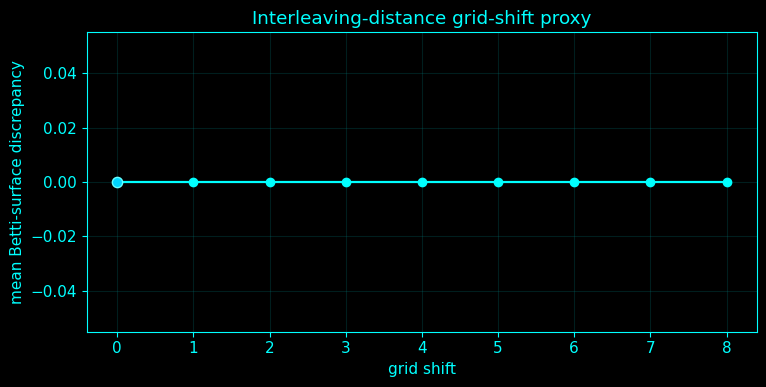

In [234]:
# Method 220: Interleaving-distance approximations

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_220():

    i = 220
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _bifilt_complex(a,b,n,edges,grades):
        ee=[e for e in edges if grades[e][0]<=a and grades[e][1]<=b];return _flag_complex_from_edge_subset(n,ee,2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    def _betti_surface(n,edges,grades,na=12,nb=12):
        av=np.linspace(0,1,na);bv=np.linspace(0,1,nb);B=np.zeros((na,nb),int)
        for i,a in enumerate(av):
            for j,b in enumerate(bv):B[i,j]=_simplicial_betti_01(_bifilt_complex(a,b,n,edges,grades))[1]
        return av,bv,B

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    av, bv, B = _betti_surface(n, edges, grades, 10, 10)
    n2, e2, g2 = _channel_bigrades(n)
    g2 = {e: (min(1, a * 1.03), min(1, b * 1.05)) for e, (a, b) in g2.items()}
    _, _, B2s = _betti_surface(n2, e2, g2, 10, 10)
    best = None
    errs = []
    for sh in range(10):
        err = np.mean(np.abs(B[:10 - sh, :10 - sh] - B2s[sh:, sh:])) if sh < 9 else np.inf
        errs.append(err)
        if best is None or err < best[1]:
            best = (sh, err)
    print('grid-shift interleaving proxy:', best, '(not an exact module interleaving distance)')
    finite = np.isfinite(errs)
    fig, ax = plt.subplots(figsize=(7.8, 4.0), facecolor=TOPO_BG)
    ax.plot(np.arange(10)[finite], np.asarray(errs)[finite], color=TOPO_ACCENT, marker='o', linewidth=1.6)
    ax.scatter([best[0]], [best[1]], s=55, color=TOPO_CYAN_FILL, edgecolor=TOPO_CYAN_SOFT, zorder=3)
    ax.set_title('Interleaving-distance grid-shift proxy')
    ax.set_xlabel('grid shift')
    ax.set_ylabel('mean Betti-surface discrepancy')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_220()
del _topology_method_220


### 221. Multiparameter persistence kernels

A practical multiparameter kernel vectorizes finite Betti surfaces and applies an RBF kernel \(k(B_1,B_2)=\exp[-\|B_1-B_2\|_F^2/(2\sigma^2)]\). This is a positive-definite feature kernel on the chosen discretization, not a complete invariant.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [235]:
# Method 221: Multiparameter persistence kernels

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_221():

    i = 221
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _bifilt_complex(a,b,n,edges,grades):
        ee=[e for e in edges if grades[e][0]<=a and grades[e][1]<=b];return _flag_complex_from_edge_subset(n,ee,2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    def _betti_surface(n,edges,grades,na=12,nb=12):
        av=np.linspace(0,1,na);bv=np.linspace(0,1,nb);B=np.zeros((na,nb),int)
        for i,a in enumerate(av):
            for j,b in enumerate(bv):B[i,j]=_simplicial_betti_01(_bifilt_complex(a,b,n,edges,grades))[1]
        return av,bv,B

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    surf = []
    for seg in np.array_split(_topo_x[:, :n], 2):
        R = np.abs(np.corrcoef(seg.T))
        gg = {e: (grades[e][0], 1 - R[e]) for e in edges}
        surf.append(_betti_surface(n, edges, gg, 8, 8)[2].ravel())
    d = np.linalg.norm(surf[0] - surf[1])
    sig = np.sqrt(len(surf[0]))
    print('multiparameter Betti-surface RBF kernel =', float(np.exp(-d * d / (2 * sig * sig))))
    return


_topology_method_221()
del _topology_method_221


multiparameter Betti-surface RBF kernel = 0.9922179382602435


### 222. Minimal presentations of persistence modules

For H0 of the two-parameter graph filtration, vertices generate the module at grade \((0,0)\) and each edge supplies a relation \(e_u+e_v\) at its bidegree. A relation is kept only if it is not generated by relations at componentwise-smaller grades, yielding a minimal multigraded H0 presentation over \(\mathbb Z_2\) for this finite graph module.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,relation_generator,grade_distance,grade_dissimilarity
0,0,0.253007,0.035458
1,1,0.250000,0.065066
2,2,0.250000,0.100068
3,3,0.250986,0.109908
4,4,0.250986,0.112253
5,5,0.253007,0.142513
6,6,0.205556,0.367820
7,7,0.310018,0.288494
8,8,0.222222,0.385798
9,9,0.500000,0.133183


vertex generators at grade (0,0): 8


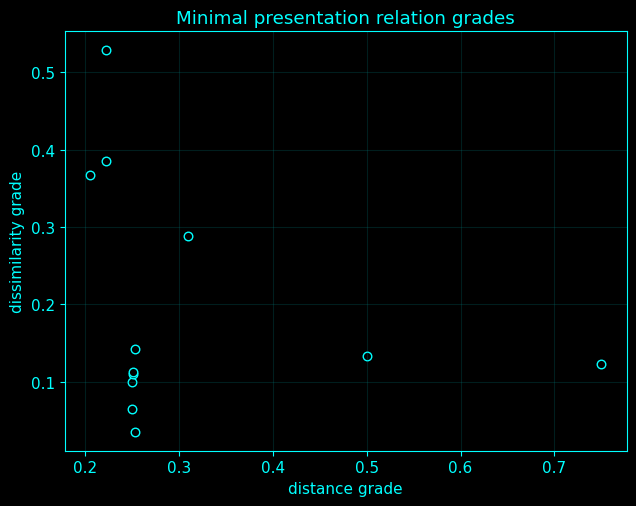

In [236]:
# Method 222: Minimal presentations of persistence modules

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_222():

    i = 222
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _minimal_H0_presentation(n,edges,grades):
        # Vertex generators all at (0,0); retain edge relations not generated by relations with componentwise-smaller grades.
        rel=[];vec=[]
        for e in sorted(edges,key=lambda e:(sum(grades[e]),grades[e][0],grades[e][1])):
            v=np.zeros(n,dtype=np.uint8);v[e[0]]=1;v[e[1]]=1;g=grades[e];eligible=[vec[k] for k,h in enumerate(rel) if h[0]<=g[0]+1e-12 and h[1]<=g[1]+1e-12]
            M=np.column_stack(eligible) if eligible else np.zeros((n,0),dtype=np.uint8)
            if not _gf2_in_span(v,M):rel.append(g);vec.append(v)
        return rel

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    rel = _minimal_H0_presentation(n, edges, grades)
    out = pd.DataFrame({'relation_generator': np.arange(len(rel)), 'grade_distance': [g[0] for g in rel], 'grade_dissimilarity': [g[1] for g in rel]})
    display(out)
    print('vertex generators at grade (0,0):', n)
    if len(out):
        fig, ax = plt.subplots(figsize=(6.5, 5.2), facecolor=TOPO_BG)
        ax.scatter(out['grade_distance'], out['grade_dissimilarity'], s=38, facecolors=TOPO_BG, edgecolors=TOPO_ACCENT)
        ax.set_title('Minimal presentation relation grades')
        ax.set_xlabel('distance grade')
        ax.set_ylabel('dissimilarity grade')
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return
    from collections import Counter
    c = Counter(((round(a, 3), round(b, 3)) for a, b in rel))
    out = pd.DataFrame([['beta0', (0.0, 0.0), n], *[['beta1', g, k] for g, k in c.items()]], columns=['multigraded_Betti', 'grade', 'multiplicity'])
    display(out)
    fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=TOPO_BG)
    labels = [f'{b}@{g}' for b, g in zip(out['multigraded_Betti'], out['grade'])]
    ax.bar(np.arange(len(out)), out['multiplicity'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_xticks(np.arange(len(out)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_title('Graded Betti numbers of persistence modules')
    ax.set_ylabel('multiplicity')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_222()
del _topology_method_222


### 223. Graded Betti numbers of persistence modules

Multigraded Betti numbers count minimal generators and relations by bidegree. From the H0 presentation, \(\beta_0(g)\) counts vertex generators and \(\beta_1(g)\) counts minimal relation generators at grade \(g\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,multigraded_Betti,grade,multiplicity
0,beta0,"(0.0, 0.0)",8
1,beta1,"(0.253, 0.035)",1
2,beta1,"(0.25, 0.065)",1
3,beta1,"(0.25, 0.1)",1
4,beta1,"(0.251, 0.11)",1
5,beta1,"(0.251, 0.112)",1
6,beta1,"(0.253, 0.143)",1
7,beta1,"(0.206, 0.368)",1
8,beta1,"(0.31, 0.288)",1
9,beta1,"(0.222, 0.386)",1


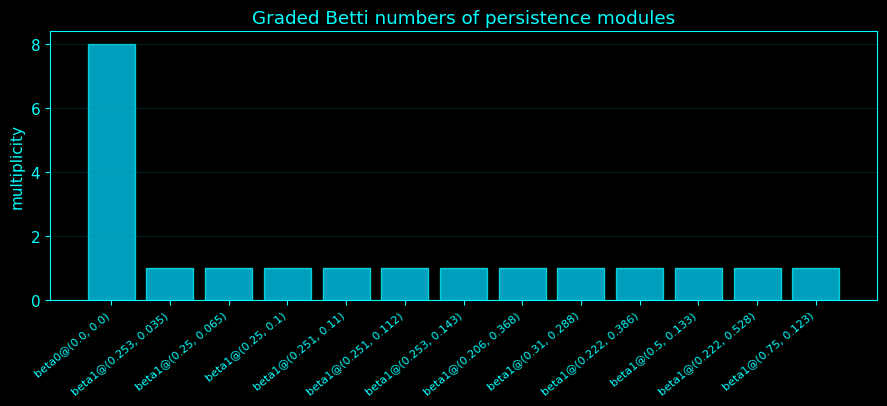

In [237]:
# Method 223: Graded Betti numbers of persistence modules

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_223():

    i = 223
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _minimal_H0_presentation(n,edges,grades):
        # Vertex generators all at (0,0); retain edge relations not generated by relations with componentwise-smaller grades.
        rel=[];vec=[]
        for e in sorted(edges,key=lambda e:(sum(grades[e]),grades[e][0],grades[e][1])):
            v=np.zeros(n,dtype=np.uint8);v[e[0]]=1;v[e[1]]=1;g=grades[e];eligible=[vec[k] for k,h in enumerate(rel) if h[0]<=g[0]+1e-12 and h[1]<=g[1]+1e-12]
            M=np.column_stack(eligible) if eligible else np.zeros((n,0),dtype=np.uint8)
            if not _gf2_in_span(v,M):rel.append(g);vec.append(v)
        return rel

    # Method mathematics and output.
    n, edges, grades = _channel_bigrades()
    rel = _minimal_H0_presentation(n, edges, grades)
    from collections import Counter
    c = Counter(((round(a, 3), round(b, 3)) for a, b in rel))
    out = pd.DataFrame([['beta0', (0.0, 0.0), n], *[['beta1', g, k] for g, k in c.items()]], columns=['multigraded_Betti', 'grade', 'multiplicity'])
    display(out)
    fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=TOPO_BG)
    labels = [f'{b}@{g}' for b, g in zip(out['multigraded_Betti'], out['grade'])]
    ax.bar(np.arange(len(out)), out['multiplicity'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_xticks(np.arange(len(out)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_title('Graded Betti numbers of persistence modules')
    ax.set_ylabel('multiplicity')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_223()
del _topology_method_223


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — knot/link/homotopy/stability helpers for topology methods 224–244</h3>
<p>This foundation closes finite delay curves and computes controlled polygonal knot/link diagnostics: Gauss linking, writhe/framing quantities, and exact two-strand braid invariants where the derived braid lies in \(B_2\cong\mathbb Z\). It also supplies obstruction/homotopy diagnostics and persistence stability distances. Exact Alexander/Jones claims are restricted to the derived two-braid construction; general polygonal curves are not assigned unsupported knot polynomials.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [238]:
# =======================================================
# TOPOLOGY CATALOGUE IMPORTS — methods 224–244
# No shared mathematical helper functions.
# =======================================================
import sympy as sp


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — topology methods 224–244</h3>
<p>This dispatcher selects the requested knot/link/braid, homotopy/obstruction, or persistence-stability method and applies the validated helper routines. Empty cycle/diagram cases are handled explicitly rather than being assigned artificial nonzero invariants.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


### 224. Knot invariants of 3D trajectories

The delay trajectory is converted to a finite closed polygon by explicitly joining its endpoint to its start. Because arbitrary closure can change knot type, this cell does **not** pretend the open EEG trajectory has a canonical knot. It reports closed-curve geometric/topological diagnostics: Gauss self-writhe and linking with a small framed push-off; exact braid-closure polynomial invariants are computed in methods 227–228.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


closed 3D delay-curve diagnostics: writhe= 50.06545919405418 framed self-linking≈ 96.89391195715862 rounded self-linking= 97


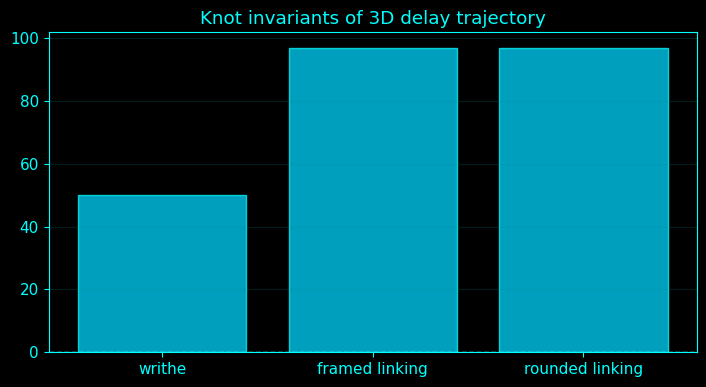

In [240]:
# Method 224: Knot invariants of 3D trajectories

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_224():

    i = 224
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _closed_delay_curve(y,m=3,tau=None,npts=None):
        if tau is None:tau=max(1,int(.01*_topo_fs))
        if npts is None:npts={'full':240,'balanced':180,'fast':130,'ultra':90}[FAST_OPTION]
        X=_delay_embed(y,m,tau,max_points=max(npts,20));X=signal.resample(X,npts,axis=0);X=(X-X.mean(0))/(X.std(0)+TOPO_EPS);return np.vstack([X,X[0]])

    def _framed_push_off(C,eps=.08):
        P=np.asarray(C[:-1],float);T=np.roll(P,-1,axis=0)-np.roll(P,1,axis=0);T/=np.linalg.norm(T,axis=1,keepdims=True)+TOPO_EPS;ref=np.tile(np.array([0.,0.,1.]),(len(P),1));N=np.cross(T,ref);bad=np.linalg.norm(N,axis=1)<1e-6;N[bad]=np.cross(T[bad],np.array([1.,0.,0.]));N/=np.linalg.norm(N,axis=1,keepdims=True)+TOPO_EPS
        for i in range(1,len(N)):
            if np.dot(N[i],N[i-1])<0:N[i]*=-1
        Q=P+eps*N;return np.vstack([Q,Q[0]])

    def _gauss_link_midpoint(C1,C2):
        C1=np.asarray(C1,float);C2=np.asarray(C2,float);a=C1[1:]-C1[:-1];b=C2[1:]-C2[:-1];ma=(C1[1:]+C1[:-1])/2;mb=(C2[1:]+C2[:-1])/2;val=0.
        for i in range(len(a)):
            r=ma[i]-mb;den=np.linalg.norm(r,axis=1)**3;ok=den>1e-12;val+=np.sum((np.cross(a[i],b[ok])*r[ok]).sum(1)/den[ok])
        return float(val/(4*np.pi))

    def _writhe_midpoint(C):
        C=np.asarray(C,float);a=C[1:]-C[:-1];m=(C[1:]+C[:-1])/2;val=0.;N=len(a)
        for i in range(N):
            for j in range(i+1,N):
                if j==i+1 or (i==0 and j==N-1):continue
                r=m[i]-m[j];den=np.linalg.norm(r)**3
                if den>1e-12:val+=2*np.dot(np.cross(a[i],a[j]),r)/den
        return float(val/(4*np.pi))

    # Method mathematics and output.
    C = _closed_delay_curve(_topo_pc1)
    wr = _writhe_midpoint(C)
    Q = _framed_push_off(C)
    lk = _gauss_link_midpoint(C, Q)
    rounded = int(np.rint(lk))
    print('closed 3D delay-curve diagnostics: writhe=', wr, 'framed self-linking≈', lk, 'rounded self-linking=', rounded)
    fig, ax = plt.subplots(figsize=(7.2, 4.0), facecolor=TOPO_BG)
    ax.bar(['writhe', 'framed linking', 'rounded linking'], [wr, lk, rounded], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.axhline(0, color=TOPO_CYAN_SOFT, linestyle='--', linewidth=1.0)
    ax.set_title('Knot invariants of 3D delay trajectory')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_224()
del _topology_method_224


### 225. Linking number between channel trajectories

For two disjoint closed curves \(C_1,C_2\), the Gauss linking number is \(Lk=(4\pi)^{-1}\oint_{C_1}\oint_{C_2}[(d\mathbf r_1\times d\mathbf r_2)\cdot(\mathbf r_1-\mathbf r_2)]/\|\mathbf r_1-\mathbf r_2\|^3\). The notebook evaluates a midpoint polygonal quadrature; values near integers are expected only when curves are well separated and adequately resolved.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


In [241]:
# Method 225: Linking number between channel trajectories

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_225():

    i = 225
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _closed_delay_curve(y,m=3,tau=None,npts=None):
        if tau is None:tau=max(1,int(.01*_topo_fs))
        if npts is None:npts={'full':240,'balanced':180,'fast':130,'ultra':90}[FAST_OPTION]
        X=_delay_embed(y,m,tau,max_points=max(npts,20));X=signal.resample(X,npts,axis=0);X=(X-X.mean(0))/(X.std(0)+TOPO_EPS);return np.vstack([X,X[0]])

    def _gauss_link_midpoint(C1,C2):
        C1=np.asarray(C1,float);C2=np.asarray(C2,float);a=C1[1:]-C1[:-1];b=C2[1:]-C2[:-1];ma=(C1[1:]+C1[:-1])/2;mb=(C2[1:]+C2[:-1])/2;val=0.
        for i in range(len(a)):
            r=ma[i]-mb;den=np.linalg.norm(r,axis=1)**3;ok=den>1e-12;val+=np.sum((np.cross(a[i],b[ok])*r[ok]).sum(1)/den[ok])
        return float(val/(4*np.pi))

    # Method mathematics and output.
    C1 = _closed_delay_curve(_topo_x[:, 0])
    C2 = _closed_delay_curve(_topo_x[:, 1])
    print('Gauss linking-number estimate between channel delay loops =', _gauss_link_midpoint(C1, C2))
    return


_topology_method_225()
del _topology_method_225


Gauss linking-number estimate between channel delay loops = 23.267910110576533


### 226. Writhe and twist of 3D EEG trajectories

For a framed closed ribbon, the Călugăreanu–White–Fuller relation is \(Lk=Wr+Tw\). A continuous numerical normal framing generates a small push-off curve; self-writhe is estimated by the Gauss double integral, framed linking by the two-curve integral, and twist is obtained as \(Tw=Lk-Wr\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


{'writhe': 50.06545919405418, 'framed_linking': 96.89391195715862, 'twist_from_Lk_minus_Wr': 46.828452763104444, 'check_Lk_minus_Wr_minus_Tw': 0.0}


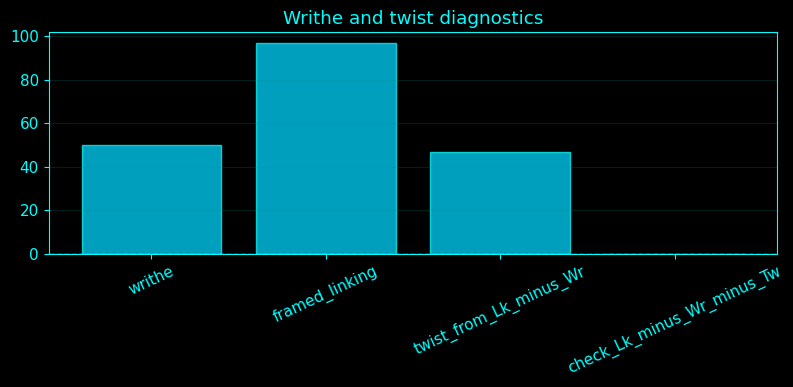

In [242]:
# Method 226: Writhe and twist of 3D EEG trajectories

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_226():

    i = 226
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _closed_delay_curve(y,m=3,tau=None,npts=None):
        if tau is None:tau=max(1,int(.01*_topo_fs))
        if npts is None:npts={'full':240,'balanced':180,'fast':130,'ultra':90}[FAST_OPTION]
        X=_delay_embed(y,m,tau,max_points=max(npts,20));X=signal.resample(X,npts,axis=0);X=(X-X.mean(0))/(X.std(0)+TOPO_EPS);return np.vstack([X,X[0]])

    def _framed_push_off(C,eps=.08):
        P=np.asarray(C[:-1],float);T=np.roll(P,-1,axis=0)-np.roll(P,1,axis=0);T/=np.linalg.norm(T,axis=1,keepdims=True)+TOPO_EPS;ref=np.tile(np.array([0.,0.,1.]),(len(P),1));N=np.cross(T,ref);bad=np.linalg.norm(N,axis=1)<1e-6;N[bad]=np.cross(T[bad],np.array([1.,0.,0.]));N/=np.linalg.norm(N,axis=1,keepdims=True)+TOPO_EPS
        for i in range(1,len(N)):
            if np.dot(N[i],N[i-1])<0:N[i]*=-1
        Q=P+eps*N;return np.vstack([Q,Q[0]])

    def _gauss_link_midpoint(C1,C2):
        C1=np.asarray(C1,float);C2=np.asarray(C2,float);a=C1[1:]-C1[:-1];b=C2[1:]-C2[:-1];ma=(C1[1:]+C1[:-1])/2;mb=(C2[1:]+C2[:-1])/2;val=0.
        for i in range(len(a)):
            r=ma[i]-mb;den=np.linalg.norm(r,axis=1)**3;ok=den>1e-12;val+=np.sum((np.cross(a[i],b[ok])*r[ok]).sum(1)/den[ok])
        return float(val/(4*np.pi))

    def _writhe_midpoint(C):
        C=np.asarray(C,float);a=C[1:]-C[:-1];m=(C[1:]+C[:-1])/2;val=0.;N=len(a)
        for i in range(N):
            for j in range(i+1,N):
                if j==i+1 or (i==0 and j==N-1):continue
                r=m[i]-m[j];den=np.linalg.norm(r)**3
                if den>1e-12:val+=2*np.dot(np.cross(a[i],a[j]),r)/den
        return float(val/(4*np.pi))

    # Method mathematics and output.
    C = _closed_delay_curve(_topo_pc1)
    Q = _framed_push_off(C)
    wr = _writhe_midpoint(C)
    lk = _gauss_link_midpoint(C, Q)
    tw = lk - wr
    out = {'writhe': wr, 'framed_linking': lk, 'twist_from_Lk_minus_Wr': tw, 'check_Lk_minus_Wr_minus_Tw': lk - wr - tw}
    print(out)
    fig, ax = plt.subplots(figsize=(8.2, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.axhline(0, color=TOPO_CYAN_SOFT, linestyle='--', linewidth=1.0)
    ax.set_title('Writhe and twist diagnostics')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_226()
del _topology_method_226


### 227. Alexander polynomial features

A two-strand EEG braid is extracted from crossings of two channel strands, with over/under information supplied by a second signal coordinate. For \(B_2\), the reduced Burau representation sends \(\sigma_1\mapsto[-t]\). The Alexander polynomial of the closure is therefore \(\Delta(t)=(1-t)(1-(-t)^k)/(1-t^2)\), up to multiplication by \(\pm t^m\), where \(k\) is the braid exponent sum.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


2-braid exponent= 5 Alexander polynomial (up to ±t^m) = t**4 - t**3 + t**2 - t + 1


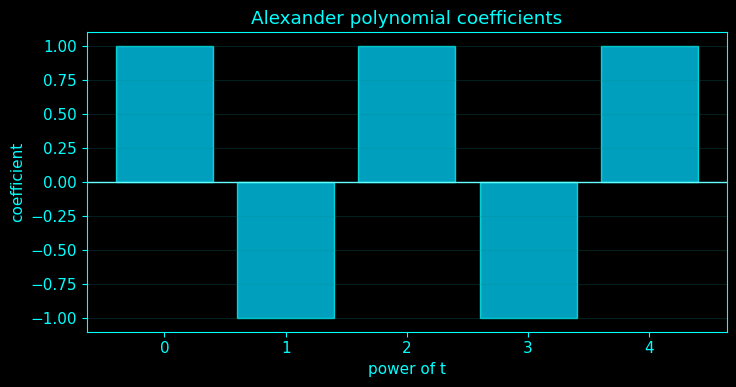

In [243]:
# Method 227: Alexander polynomial features

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_227():

    i = 227
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _alexander_braid2(word):
        t=sp.symbols('t');k=int(np.sum(word));expr=sp.cancel((1-t)/(1-t**2)*(1-(-t)**k)) if k!=0 else sp.Integer(0);return sp.factor(expr),k

    def _braid2_word(y1,y2,z1=None,z2=None,maxn=None):
        if maxn is None:maxn={'full':1200,'balanced':800,'fast':500,'ultra':320}[FAST_OPTION]
        n=min(len(y1),len(y2));idx=np.linspace(0,n-1,min(n,maxn)).astype(int);a=np.asarray(y1)[idx];b=np.asarray(y2)[idx]
        if z1 is None:z1=np.gradient(a)
        else:z1=np.asarray(z1)[idx]
        if z2 is None:z2=np.gradient(b)
        else:z2=np.asarray(z2)[idx]
        d=a-b;word=[]
        for k in range(len(d)-1):
            if d[k]==0 or d[k]*d[k+1]<0:
                den=d[k]-d[k+1];lam=.5 if abs(den)<1e-12 else d[k]/den;zz1=z1[k]+lam*(z1[k+1]-z1[k]);zz2=z2[k]+lam*(z2[k+1]-z2[k]);left_is_1=a[k]<b[k];over_is_1=zz1>zz2;word.append(1 if left_is_1==over_is_1 else -1)
        return word

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _braid_inputs():
        n=min(len(_topo_x),12000);y1=_topo_x[:n,0];y2=_topo_x[:n,1];hi=min(30,_topo_fs/2-.5);lo=min(18,max(.5,hi-3));
        if hi>lo:
            z1=np.abs(signal.hilbert(_filter_band(y1,lo,hi)));z2=np.abs(signal.hilbert(_filter_band(y2,lo,hi)))
        else:z1=np.gradient(y1);z2=np.gradient(y2)
        return y1,y2,z1,z2

    # Method mathematics and output.
    y1, y2, z1, z2 = _braid_inputs()
    word = _braid2_word(y1, y2, z1, z2)
    D, k = _alexander_braid2(word)
    print('2-braid exponent=', k, 'Alexander polynomial (up to ±t^m) =', D)
    t = sp.symbols('t')
    terms = sp.expand(D).as_ordered_terms()
    exps = []
    coeffs = []
    for term in terms:
        c, e = term.as_coeff_exponent(t)
        exps.append(int(e))
        coeffs.append(float(sp.N(c)))
    if coeffs:
        fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
        ax.bar(exps, coeffs, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.axhline(0, color=TOPO_CYAN_SOFT, linewidth=1.0)
        ax.set_title('Alexander polynomial coefficients')
        ax.set_xlabel('power of t')
        ax.set_ylabel('coefficient')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return
    rows = []
    for frac in np.linspace(0.25, 1, 4):
        k = max(20, int(len(y1) * frac))
        wrd = _braid2_word(y1[:k], y2[:k], z1[:k], z2[:k])
        rows.append([frac, len(wrd), sum(wrd), str(_alexander_braid2(wrd)[0])])
    out = pd.DataFrame(rows, columns=['record_fraction', 'crossings', 'braid_exponent', 'Alexander'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.2, 4.0), facecolor=TOPO_BG)
    ax2 = ax.twinx()
    ax.plot(out['record_fraction'], out['crossings'], color=TOPO_ACCENT, marker='o', linewidth=1.6, label='crossings')
    ax2.plot(out['record_fraction'], out['braid_exponent'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='braid exponent')
    ax.set_title('Persistent braid invariants')
    ax.set_xlabel('record fraction')
    ax.set_ylabel('crossings')
    ax2.set_ylabel('braid exponent', color=TOPO_CYAN_SOFT)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc='best')
    plt.tight_layout()
    plt.show()
    return


_topology_method_227()
del _topology_method_227


### 228. Jones polynomial features

The Jones polynomial of the same 2-braid closure is computed exactly through the Temperley–Lieb algebra \(TL_2\): \(e^2=\delta e\), \(\delta=-A^2-A^{-2}\), and a positive crossing is \(A I+A^{-1}e\). After closing the braid, \(V=(-A)^{-3w}\langle D\rangle\) with \(t=A^{-4}\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


2-braid writhe= 5 Jones polynomial in A with t=A^-4 = A**(-8) + A**(-16) - 1/A**20 + A**(-24) - 1/A**28


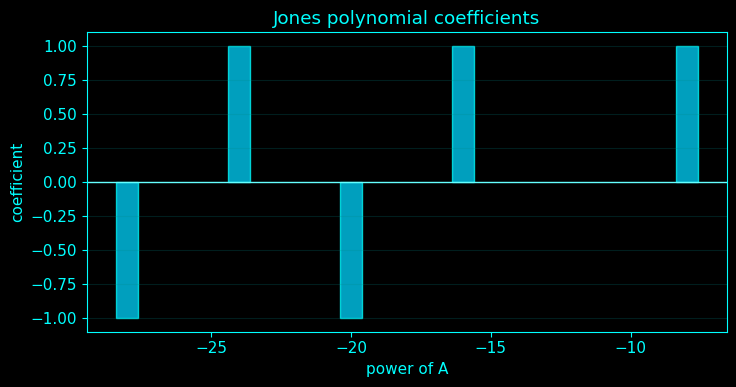

In [244]:
# Method 228: Jones polynomial features

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_228():

    i = 228
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _alexander_braid2(word):
        t=sp.symbols('t');k=int(np.sum(word));expr=sp.cancel((1-t)/(1-t**2)*(1-(-t)**k)) if k!=0 else sp.Integer(0);return sp.factor(expr),k

    def _braid2_word(y1,y2,z1=None,z2=None,maxn=None):
        if maxn is None:maxn={'full':1200,'balanced':800,'fast':500,'ultra':320}[FAST_OPTION]
        n=min(len(y1),len(y2));idx=np.linspace(0,n-1,min(n,maxn)).astype(int);a=np.asarray(y1)[idx];b=np.asarray(y2)[idx]
        if z1 is None:z1=np.gradient(a)
        else:z1=np.asarray(z1)[idx]
        if z2 is None:z2=np.gradient(b)
        else:z2=np.asarray(z2)[idx]
        d=a-b;word=[]
        for k in range(len(d)-1):
            if d[k]==0 or d[k]*d[k+1]<0:
                den=d[k]-d[k+1];lam=.5 if abs(den)<1e-12 else d[k]/den;zz1=z1[k]+lam*(z1[k+1]-z1[k]);zz2=z2[k]+lam*(z2[k+1]-z2[k]);left_is_1=a[k]<b[k];over_is_1=zz1>zz2;word.append(1 if left_is_1==over_is_1 else -1)
        return word

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _braid_inputs():
        n=min(len(_topo_x),12000);y1=_topo_x[:n,0];y2=_topo_x[:n,1];hi=min(30,_topo_fs/2-.5);lo=min(18,max(.5,hi-3));
        if hi>lo:
            z1=np.abs(signal.hilbert(_filter_band(y1,lo,hi)));z2=np.abs(signal.hilbert(_filter_band(y2,lo,hi)))
        else:z1=np.gradient(y1);z2=np.gradient(y2)
        return y1,y2,z1,z2

    def _jones_braid2(word):
        A=sp.symbols('A');delta=-A**2-A**-2;a,b=sp.Integer(1),sp.Integer(0);w=int(np.sum(word))
        # B2 is infinite cyclic, so freely reduce the word to sigma_1^w before exact TL2 evaluation.
        gen=(A,A**-1) if w>=0 else (A**-1,A)
        for _ in range(abs(w)):
            c,d=gen;a,b=sp.expand(a*c),sp.expand(a*d+b*c+b*d*delta)
        bracket=sp.expand(a*delta+b);V=sp.expand(sp.simplify((-A)**(-3*w)*bracket));return V,w

    # Method mathematics and output.
    y1, y2, z1, z2 = _braid_inputs()
    word = _braid2_word(y1, y2, z1, z2)
    V, w = _jones_braid2(word)
    print('2-braid writhe=', w, 'Jones polynomial in A with t=A^-4 =', V)
    Avar = sp.symbols('A')
    terms = sp.expand(V).as_ordered_terms()
    exps = []
    coeffs = []
    for term in terms:
        c, e = term.as_coeff_exponent(Avar)
        exps.append(int(e))
        coeffs.append(float(sp.N(c)))
    if coeffs:
        fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
        ax.bar(exps, coeffs, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.axhline(0, color=TOPO_CYAN_SOFT, linewidth=1.0)
        ax.set_title('Jones polynomial coefficients')
        ax.set_xlabel('power of A')
        ax.set_ylabel('coefficient')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return
    rows = []
    for frac in np.linspace(0.25, 1, 4):
        k = max(20, int(len(y1) * frac))
        wrd = _braid2_word(y1[:k], y2[:k], z1[:k], z2[:k])
        rows.append([frac, len(wrd), sum(wrd), str(_alexander_braid2(wrd)[0])])
    out = pd.DataFrame(rows, columns=['record_fraction', 'crossings', 'braid_exponent', 'Alexander'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.2, 4.0), facecolor=TOPO_BG)
    ax2 = ax.twinx()
    ax.plot(out['record_fraction'], out['crossings'], color=TOPO_ACCENT, marker='o', linewidth=1.6, label='crossings')
    ax2.plot(out['record_fraction'], out['braid_exponent'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='braid exponent')
    ax.set_title('Persistent braid invariants')
    ax.set_xlabel('record fraction')
    ax.set_ylabel('crossings')
    ax2.set_ylabel('braid exponent', color=TOPO_CYAN_SOFT)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc='best')
    plt.tight_layout()
    plt.show()
    return


_topology_method_228()
del _topology_method_228


### 229. Braid analysis of channel orderings

A braid records how ordered strands exchange as time increases. Whenever the two channel amplitudes swap order, the notebook records \(\sigma_1\) or \(\sigma_1^{-1}\); the sign is fixed by which strand is over in a second coordinate. For two strands the braid group is \(B_2\cong\mathbb Z\), so the exponent sum classifies the braid element.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


2-strand braid word length= 43 exponent sum= 5 first generators= [1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, 1, 1]


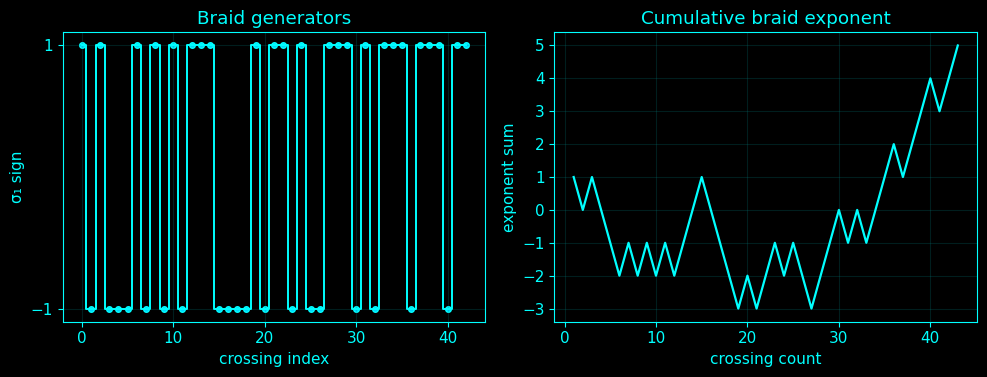

In [245]:
# Method 229: Braid analysis of channel orderings

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_229():

    i = 229
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _alexander_braid2(word):
        t=sp.symbols('t');k=int(np.sum(word));expr=sp.cancel((1-t)/(1-t**2)*(1-(-t)**k)) if k!=0 else sp.Integer(0);return sp.factor(expr),k

    def _braid2_word(y1,y2,z1=None,z2=None,maxn=None):
        if maxn is None:maxn={'full':1200,'balanced':800,'fast':500,'ultra':320}[FAST_OPTION]
        n=min(len(y1),len(y2));idx=np.linspace(0,n-1,min(n,maxn)).astype(int);a=np.asarray(y1)[idx];b=np.asarray(y2)[idx]
        if z1 is None:z1=np.gradient(a)
        else:z1=np.asarray(z1)[idx]
        if z2 is None:z2=np.gradient(b)
        else:z2=np.asarray(z2)[idx]
        d=a-b;word=[]
        for k in range(len(d)-1):
            if d[k]==0 or d[k]*d[k+1]<0:
                den=d[k]-d[k+1];lam=.5 if abs(den)<1e-12 else d[k]/den;zz1=z1[k]+lam*(z1[k+1]-z1[k]);zz2=z2[k]+lam*(z2[k+1]-z2[k]);left_is_1=a[k]<b[k];over_is_1=zz1>zz2;word.append(1 if left_is_1==over_is_1 else -1)
        return word

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _braid_inputs():
        n=min(len(_topo_x),12000);y1=_topo_x[:n,0];y2=_topo_x[:n,1];hi=min(30,_topo_fs/2-.5);lo=min(18,max(.5,hi-3));
        if hi>lo:
            z1=np.abs(signal.hilbert(_filter_band(y1,lo,hi)));z2=np.abs(signal.hilbert(_filter_band(y2,lo,hi)))
        else:z1=np.gradient(y1);z2=np.gradient(y2)
        return y1,y2,z1,z2

    # Method mathematics and output.
    y1, y2, z1, z2 = _braid_inputs()
    word = _braid2_word(y1, y2, z1, z2)
    print('2-strand braid word length=', len(word), 'exponent sum=', sum(word), 'first generators=', word[:40])
    if len(word):
        ww = np.asarray(word, int)
        fig, axs = plt.subplots(1, 2, figsize=(10, 3.9), facecolor=TOPO_BG)
        axs[0].step(np.arange(len(ww)), ww, where='mid', color=TOPO_ACCENT, linewidth=1.4)
        axs[0].scatter(np.arange(len(ww)), ww, s=16, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT)
        axs[0].set_title('Braid generators')
        axs[0].set_xlabel('crossing index')
        axs[0].set_ylabel('σ₁ sign')
        axs[0].set_yticks([-1, 1])
        axs[1].plot(np.arange(1, len(ww) + 1), np.cumsum(ww), color=TOPO_ACCENT, linewidth=1.6)
        axs[1].set_title('Cumulative braid exponent')
        axs[1].set_xlabel('crossing count')
        axs[1].set_ylabel('exponent sum')
        for ax in axs:
            ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return
    rows = []
    for frac in np.linspace(0.25, 1, 4):
        k = max(20, int(len(y1) * frac))
        wrd = _braid2_word(y1[:k], y2[:k], z1[:k], z2[:k])
        rows.append([frac, len(wrd), sum(wrd), str(_alexander_braid2(wrd)[0])])
    out = pd.DataFrame(rows, columns=['record_fraction', 'crossings', 'braid_exponent', 'Alexander'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.2, 4.0), facecolor=TOPO_BG)
    ax2 = ax.twinx()
    ax.plot(out['record_fraction'], out['crossings'], color=TOPO_ACCENT, marker='o', linewidth=1.6, label='crossings')
    ax2.plot(out['record_fraction'], out['braid_exponent'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='braid exponent')
    ax.set_title('Persistent braid invariants')
    ax.set_xlabel('record fraction')
    ax.set_ylabel('crossings')
    ax2.set_ylabel('braid exponent', color=TOPO_CYAN_SOFT)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc='best')
    plt.tight_layout()
    plt.show()
    return


_topology_method_229()
del _topology_method_229


### 230. Persistent braid invariants

Persistent braid invariants recompute braid crossing count, exponent sum and Alexander polynomial on increasing record prefixes. This is persistence with observation length, not a homological persistence module.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,record_fraction,crossings,braid_exponent,Alexander
0,0.25,14,2,1 - t
1,0.50,27,1,1
2,0.75,20,-4,(t - 1)*(t**2 + 1)/t**4
3,1.00,43,5,t**4 - t**3 + t**2 - t + 1


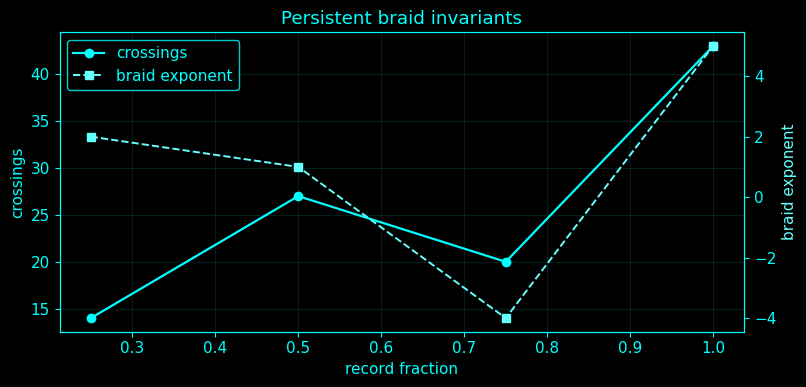

In [246]:
# Method 230: Persistent braid invariants

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_230():

    i = 230
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _alexander_braid2(word):
        t=sp.symbols('t');k=int(np.sum(word));expr=sp.cancel((1-t)/(1-t**2)*(1-(-t)**k)) if k!=0 else sp.Integer(0);return sp.factor(expr),k

    def _braid2_word(y1,y2,z1=None,z2=None,maxn=None):
        if maxn is None:maxn={'full':1200,'balanced':800,'fast':500,'ultra':320}[FAST_OPTION]
        n=min(len(y1),len(y2));idx=np.linspace(0,n-1,min(n,maxn)).astype(int);a=np.asarray(y1)[idx];b=np.asarray(y2)[idx]
        if z1 is None:z1=np.gradient(a)
        else:z1=np.asarray(z1)[idx]
        if z2 is None:z2=np.gradient(b)
        else:z2=np.asarray(z2)[idx]
        d=a-b;word=[]
        for k in range(len(d)-1):
            if d[k]==0 or d[k]*d[k+1]<0:
                den=d[k]-d[k+1];lam=.5 if abs(den)<1e-12 else d[k]/den;zz1=z1[k]+lam*(z1[k+1]-z1[k]);zz2=z2[k]+lam*(z2[k+1]-z2[k]);left_is_1=a[k]<b[k];over_is_1=zz1>zz2;word.append(1 if left_is_1==over_is_1 else -1)
        return word

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _braid_inputs():
        n=min(len(_topo_x),12000);y1=_topo_x[:n,0];y2=_topo_x[:n,1];hi=min(30,_topo_fs/2-.5);lo=min(18,max(.5,hi-3));
        if hi>lo:
            z1=np.abs(signal.hilbert(_filter_band(y1,lo,hi)));z2=np.abs(signal.hilbert(_filter_band(y2,lo,hi)))
        else:z1=np.gradient(y1);z2=np.gradient(y2)
        return y1,y2,z1,z2

    # Method mathematics and output.
    y1, y2, z1, z2 = _braid_inputs()
    word = _braid2_word(y1, y2, z1, z2)
    rows = []
    for frac in np.linspace(0.25, 1, 4):
        k = max(20, int(len(y1) * frac))
        wrd = _braid2_word(y1[:k], y2[:k], z1[:k], z2[:k])
        rows.append([frac, len(wrd), sum(wrd), str(_alexander_braid2(wrd)[0])])
    out = pd.DataFrame(rows, columns=['record_fraction', 'crossings', 'braid_exponent', 'Alexander'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.2, 4.0), facecolor=TOPO_BG)
    ax2 = ax.twinx()
    ax.plot(out['record_fraction'], out['crossings'], color=TOPO_ACCENT, marker='o', linewidth=1.6, label='crossings')
    ax2.plot(out['record_fraction'], out['braid_exponent'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.4, label='braid exponent')
    ax.set_title('Persistent braid invariants')
    ax.set_xlabel('record fraction')
    ax.set_ylabel('crossings')
    ax2.set_ylabel('braid exponent', color=TOPO_CYAN_SOFT)
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc='best')
    plt.tight_layout()
    plt.show()
    return


_topology_method_230()
del _topology_method_230


### 231. Topological helicity

For thin closed flux/vortex tubes with unit circulation and neglecting self-linking, helicity contains the topological term \(H=2\sum_{i<j}Lk(C_i,C_j)\). The notebook uses theta/alpha/beta delay loops and reports this explicitly as a thin-loop helicity proxy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


unit-circulation thin-loop helicity proxy H=2ΣLk = -275.14718257097684 pairwise [(0, 1, 122.65153599350673), (0, 2, -267.7559091314163), (1, 2, 7.530781852421111)]


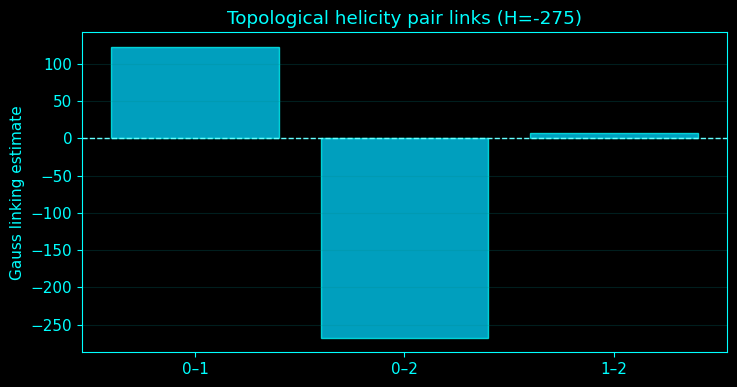

In [247]:
# Method 231: Topological helicity

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_231():

    i = 231
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _closed_delay_curve(y,m=3,tau=None,npts=None):
        if tau is None:tau=max(1,int(.01*_topo_fs))
        if npts is None:npts={'full':240,'balanced':180,'fast':130,'ultra':90}[FAST_OPTION]
        X=_delay_embed(y,m,tau,max_points=max(npts,20));X=signal.resample(X,npts,axis=0);X=(X-X.mean(0))/(X.std(0)+TOPO_EPS);return np.vstack([X,X[0]])

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _gauss_link_midpoint(C1,C2):
        C1=np.asarray(C1,float);C2=np.asarray(C2,float);a=C1[1:]-C1[:-1];b=C2[1:]-C2[:-1];ma=(C1[1:]+C1[:-1])/2;mb=(C2[1:]+C2[:-1])/2;val=0.
        for i in range(len(a)):
            r=ma[i]-mb;den=np.linalg.norm(r,axis=1)**3;ok=den>1e-12;val+=np.sum((np.cross(a[i],b[ok])*r[ok]).sum(1)/den[ok])
        return float(val/(4*np.pi))

    # Method mathematics and output.
    bands = [(4, 8), (8, 13), (13, 30)]
    loops = []
    for lo, hi in bands:
        if hi < _topo_fs / 2:
            loops.append(_closed_delay_curve(_filter_band(_topo_pc1, lo, hi)))
    H = 0.0
    pairs = []
    for a in range(len(loops)):
        for b in range(a + 1, len(loops)):
            lk = _gauss_link_midpoint(loops[a], loops[b])
            pairs.append((a, b, lk))
            H += 2 * lk
    print('unit-circulation thin-loop helicity proxy H=2ΣLk =', H, 'pairwise', pairs)
    if pairs:
        labels = [f'{a}–{b}' for a, b, _ in pairs]
        vals = [v for _, _, v in pairs]
        fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
        ax.bar(labels, vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.axhline(0, color=TOPO_CYAN_SOFT, linewidth=1.0, linestyle='--')
        ax.set_title(f'Topological helicity pair links (H={H:.3g})')
        ax.set_ylabel('Gauss linking estimate')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return


_topology_method_231()
del _topology_method_231


### 232. Loop linking between frequency bands

Band-specific closed delay loops are constructed after filtering PC1. Pairwise Gauss linking estimates quantify how the chosen frequency-band loops wind around one another in the 3-D delay representation.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,band_1,band_2,Gauss_linking_estimate
0,theta,alpha,122.651536
1,theta,beta,-267.755909
2,alpha,beta,7.530782


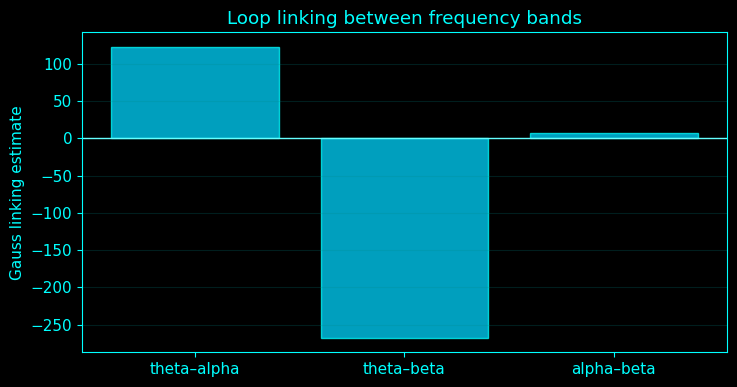

In [248]:
# Method 232: Loop linking between frequency bands

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_232():

    i = 232
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _closed_delay_curve(y,m=3,tau=None,npts=None):
        if tau is None:tau=max(1,int(.01*_topo_fs))
        if npts is None:npts={'full':240,'balanced':180,'fast':130,'ultra':90}[FAST_OPTION]
        X=_delay_embed(y,m,tau,max_points=max(npts,20));X=signal.resample(X,npts,axis=0);X=(X-X.mean(0))/(X.std(0)+TOPO_EPS);return np.vstack([X,X[0]])

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _gauss_link_midpoint(C1,C2):
        C1=np.asarray(C1,float);C2=np.asarray(C2,float);a=C1[1:]-C1[:-1];b=C2[1:]-C2[:-1];ma=(C1[1:]+C1[:-1])/2;mb=(C2[1:]+C2[:-1])/2;val=0.
        for i in range(len(a)):
            r=ma[i]-mb;den=np.linalg.norm(r,axis=1)**3;ok=den>1e-12;val+=np.sum((np.cross(a[i],b[ok])*r[ok]).sum(1)/den[ok])
        return float(val/(4*np.pi))

    # Method mathematics and output.
    bands = {'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30)}
    loops = {k: _closed_delay_curve(_filter_band(_topo_pc1, *v)) for k, v in bands.items() if v[1] < _topo_fs / 2}
    rows = []
    for a, b in combinations(loops, 2):
        rows.append([a, b, _gauss_link_midpoint(loops[a], loops[b])])
    out = pd.DataFrame(rows, columns=['band_1', 'band_2', 'Gauss_linking_estimate'])
    display(out)
    if len(out):
        labels = (out['band_1'].astype(str) + '–' + out['band_2'].astype(str)).tolist()
        fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
        ax.bar(labels, out['Gauss_linking_estimate'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.axhline(0, color=TOPO_CYAN_SOFT, linewidth=1.0)
        ax.set_title('Loop linking between frequency bands')
        ax.set_ylabel('Gauss linking estimate')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return


_topology_method_232()
del _topology_method_232


### 233. Knot complexity under stimulation

Knot complexity around events is summarized by local two-strand braid crossings and exponent sum. Supplied `TOPOLOGY_EVENT_SAMPLES` are used when available; otherwise internally detected high-envelope peaks are explicitly labelled demonstration events rather than stimulation markers.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


internal high-envelope events (demonstration)


,event_sample,braid_crossings,braid_exponent
0,303,8,2
1,199,0,0
2,1373,81,37
3,1665,12,2
4,1742,2,0
5,3,0,0


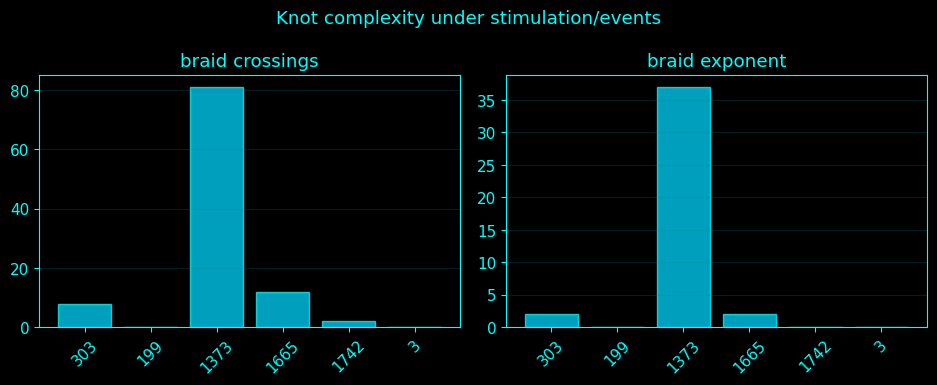

In [249]:
# Method 233: Knot complexity under stimulation

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_233():

    i = 233
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _braid2_word(y1,y2,z1=None,z2=None,maxn=None):
        if maxn is None:maxn={'full':1200,'balanced':800,'fast':500,'ultra':320}[FAST_OPTION]
        n=min(len(y1),len(y2));idx=np.linspace(0,n-1,min(n,maxn)).astype(int);a=np.asarray(y1)[idx];b=np.asarray(y2)[idx]
        if z1 is None:z1=np.gradient(a)
        else:z1=np.asarray(z1)[idx]
        if z2 is None:z2=np.gradient(b)
        else:z2=np.asarray(z2)[idx]
        d=a-b;word=[]
        for k in range(len(d)-1):
            if d[k]==0 or d[k]*d[k+1]<0:
                den=d[k]-d[k+1];lam=.5 if abs(den)<1e-12 else d[k]/den;zz1=z1[k]+lam*(z1[k+1]-z1[k]);zz2=z2[k]+lam*(z2[k+1]-z2[k]);left_is_1=a[k]<b[k];over_is_1=zz1>zz2;word.append(1 if left_is_1==over_is_1 else -1)
        return word

    # Method mathematics and output.
    ev = globals().get('TOPOLOGY_EVENT_SAMPLES', None)
    label = 'supplied events'
    if ev is None:
        env = np.abs(signal.hilbert(_topo_pc1))
        pk, _ = signal.find_peaks(env, distance=max(1, int(0.5 * _topo_fs)), prominence=np.std(env))
        ev = pk[np.argsort(env[pk])[-min(6, len(pk)):]] if len(pk) else []
        label = 'internal high-envelope events (demonstration)'
    rows = []
    half = max(100, int(0.5 * _topo_fs))
    for e in ev:
        a = max(0, int(e) - half)
        b = min(len(_topo_x), int(e) + half)
        y1, y2 = (_topo_x[a:b, 0], _topo_x[a:b, 1])
        w = _braid2_word(y1, y2)
        rows.append([int(e), len(w), sum(w)])
    print(label)
    out = pd.DataFrame(rows, columns=['event_sample', 'braid_crossings', 'braid_exponent'])
    display(out)
    if len(out):
        fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.9), facecolor=TOPO_BG)
        axs[0].bar(out['event_sample'].astype(str), out['braid_crossings'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        axs[0].set_title('braid crossings')
        axs[0].tick_params(axis='x', rotation=45)
        axs[1].bar(out['event_sample'].astype(str), out['braid_exponent'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        axs[1].set_title('braid exponent')
        axs[1].tick_params(axis='x', rotation=45)
        for ax in axs:
            ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        fig.suptitle('Knot complexity under stimulation/events')
        plt.tight_layout()
        plt.show()
    return


_topology_method_233()
del _topology_method_233


### 234. Fundamental group approximation

A 2-dimensional flag complex admits a standard fundamental-group presentation: collapse a maximal tree in the 1-skeleton, assign one generator to each remaining edge, and add one relator for the oriented boundary of every filled triangle. The resulting finite presentation approximates \(\pi_1\) of the sampled complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


π1 presentation approximation after maximal-tree collapse: generators= 3 relations= 3


,generator,edge
0,g0,"(4, 6)"
1,g1,"(5, 6)"
2,g2,"(6, 7)"


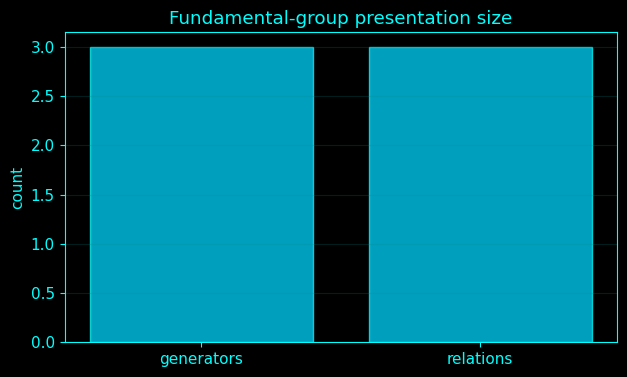

In [250]:
# Method 234: Fundamental group approximation

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_234():

    i = 234
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _fundamental_group_presentation(simp):
        n=len(simp[0]);G=nx.Graph();G.add_nodes_from(range(n));G.add_edges_from(simp.get(1,[]));T=nx.minimum_spanning_tree(G);tree={tuple(sorted(e)) for e in T.edges()};chords=[e for e in simp.get(1,[]) if tuple(sorted(e)) not in tree];gid={e:k for k,e in enumerate(chords)};rels=[]
        for tri in simp.get(2,[]):
            cyc=[(tri[0],tri[1]),(tri[1],tri[2]),(tri[2],tri[0])];word=[]
            for a,b in cyc:
                e=tuple(sorted((a,b)))
                if e in gid:word.append((gid[e],1 if (a,b)==e else -1))
            if word:rels.append(word)
        return chords,rels,T

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    gens, rels, T = _fundamental_group_presentation(simp)
    print('π1 presentation approximation after maximal-tree collapse: generators=', len(gens), 'relations=', len(rels))
    out = pd.DataFrame({'generator': [f'g{k}' for k in range(len(gens))], 'edge': gens})
    display(out)
    fig, ax = plt.subplots(figsize=(6.4, 3.9), facecolor=TOPO_BG)
    ax.bar(['generators', 'relations'], [len(gens), len(rels)], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Fundamental-group presentation size')
    ax.set_ylabel('count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_234()
del _topology_method_234


### 235. Discrete fundamental group

For a graph with no 2-cells, the fundamental group is free of rank \(|E|-|V|+\beta_0\). This discrete graph fundamental group is reported before triangle relations are imposed by the clique complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [251]:
# Method 235: Discrete fundamental group

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_235():

    i = 235
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    G = nx.Graph()
    G.add_nodes_from(range(len(simp[0])))
    G.add_edges_from(simp[1])
    rank = G.number_of_edges() - G.number_of_nodes() + nx.number_connected_components(G)
    print('discrete graph fundamental group is free of rank', rank, 'before triangle 2-cell relations')
    return


_topology_method_235()
del _topology_method_235


discrete graph fundamental group is free of rank 3 before triangle 2-cell relations


### 236. Loop generators and relations

Loop generators are the non-tree edges after maximal-tree collapse; triangle boundaries produce relations among those generators. The cell prints the resulting generator/relator words explicitly.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,relator_index,word
0,0,"[(0, 1)]"
1,1,"[(1, 1), (0, -1)]"
2,2,"[(1, 1), (2, 1)]"


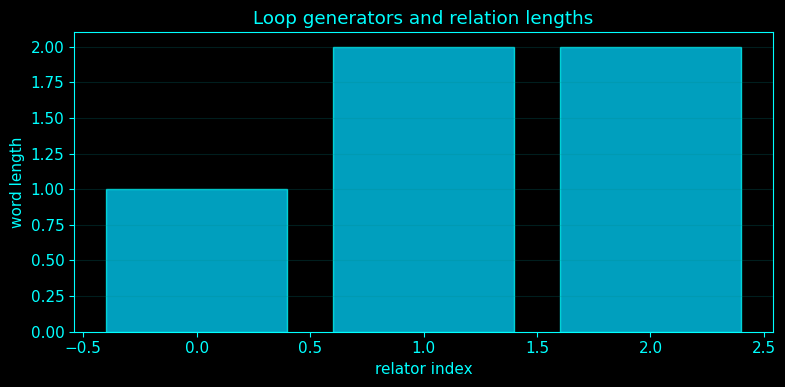

In [252]:
# Method 236: Loop generators and relations

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_236():

    i = 236
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _fundamental_group_presentation(simp):
        n=len(simp[0]);G=nx.Graph();G.add_nodes_from(range(n));G.add_edges_from(simp.get(1,[]));T=nx.minimum_spanning_tree(G);tree={tuple(sorted(e)) for e in T.edges()};chords=[e for e in simp.get(1,[]) if tuple(sorted(e)) not in tree];gid={e:k for k,e in enumerate(chords)};rels=[]
        for tri in simp.get(2,[]):
            cyc=[(tri[0],tri[1]),(tri[1],tri[2]),(tri[2],tri[0])];word=[]
            for a,b in cyc:
                e=tuple(sorted((a,b)))
                if e in gid:word.append((gid[e],1 if (a,b)==e else -1))
            if word:rels.append(word)
        return chords,rels,T

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    gens, rels, T = _fundamental_group_presentation(simp)
    out = pd.DataFrame({'relator_index': range(len(rels)), 'word': [str(r) for r in rels]})
    display(out)
    if len(rels):
        lengths = [len(r) for r in rels]
        fig, ax = plt.subplots(figsize=(8, 4.0), facecolor=TOPO_BG)
        ax.bar(np.arange(len(rels)), lengths, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title('Loop generators and relation lengths')
        ax.set_xlabel('relator index')
        ax.set_ylabel('word length')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return


_topology_method_236()
del _topology_method_236


### 237. Homotopy type approximation

Homotopy type is approximated through elementary simplicial collapses. Removing a free face together with its unique coface is a simple-homotopy equivalence, so the reduced cell counts describe a smaller complex of the same simple-homotopy type under the performed collapses.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


simple-homotopy reduced cell counts {0: 2, 1: 0, 2: 0} from {0: 8, 1: 9, 2: 3} collapse pairs 9


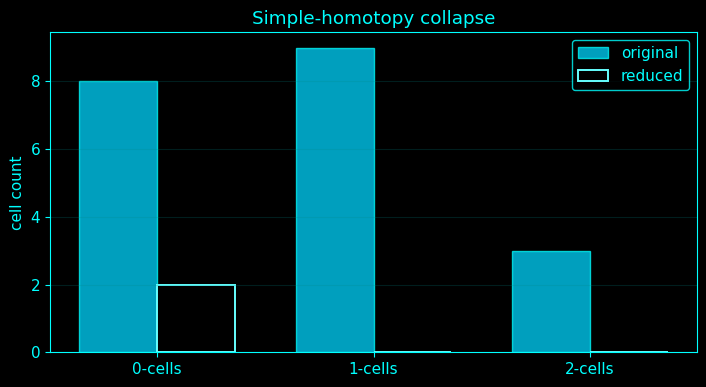

In [253]:
# Method 237: Homotopy type approximation

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_237():

    i = 237
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _collapse_complex(simp):
        S={d:set(map(tuple,simp.get(d,[]))) for d in range(4)};pairs=[];changed=True
        while changed:
            changed=False
            # collapse free edges in triangles first
            if S[2]:
                count={e:0 for e in S[1]}
                owner={}
                for t in S[2]:
                    for e in combinations(t,2):e=tuple(sorted(e));count[e]=count.get(e,0)+1;owner[e]=t
                free=next((e for e,c in count.items() if c==1),None)
                if free is not None:
                    t=owner[free];S[1].discard(free);S[2].discard(t);pairs.append((free,t));changed=True;continue
            # collapse leaf vertex-edge pairs
            deg={v[0]:0 for v in S[0]};own={}
            for e in S[1]:
                for v in e:deg[v]=deg.get(v,0)+1;own[v]=e
            leaf=next((v for v,d in deg.items() if d==1),None)
            if leaf is not None:
                e=own[leaf];S[0].discard((leaf,));S[1].discard(e);pairs.append(((leaf,),e));changed=True
        return S,pairs

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    red, pairs = _collapse_complex(simp)
    orig = {d: len(simp.get(d, [])) for d in range(3)}
    fin = {d: len(red[d]) for d in range(3)}
    print('simple-homotopy reduced cell counts', fin, 'from', orig, 'collapse pairs', len(pairs))
    x = np.arange(3)
    w = 0.36
    fig, ax = plt.subplots(figsize=(7.2, 4.0), facecolor=TOPO_BG)
    ax.bar(x - w / 2, [orig[d] for d in range(3)], width=w, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75, label='original')
    ax.bar(x + w / 2, [fin[d] for d in range(3)], width=w, color=TOPO_BG, edgecolor=TOPO_CYAN_SOFT, linewidth=1.4, label='reduced')
    ax.set_xticks(x)
    ax.set_xticklabels(['0-cells', '1-cells', '2-cells'])
    ax.set_title('Simple-homotopy collapse')
    ax.set_ylabel('cell count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return
    ratio = 1 - sum(fin.values()) / max(1, sum(orig.values()))
    print('Morse matching simplification ratio=', ratio, 'critical cells=', fin)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['critical 0', 'critical 1', 'critical 2'], [fin[0], fin[1], fin[2]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('critical cells')
    axs[1].bar(['simplified fraction'], [ratio], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_ylim(0, max(1, ratio * 1.15))
    axs[1].set_title('simplification ratio')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Morse matching simplification')
    plt.tight_layout()
    plt.show()
    return


_topology_method_237()
del _topology_method_237


### 238. Simple-homotopy collapses

A simple-homotopy collapse removes a pair \((\sigma,\tau)\) where \(\sigma\) is a free face contained in exactly one coface \(\tau\). The greedy routine performs triangle–edge and then edge–vertex collapses while preserving homotopy type.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


elementary free-face collapse pairs= 9 remaining {0: 2, 1: 0, 2: 0}


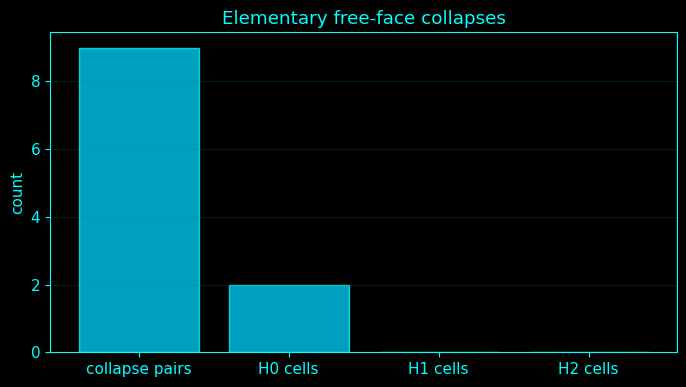

In [254]:
# Method 238: Simple-homotopy collapses

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_238():

    i = 238
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _collapse_complex(simp):
        S={d:set(map(tuple,simp.get(d,[]))) for d in range(4)};pairs=[];changed=True
        while changed:
            changed=False
            # collapse free edges in triangles first
            if S[2]:
                count={e:0 for e in S[1]}
                owner={}
                for t in S[2]:
                    for e in combinations(t,2):e=tuple(sorted(e));count[e]=count.get(e,0)+1;owner[e]=t
                free=next((e for e,c in count.items() if c==1),None)
                if free is not None:
                    t=owner[free];S[1].discard(free);S[2].discard(t);pairs.append((free,t));changed=True;continue
            # collapse leaf vertex-edge pairs
            deg={v[0]:0 for v in S[0]};own={}
            for e in S[1]:
                for v in e:deg[v]=deg.get(v,0)+1;own[v]=e
            leaf=next((v for v,d in deg.items() if d==1),None)
            if leaf is not None:
                e=own[leaf];S[0].discard((leaf,));S[1].discard(e);pairs.append(((leaf,),e));changed=True
        return S,pairs

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    red, pairs = _collapse_complex(simp)
    orig = {d: len(simp.get(d, [])) for d in range(3)}
    fin = {d: len(red[d]) for d in range(3)}
    print('elementary free-face collapse pairs=', len(pairs), 'remaining', fin)
    fig, ax = plt.subplots(figsize=(7.0, 4.0), facecolor=TOPO_BG)
    ax.bar(['collapse pairs', 'H0 cells', 'H1 cells', 'H2 cells'], [len(pairs), fin[0], fin[1], fin[2]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Elementary free-face collapses')
    ax.set_ylabel('count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return
    ratio = 1 - sum(fin.values()) / max(1, sum(orig.values()))
    print('Morse matching simplification ratio=', ratio, 'critical cells=', fin)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['critical 0', 'critical 1', 'critical 2'], [fin[0], fin[1], fin[2]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('critical cells')
    axs[1].bar(['simplified fraction'], [ratio], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_ylim(0, max(1, ratio * 1.15))
    axs[1].set_title('simplification ratio')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Morse matching simplification')
    plt.tight_layout()
    plt.show()
    return


_topology_method_238()
del _topology_method_238


### 239. Discrete Morse reduction

Each elementary collapse pair is an acyclic discrete-Morse matching. Unmatched cells are critical cells; their counts bound the Betti numbers and define a reduced Morse complex. The cell uses only matchings certified by free-face collapses, avoiding unverified cyclic matchings.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


acyclic collapse matching pairs= 9 critical cells by dimension= {0: 2, 1: 0, 2: 0}


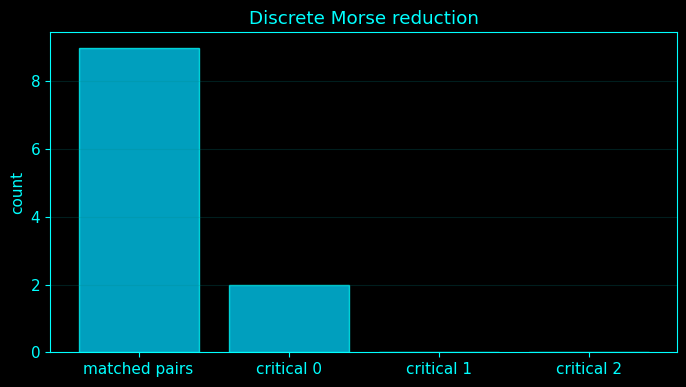

In [255]:
# Method 239: Discrete Morse reduction

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_239():

    i = 239
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _collapse_complex(simp):
        S={d:set(map(tuple,simp.get(d,[]))) for d in range(4)};pairs=[];changed=True
        while changed:
            changed=False
            # collapse free edges in triangles first
            if S[2]:
                count={e:0 for e in S[1]}
                owner={}
                for t in S[2]:
                    for e in combinations(t,2):e=tuple(sorted(e));count[e]=count.get(e,0)+1;owner[e]=t
                free=next((e for e,c in count.items() if c==1),None)
                if free is not None:
                    t=owner[free];S[1].discard(free);S[2].discard(t);pairs.append((free,t));changed=True;continue
            # collapse leaf vertex-edge pairs
            deg={v[0]:0 for v in S[0]};own={}
            for e in S[1]:
                for v in e:deg[v]=deg.get(v,0)+1;own[v]=e
            leaf=next((v for v,d in deg.items() if d==1),None)
            if leaf is not None:
                e=own[leaf];S[0].discard((leaf,));S[1].discard(e);pairs.append(((leaf,),e));changed=True
        return S,pairs

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    red, pairs = _collapse_complex(simp)
    orig = {d: len(simp.get(d, [])) for d in range(3)}
    fin = {d: len(red[d]) for d in range(3)}
    print('acyclic collapse matching pairs=', len(pairs), 'critical cells by dimension=', fin)
    fig, ax = plt.subplots(figsize=(7.0, 4.0), facecolor=TOPO_BG)
    ax.bar(['matched pairs', 'critical 0', 'critical 1', 'critical 2'], [len(pairs), fin[0], fin[1], fin[2]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Discrete Morse reduction')
    ax.set_ylabel('count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return
    ratio = 1 - sum(fin.values()) / max(1, sum(orig.values()))
    print('Morse matching simplification ratio=', ratio, 'critical cells=', fin)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['critical 0', 'critical 1', 'critical 2'], [fin[0], fin[1], fin[2]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('critical cells')
    axs[1].bar(['simplified fraction'], [ratio], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_ylim(0, max(1, ratio * 1.15))
    axs[1].set_title('simplification ratio')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Morse matching simplification')
    plt.tight_layout()
    plt.show()
    return


_topology_method_239()
del _topology_method_239


### 240. Morse matching simplification

Morse matching simplification reports the fraction of simplices removed by the collapse-derived acyclic matching and the remaining critical cells by dimension.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Morse matching simplification ratio= 0.9 critical cells= {0: 2, 1: 0, 2: 0}


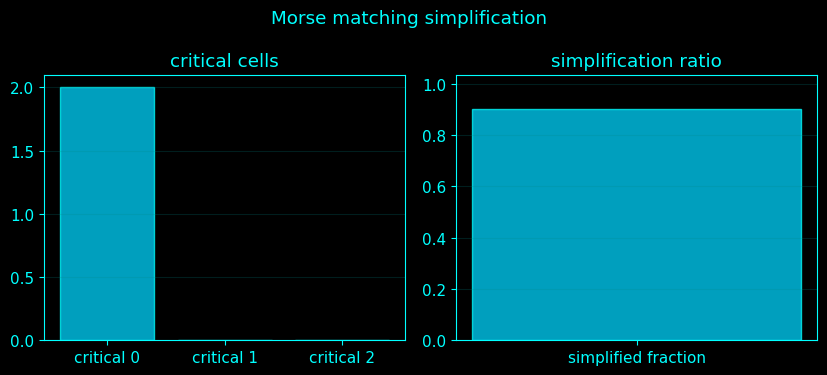

In [256]:
# Method 240: Morse matching simplification

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_240():

    i = 240
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _collapse_complex(simp):
        S={d:set(map(tuple,simp.get(d,[]))) for d in range(4)};pairs=[];changed=True
        while changed:
            changed=False
            # collapse free edges in triangles first
            if S[2]:
                count={e:0 for e in S[1]}
                owner={}
                for t in S[2]:
                    for e in combinations(t,2):e=tuple(sorted(e));count[e]=count.get(e,0)+1;owner[e]=t
                free=next((e for e,c in count.items() if c==1),None)
                if free is not None:
                    t=owner[free];S[1].discard(free);S[2].discard(t);pairs.append((free,t));changed=True;continue
            # collapse leaf vertex-edge pairs
            deg={v[0]:0 for v in S[0]};own={}
            for e in S[1]:
                for v in e:deg[v]=deg.get(v,0)+1;own[v]=e
            leaf=next((v for v,d in deg.items() if d==1),None)
            if leaf is not None:
                e=own[leaf];S[0].discard((leaf,));S[1].discard(e);pairs.append(((leaf,),e));changed=True
        return S,pairs

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    red, pairs = _collapse_complex(simp)
    orig = {d: len(simp.get(d, [])) for d in range(3)}
    fin = {d: len(red[d]) for d in range(3)}
    ratio = 1 - sum(fin.values()) / max(1, sum(orig.values()))
    print('Morse matching simplification ratio=', ratio, 'critical cells=', fin)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    axs[0].bar(['critical 0', 'critical 1', 'critical 2'], [fin[0], fin[1], fin[2]], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('critical cells')
    axs[1].bar(['simplified fraction'], [ratio], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_ylim(0, max(1, ratio * 1.15))
    axs[1].set_title('simplification ratio')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Morse matching simplification')
    plt.tight_layout()
    plt.show()
    return


_topology_method_240()
del _topology_method_240


### 241. Cellular approximation of EEG topology

A minimal homology-matched CW summary uses one cell for each surviving homology generator after the finite complex is analyzed. This is a **cellular homology approximation**—matching Betti numbers alone does not prove homotopy equivalence or determine attaching maps.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


homology-matched CW approximation: 0-cells= 2 1-cells= 0 2-cell H2 generators≈ 0


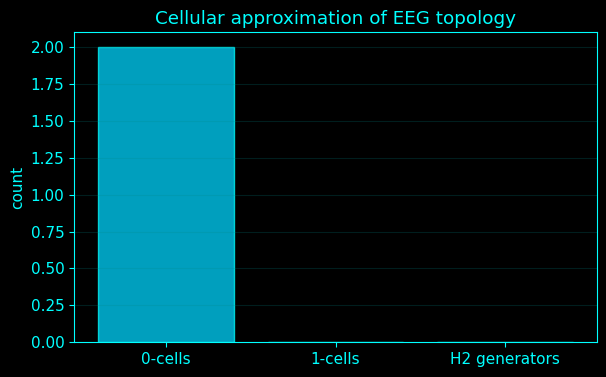

In [257]:
# Method 241: Cellular approximation of EEG topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_241():

    i = 241
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    b0, b1 = _simplicial_betti_01(simp)
    B1 = _boundary_matrix(simp[0], simp.get(1, []))
    B2 = _boundary_matrix(simp.get(1, []), simp.get(2, []))
    b2 = int(max(0, len(simp.get(2, [])) - np.linalg.matrix_rank(B2)))
    print('homology-matched CW approximation: 0-cells=', b0, '1-cells=', b1, '2-cell H2 generators≈', b2)
    fig, ax = plt.subplots(figsize=(6.2, 3.9), facecolor=TOPO_BG)
    ax.bar(['0-cells', '1-cells', 'H2 generators'], [b0, b1, b2], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Cellular approximation of EEG topology')
    ax.set_ylabel('count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_241()
del _topology_method_241


### 242. Persistent spectral sequences

For a filtered chain complex, the spectral sequence has first page \(E^1_{p,q}=H_{p+q}(K_p,K_{p-1})\) and converges (under the finite filtration here) to homology of the final complex. The notebook computes this relative-homology E1 page exactly; it does not fabricate higher differentials that were not reduced.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,filtration_level,homological_degree,dim_E1_relative_homology
0,0,0,3
1,0,1,0
2,0,2,0
3,1,0,0
4,1,1,1
5,1,2,0


E1 page shown; spectral sequence converges to homology of the final filtered complex.


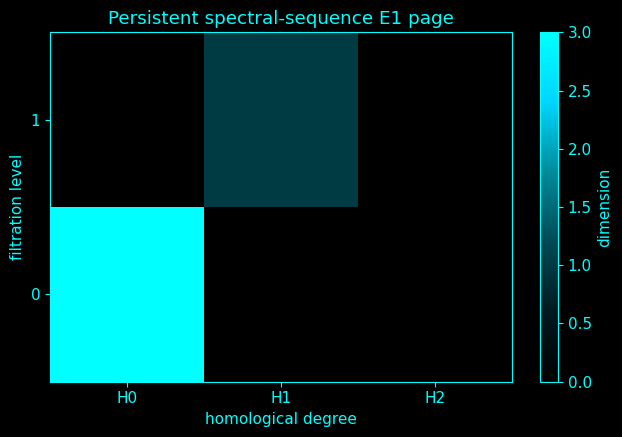

In [258]:
# Method 242: Persistent spectral sequences

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_242():

    i = 242
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _spectral_sequence_E1(simp,edge_grade_levels):
        # simplex filtration level: vertices 0, edges supplied, triangles max edge level
        egrade=edge_grade_levels;grades={0:{v:0 for v in simp[0]},1:egrade,2:{t:max(egrade[tuple(sorted(e))] for e in combinations(t,2)) for t in simp.get(2,[])}}
        levels=sorted(set([0]+list(egrade.values())));rows=[]
        for plev in levels:
            cells={d:[s for s,g in grades[d].items() if g==plev] for d in [0,1,2]}
            # relative boundary keeps only faces born at same level
            B1=_boundary_matrix(cells[0],cells[1]) if cells[0] and cells[1] else np.zeros((len(cells[0]),len(cells[1])))
            # custom B2 because some same-level triangle faces were born earlier and vanish in relative quotient
            i1={e:i for i,e in enumerate(cells[1])};B2=np.zeros((len(cells[1]),len(cells[2])))
            for j,t in enumerate(cells[2]):
                for q in range(3):
                    f=t[:q]+t[q+1:];f=tuple(sorted(f))
                    if f in i1:B2[i1[f],j]=(-1.)**q
            r1=(np.linalg.matrix_rank(B1) if B1.size else 0);r2=(np.linalg.matrix_rank(B2) if B2.size else 0);h0=len(cells[0])-r1;h1=(len(cells[1])-r1)-r2;h2=len(cells[2])-r2;rows.extend([[plev,k,int(max(0,h))] for k,h in enumerate([h0,h1,h2])])
        return pd.DataFrame(rows,columns=['filtration_level','homological_degree','dim_E1_relative_homology'])

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    vals = 1 - S[np.triu_indices(len(S), 1)]
    cuts = np.quantile(vals, [0.2, 0.4, 0.6, 0.8])
    edges = simp[1]
    eg = {e: int(np.searchsorted(cuts, 1 - S[e], side='right')) for e in edges}
    out = _spectral_sequence_E1(simp, eg)
    display(out)
    print('E1 page shown; spectral sequence converges to homology of the final filtered complex.')
    piv = out.pivot(index='filtration_level', columns='homological_degree', values='dim_E1_relative_homology').fillna(0)
    fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=TOPO_BG)
    im = ax.imshow(piv.to_numpy(float), cmap=TOPO_CMAP, aspect='auto', origin='lower')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'H{k}' for k in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_title('Persistent spectral-sequence E1 page')
    ax.set_xlabel('homological degree')
    ax.set_ylabel('filtration level')
    plt.colorbar(im, ax=ax, label='dimension')
    plt.tight_layout()
    plt.show()
    return


_topology_method_242()
del _topology_method_242


### 243. Obstruction-theoretic consistency

The covering map \(\mathbb R\to S^1\) gives a concrete obstruction problem: an edgewise circle-valued phase field lifts consistently to a real phase potential only when every cycle has zero integer winding. The notebook sums wrapped phase increments around a graph cycle basis; nonzero windings are the H1 obstruction to this chosen lift.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


S1→R lift obstruction winding numbers on graph cycle basis = [0, 1, 1] consistent lift= False


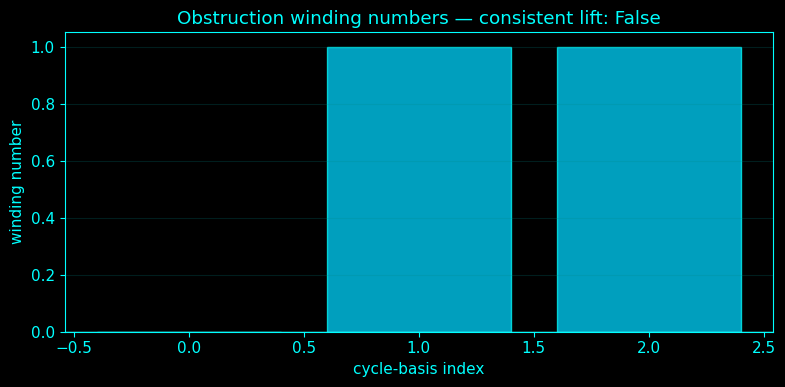

In [259]:
# Method 243: Obstruction-theoretic consistency

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_243():

    i = 243
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, _, th = _flag_simplices_similarity(S, 0.68, 2)
    n = len(S)
    hi = min(13, _topo_fs / 2 - 0.5)
    lo = min(8, max(0.5, hi - 2))
    Y = np.column_stack([_filter_band(_topo_x[:, j], lo, hi) for j in range(n)]) if hi > lo else _topo_x[:, :n]
    phi = np.angle(np.mean(np.exp(1j * np.angle(signal.hilbert(Y, axis=0))), axis=0))
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(simp[1])
    wind = []
    for cyc in nx.cycle_basis(G):
        seq = cyc + [cyc[0]]
        s = 0.0
        for a, b in zip(seq[:-1], seq[1:]):
            s += np.angle(np.exp(1j * (phi[b] - phi[a])))
        wind.append(int(np.rint(s / (2 * np.pi))))
    consistent = all((w == 0 for w in wind))
    print('S1→R lift obstruction winding numbers on graph cycle basis =', wind, 'consistent lift=', consistent)
    if len(wind):
        fig, ax = plt.subplots(figsize=(8, 4.0), facecolor=TOPO_BG)
        ax.bar(np.arange(len(wind)), wind, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.axhline(0, color=TOPO_CYAN_SOFT, linewidth=1.0)
        ax.set_title(f'Obstruction winding numbers — consistent lift: {consistent}')
        ax.set_xlabel('cycle-basis index')
        ax.set_ylabel('winding number')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return


_topology_method_243()
del _topology_method_243


### 244. Functoriality and stability of persistence modules

Persistence is functorial: inclusions induce linear maps on homology, whose rank cannot exceed either endpoint Betti number. Stability for tame scalar functions gives \(d_B(D(f),D(g))\le\|f-g\|_\infty\). The cell checks both properties, using an exact finite-diagram bottleneck matching and a shared cubical complex under a controlled scalar perturbation.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


bottleneck H1 distance= 0.009536606069941778 sup-norm perturbation= 0.009958775291175559 stability inequality dB<=||f-g||∞: True
inclusion-map rank= 0 <= min(beta1_p,beta1_q)= 0


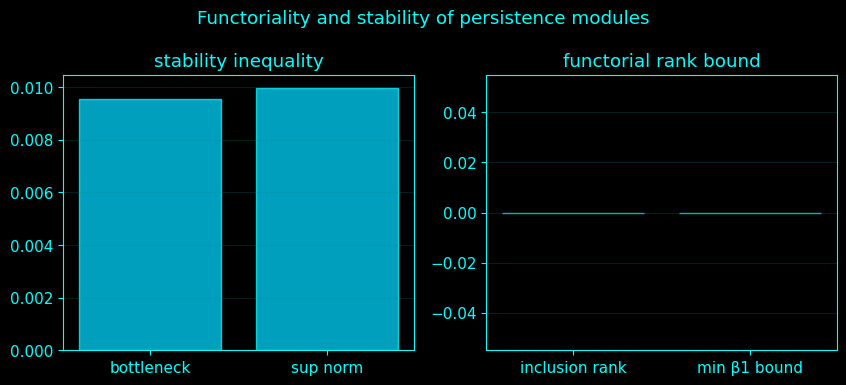

In [260]:
# Method 244: Functoriality and stability of persistence modules

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_244():

    i = 244
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _flag_complex_from_edge_subset(n,edges,maxdim=2):
        E=set(tuple(sorted(e)) for e in edges);simp={0:[(i,) for i in range(n)],1:sorted(E)}
        if maxdim>=2:simp[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if (i,j) in E and (i,k) in E and (j,k) in E]
        return simp

    def _bifilt_complex(a,b,n,edges,grades):
        ee=[e for e in edges if grades[e][0]<=a and grades[e][1]<=b];return _flag_complex_from_edge_subset(n,ee,2)

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _bottleneck_finite(A,B):
        # Exact finite-diagram bottleneck distance via thresholded perfect matching.
        # Zero-persistence points may be removed because they lie on the diagonal.
        from scipy.sparse import csr_matrix
        from scipy.sparse.csgraph import maximum_bipartite_matching
        A=_finite(A);B=_finite(B)
        if len(A):
            sa=max(1.0,float(np.max(np.abs(A))));A=A[(A[:,1]-A[:,0])>1e-12*sa]
        if len(B):
            sb=max(1.0,float(np.max(np.abs(B))));B=B[(B[:,1]-B[:,0])>1e-12*sb]
        m,n=len(A),len(B);N=m+n
        if N==0:return 0.0
        C=np.full((N,N),np.inf,float)
        if m and n:
            C[:m,:n]=np.max(np.abs(A[:,None,:]-B[None,:,:]),axis=2)
        for i in range(m): C[i,n+i]=(A[i,1]-A[i,0])/2
        for j in range(n): C[m+j,j]=(B[j,1]-B[j,0])/2
        C[m:,n:]=0.0
        vals=np.unique(C[np.isfinite(C)])
        if not len(vals):return 0.0
        def _perfect(eps):
            rows,cols=np.nonzero(C<=eps+1e-12)
            G=csr_matrix((np.ones(len(rows),dtype=np.int8),(rows,cols)),shape=(N,N))
            match=maximum_bipartite_matching(G,perm_type='column')
            return bool(np.all(match>=0))
        lo,hi=0,len(vals)-1
        while lo<hi:
            mid=(lo+hi)//2
            if _perfect(vals[mid]):hi=mid
            else:lo=mid+1
        return float(vals[lo])

    def _scalp_coords(n):
        pts=[]
        for nm in _topo_names[:n]:pts.append(_SCALP_POS.get(nm,(0.,0.)))
        return np.asarray(pts,float)

    def _channel_bigrades(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        coords=_scalp_coords(nch);D=squareform(pdist(coords));D=D/(np.max(D)+TOPO_EPS);R=np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)));Q=1-R;np.fill_diagonal(Q,0);edges=[(i,j) for i in range(nch) for j in range(i+1,nch)];grades={e:(float(D[e]),float(Q[e])) for e in edges};return nch,edges,grades

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _h1_inclusion_rank(small,large):
        B1s=_boundary_matrix(small[0],small.get(1,[]));B2s=_boundary_matrix(small.get(1,[]),small.get(2,[]));Z=_gf2_nullspace(np.rint(B1s).astype(np.uint8)%2)
        B2L=_boundary_matrix(large.get(1,[]),large.get(2,[]));Im=np.rint(B2L).astype(np.uint8)%2; el={e:i for i,e in enumerate(large.get(1,[]))};E=np.zeros((len(el),Z.shape[1]),dtype=np.uint8)
        es={e:i for i,e in enumerate(small.get(1,[]))}
        for e,si in es.items():
            if e in el:E[el[e],:]=Z[si,:]
        return _gf2_rank(np.column_stack([Im,E]))-_gf2_rank(Im) if E.shape[1] else 0

    def _simplicial_betti_01(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[]));B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[]));b0=len(simp[0])-_gf2_rank(np.rint(B1).astype(np.uint8)%2);b1=(len(simp.get(1,[]))-_gf2_rank(np.rint(B1).astype(np.uint8)%2))-_gf2_rank(np.rint(B2).astype(np.uint8)%2);return int(b0),int(max(0,b1))

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)

    # Method mathematics and output.
    A = _TOPO_SPEC.copy()
    A = (A - A.min()) / (A.max() - A.min() + TOPO_EPS)
    rng = np.random.default_rng(244)
    eps = 0.01
    B = A + rng.uniform(-eps, eps, A.shape)
    dA = _cubical_ph(A)[1]
    dB = _cubical_ph(B)[1]
    db = _bottleneck_finite(dA, dB)
    sup = float(np.max(np.abs(A - B)))
    print('bottleneck H1 distance=', db, 'sup-norm perturbation=', sup, 'stability inequality dB<=||f-g||∞:', db <= sup + 1e-09)
    n0, e0, g0 = _channel_bigrades()
    Kp = _bifilt_complex(0.45, 0.45, n0, e0, g0)
    Kq = _bifilt_complex(0.8, 0.8, n0, e0, g0)
    r = _h1_inclusion_rank(Kp, Kq)
    bp = _simplicial_betti_01(Kp)[1]
    bq = _simplicial_betti_01(Kq)[1]
    bound = min(bp, bq)
    print('inclusion-map rank=', r, '<= min(beta1_p,beta1_q)=', bound)
    fig, axs = plt.subplots(1, 2, figsize=(8.6, 3.9), facecolor=TOPO_BG)
    axs[0].bar(['bottleneck', 'sup norm'], [db, sup], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('stability inequality')
    axs[1].bar(['inclusion rank', 'min β1 bound'], [r, bound], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('functorial rank bound')
    for ax in axs:
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Functoriality and stability of persistence modules')
    plt.tight_layout()
    plt.show()
    return


_topology_method_244()
del _topology_method_244
